In [ ]:
# 크롤링 라이브러리 설치
! pip install undetected-chromedriver
! pip install webdriver_manager

# 일본어 번역을 위한 라이브러리 설치
! pip install googletrans==3.1.0a0

# 키워드 분석 라이브러리 설치
! pip install krwordrank

# JAVA 설치 필요
! pip install JPype1>=0.7.0

In [ ]:
# 패키지 통합 임포트

# 크롤링
from selenium import webdriver

from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.alert import Alert
from selenium.common.exceptions import TimeoutException
from selenium.common.exceptions import StaleElementReferenceException

from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

from bs4 import BeautifulSoup
import undetected_chromedriver as uc
from webdriver_manager.chrome import ChromeDriverManager
import json
import random

import requests

import pandas as pd
import time
from datetime import datetime

# ---------------------------------------------- #

# 키워드 분석
import os
import re
from ast import literal_eval
from konlpy.tag import Okt
from collections import Counter
from krwordrank.word import KRWordRank

# ---------------------------------------------- #

# 구글트렌드
from pytrends.request import TrendReq
import matplotlib.pyplot as plt

In [ ]:
# 데이터 전처리를 위한 크롤링 데이터셋 불러오기
df_combined = pd.read_csv('통합_무신사_데이터.csv')
final_df = pd.read_csv('통합_화해_데이터.csv')
olive_df = pd.read_csv('통합_올리브영_데이터.csv')
df_detail = pd.read_csv('통합_코스메_데이터.csv', encoding='EUC-KR')

In [ ]:
# 플랫폼 통합을 위한 전처리 데이터셋 불러오기기
musinsa_df = pd.read_csv('musinsa_preprocessing.csv')
hwahae_df = pd.read_csv('hwahae_preprocessing.csv')
oliveyoung_df = pd.read_csv('oliveyoung_preprocessing.csv')

In [ ]:
# 키워드 분석을 위한 리뷰 데이터 불러오기
df_scrap=pd.read_csv("review_scrapped_1.csv")     # 무신사 리뷰 데이터

korea_all = pd.read_csv("korea_new_rank.csv")
olive_top_df = pd.read_csv('올리브영_워드클라우드_리뷰.csv')
olive_top5 = pd.read_csv("올리브영_리뷰_분류.csv")   # 올리브영 리뷰 데이터

# 1. 한국 & 일본 플랫폼 크롤링

## 무신사 : df_combined

#### 삭제 컨펌 부분

In [ ]:
driver.get("https://www.musinsa.com/main/beauty/ranking?storeCode=beauty&sectionId=231&categoryCode=104004&contentsId=&period=WEEKLY")
time.sleep(3)

In [ ]:
/html/body/section/div[2]/button

In [ ]:
driver.find_element(By.XPATH, '/html/body/section/div[2]/button').click()

In [ ]:
# 페이지 끝까지 스크롤
prev_height = driver.execute_script("return document.body.scrollHeight")
prev_height

3624

In [ ]:
while True:
    # 스크롤 내리기
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(0.5)

    # 새로운 높이 가져오기  
    new_height = driver.execute_script("return document.body.scrollHeight")
    if new_height == prev_height:
        break
    prev_height = new_height

In [ ]:
driver.execute_script("window.scrollTo(1000, 2000);")

In [ ]:
scroll_amount = 1000  # 스크롤 할 양 (1000 픽셀씩)
prev_height = 0  # 초기 높이

while True:
    # 스크롤 내리기
    driver.execute_script(f"window.scrollBy(0, {scroll_amount});")
    time.sleep(2)

    # 새로운 높이 가져오기
    new_height = driver.execute_script("return window.scrollY + window.innerHeight")
    max_height = driver.execute_script("return document.body.scrollHeight")

    # 더 이상 스크롤할 곳이 없으면 종료
    if new_height >= max_height:
        break

In [ ]:
//*[@id="commonLayoutContents"]/article/div[2]/div[1]/div[2]/div[1]/a[1]/p
//*[@id="commonLayoutContents"]/article/div[7]/div[2]/div[2]/div[1]/a[1]/p
//*[@id="commonLayoutContents"]/article/div[16]/div[3]/div[2]/div[1]/a[1]/p

In [ ]:
driver.find_element(By.XPATH, '//*[@id="commonLayoutContents"]/article/div[2]/div[1]/div[2]/div[1]/a[1]/p').text

'오드타입'

In [ ]:
brand_list = driver.find_elements(By.XPATH, '//*[@id="commonLayoutContents"]/article/div/div/div[2]/div[1]/a[1]/p')
len(brand_list)

300

In [ ]:
brand_list = [i.text for i in brand_list]
brand_list

['오드타입',
 '헤라',
 '헤라',
 '네이밍',
 '오브제',
 '오프라 코스메틱',
 '헤라',
 '오프라 코스메틱',
 '오브제',
 '오브제',
 '하트퍼센트',
 '오프라 코스메틱',
 '글피오',
 '네이밍',
 '정샘물',
 '네이밍',
 '헤라',
 '네이밍',
 '어바웃톤',
 '노베브',
 '오브제',
 '릴리바이레드',
 '롬앤',
 '힐어스',
 '에뛰드',
 '릴리바이레드',
 '무지개맨션',
 '비레디',
 '설화수',
 '설화수',
 '라카',
 '자빈드서울',
 '삐아',
 '엔트로피 메이크업',
 '글피오',
 '클리오',
 '스틸라',
 '헤라',
 '롬앤',
 '헤라',
 '비레디',
 '힌스',
 '에뛰드',
 '에뛰드',
 '글로우',
 '롬앤',
 '글로우',
 '네이밍',
 '키스미',
 '네이밍',
 '체이싱래빗',
 '에스쁘아',
 '삐아',
 '더샘',
 '코스노리',
 '어바웃톤',
 '비레디',
 '삐아',
 '바닐라코',
 '루나',
 '이니스프리',
 '네이밍',
 '오브제',
 '정샘물',
 '라네즈',
 '설화수',
 '힌스',
 '네이밍',
 '데이지크',
 '얼터너티브스테레오',
 '롬앤',
 '네이밍',
 '헤라',
 '코스노리',
 '오프라 코스메틱',
 '오드타입',
 '헤라',
 '엔트로피 메이크업',
 '엔트로피 메이크업',
 '시에로 코스메틱',
 '오브제',
 '롬앤',
 '릴리바이레드',
 '힌스',
 '롬앤',
 '토코보',
 '헤라',
 '설화수',
 '투쿨포스쿨',
 '그라펜',
 '자빈드서울',
 '헤라',
 '롬앤',
 '정샘물',
 '이니스프리',
 '두잉왓',
 '릴리바이레드',
 '오드타입',
 '삐아',
 '롬앤',
 '오드타입',
 '코스노리',
 '토리든',
 '헤라',
 '페리페라',
 '삐아',
 '노베브',
 '힌스',
 '네이밍',
 '네이밍',
 '루나',
 '비레디',
 '롬앤',
 '무지개맨션',
 '롬앤',
 '브이디엘',
 '바닐라코',
 '정샘

In [ ]:
//*[@id="commonLayoutContents"]/article/div[2]/div[1]/div[2]/div[1]/div/span[2]
//*[@id="commonLayoutContents"]/article/div[10]/div[2]/div[2]/div[1]/div/span[2]
//*[@id="commonLayoutContents"]/article/div[14]/div[3]/div[2]/div[1]/div/span

In [ ]:
price_list = driver.find_elements(By.XPATH, '//*[@id="commonLayoutContents"]/article/div/div/div[2]/div[1]/div/span')
len(price_list)

552

In [ ]:
price_list = [i.text for i in price_list]
price_list

['20%',
 '17,500원',
 '5%',
 '70,300원',
 '5%',
 '38,000원',
 '20%',
 '22,400원',
 '26%',
 '27,900원',
 '33,000원',
 '5%',
 '66,500원',
 '33,000원',
 '33%',
 '19,900원',
 '31%',
 '31,900원',
 '14,000원',
 '33,000원',
 '5%',
 '21,850원',
 '15%',
 '20,400원',
 '15%',
 '38,250원',
 '15%',
 '14,450원',
 '5%',
 '36,100원',
 '25%',
 '25,500원',
 '10%',
 '12,600원',
 '19,000원',
 '27%',
 '10,900원',
 '31%',
 '17,900원',
 '24%',
 '9,900원',
 '10%',
 '26,100원',
 '20%',
 '16,000원',
 '30%',
 '9,100원',
 '20%',
 '28,800원',
 '21%',
 '25,900원',
 '10%',
 '80,100원',
 '10%',
 '53,100원',
 '15,000원',
 '28,000원',
 '25%',
 '10,500원',
 '18,000원',
 '5%',
 '20,900원',
 '27%',
 '24,800원',
 '20%',
 '32,000원',
 '5%',
 '47,500원',
 '24%',
 '9,900원',
 '5%',
 '38,000원',
 '30%',
 '9,000원',
 '10%',
 '15,300원',
 '30%',
 '16,100원',
 '20%',
 '11,200원',
 '5%',
 '27,550원',
 '24%',
 '22,900원',
 '5%',
 '28,500원',
 '50%',
 '16,000원',
 '45%',
 '19,800원',
 '15%',
 '12,750원',
 '10%',
 '23,400원',
 '15%',
 '35,700원',
 '14%',
 '15,500원',
 '15%',
 '12,700원'

In [ ]:
filtered_price_list = [item for item in price_list if "원" in item]
len(filtered_price_list)

300

In [ ]:
//*[@id="commonLayoutContents"]/article/div[15]/div[1]/div[2]/div[1]/a[2]/p
//*[@id="commonLayoutContents"]/article/div[34]/div[3]/div[2]/div[1]/a[2]/p
//*[@id="commonLayoutContents"]/article/div[54]/div[1]/div[2]/div/a[2]/p

In [ ]:
product_list = driver.find_elements(By.XPATH, '//*[@id="commonLayoutContents"]/article/div/div/div[2]/div/a[2]/p')
product_list = [i.text for i in product_list]
print(len(product_list))
print(product_list)

300
['[신규컬러 론칭] 언씬 벌룬 틴트 12종', '블랙 쿠션 파운데이션 듀오 SPF34/PA++ 15gx2 (본품15g+리필15g)', '센슈얼 누드 글로스 5g', '[쿠션 스파츌라 증정] 레이어드 핏 쿠션 12g', '내추럴 커버 로션', '미니 하이라이터 - 클라우드9', '실키 스테이 24H 롱웨어 파운데이션 SPF20/PA++ 30g (옵션)', '미니 하이라이터 - 페퍼민트', '[신규 컬러 추가] 무드 체인지 립밤 1+1 (2개)', '내추럴 커버 파운데이션', '도트 온 무드 립펜슬', '미니 하이라이터 - 필로우 토크', '포그밤 드렁큰 레드 3.2g + 레드파우치+샤쉐 3종', '플러피 볼륨 앤 쉐딩 듀오 9.8g (+전용브러쉬 증정)', '에센셜 스킨 누더 쿠션(리필포함)(쿠션퍼프2개-스프링에디션 + 톤업선베이스3ml + 물크림라이트마스크 증정)', '블러리 하트 립 틴트 (+미니틴트증정)', '블랙쿠션 리필 15g (옵션)', '블러리 하트 립 틴트 듀오(+미니틴트+키링+파우치증정)', '블러 파우더 팩트(6color)', '노베브 슬림 엣지 듀얼 아이라이너 7colors', '[신규 컬러 추가] 무드 체인지 립밤', '[2PACK] 러브빔 치크밤(+NEW 컬러 구매 시 빅 하트 퍼프 증정)', '더 쥬시 래스팅 틴트', '숨결 컨실러 팔레트 (21호/23호)', '님프 광채 볼류머', '러브빔 치크밤 (+NEW 컬러 구매 시 빅 하트 퍼프 증정)', '오브제 리퀴드 틴트 29종 택 2', 'NEW 블루 쿠션 4세대 15g(SPF 34 PA++)', '퍼펙팅쿠션 에어리 15g*2 (본품15g+리필15g)', '퍼펙팅쿠션 에어리 15g', '프루티 글램 틴트', '윙크 파운데이션 팩트 15g', '글로우 틴트(15colors)(+헤어핀 증정)', '참 틴트 / 글로우 (10 colors)', '핑크페퍼 립 플럼퍼 10ml +하트키링+샤쉐 3종 증정', '프로 아이 팔레트 에어 [증정] 전용브러쉬1P', '헤븐스 휴 하이라이터 (오퓰런

In [ ]:
data = pd.DataFrame({"브랜드명":title_list, "가격":filtered_price_list})
data.to_csv("musinsa_ranking.csv",index=False,encoding="utf-8-sig")

In [ ]:
data

,브랜드명,가격
0,아디다스,"149,000원"
1,아디다스,"149,000원"
2,쿠어,"522,000원"
3,더블유브이프로젝트,"78,900원"
4,스파오,"34,950원"
...,...,...
294,리메인세컨드,"29,800원"
295,휠라,"109,000원"
296,크레드먼스,"35,000원"
297,아디다스,"138,990원"


### 01. 크롤링

#### 카테고리별 랭킹 페이지 접속

In [ ]:
# 크롬 드라이버 설정
driver = webdriver.Chrome()

# 무신사 카테고리별 랭킹 페이지 접속
driver.get("https://www.musinsa.com/main/beauty/ranking?storeCode=beauty&sectionId=231&categoryCode=104003&period=WEEKLY&contentsId=")
time.sleep(3)
driver.find_element(By.XPATH, '/html/body/section/div[2]/button').click()

# 페이지 끝까지 스크롤하여 항목 300개 로드
while True:
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)
    new_height = driver.execute_script("return document.body.scrollHeight")
    if new_height == prev_height:
        break
    prev_height = new_height

# 브랜드, 가격, 제품명 수집 (최대 100개)
brand_list = driver.find_elements(By.XPATH, '//*[@id="commonLayoutContents"]/article/div/div/div[2]/div[1]/a[1]/p')
brand_list = [i.text for i in brand_list][:100]

price_list = driver.find_elements(By.XPATH, '//*[@id="commonLayoutContents"]/article/div/div/div[2]/div[1]/div/span')
price_list = [i.text for i in price_list]
filtered_price_list = [item for item in price_list if "원" in item][:100]

product_list = driver.find_elements(By.XPATH, '//*[@id="commonLayoutContents"]/article/div/div/div[2]/div/a[2]/p')
product_list = [i.text for i in product_list][:100]

# 결과 출력
print(len(brand_list), len(filtered_price_list), len(product_list))
print("브랜드 리스트:", brand_list)
print("가격 리스트:", filtered_price_list)
print("제품명 리스트:", product_list)

# 드라이버 종료
driver.quit()

100 100 100
브랜드 리스트: ['이니스프리', '비플레인', '에스네이처', '토리든', '바닐라코', '바닐라코', '라운드랩', '휩드', '에이트루', '마녀공장', '일소', '메이크프렘', '비플레인', '에스네이처', '듀이트리', '마몽드', '파파레서피', '에스네이처', '비플레인', '메이크프렘', '주미소', '메디필', '이니스프리', '마녀공장', '폰즈', '에스네이처', '블리스텍스', '라운드랩', '비플레인', '에스네이처', '블리스텍스', '라운드랩', '라운드랩', '한스킨', '주미소', '라운드랩', '마녀공장', '설화수', '라운드랩', '토리든', '듀이트리', '한율', '라운드랩', '닥터지', '바닐라코', '비플레인', '라운드랩', '한스킨', '바닐라코', '프리메라', '유아른', '블리스텍스', '폴라초이스', '럽센트', '럽센트', '이니스프리', '휩드', '마미케어', '이니스프리', '라운드랩', '라운드랩', '블리스텍스', '아리얼', '헤라', '이즈앤트리', '비플레인', '마미케어', '아렌시아', '에스트라', '닥터지', '에뛰드', '포맨트', '믹순', '프리메라', '비플레인', '이니스프리', '구달', '비플레인', '셀퓨전씨', '스킨1004', '우르오스', '바닐라코', '메이크프렘', '아리얼', '오브제', '클리오', '코스알엑스', '아비브', '에스트라', '코스알엑스', '파파레서피', '바닐라코', '주미소', '더샘', '에스트라', '디마프', '마미케어', '휘게', '아비브', '시코르 컬렉션']
가격 리스트: ['18,200원', '31,200원', '31,900원', '23,000원', '23,000원', '23,000원', '12,900원', '29,000원', '19,500원', '17,400원', '21,000원', '34,440원', '18,900원', '17,100원', '19,800원', '25,500원', '16,200원'

#### 주간 랭킹 페이지 접속

In [ ]:
# 크롬 드라이버 설정
driver = webdriver.Chrome()

# 무신사 주간 랭킹 페이지 접속
driver.get("https://www.musinsa.com/main/beauty/ranking?storeCode=beauty&sectionId=231&categoryCode=104003&period=WEEKLY&contentsId=")
time.sleep(3)
driver.find_element(By.XPATH, '/html/body/section/div[2]/button').click()

# 상품 URL 수집
product_links = driver.find_elements(By.XPATH, '//*[@id="commonLayoutContents"]/article/div/div/div[2]/div/a[2]')
product_urls = [link.get_attribute('href') for link in product_links][:100]  # 100개까지 수집
len(product_urls)

# 드라이버 종료
driver.quit()

In [ ]:
# 크롬 드라이버 설정
driver = webdriver.Chrome()

# 별점, 카테고리, 후기 수 리스트
ratings = []
category_list = []
review_count_list = []

for url in product_urls:
    driver.get(url)
    time.sleep(3)  # 페이지 로드 대기
    
    # 페이지 스크롤 다운 (별점 로딩 대비)
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)
    
    # 별점 추출
    try:
        rating_element = WebDriverWait(driver, 5).until(
            EC.presence_of_element_located((By.XPATH, '//*[@id="reviewPosition"]/div[2]/div[1]/div/div[1]/div/div/span'))
        )
        rating = rating_element.text
    except Exception as e:
        try:
            rating_element = WebDriverWait(driver, 5).until(
                EC.presence_of_element_located((By.XPATH, '//*[@id="reviewPosition"]/div/div[1]/div/div[1]/div/div/span'))
            )
            rating = rating_element.text
        except Exception as e:
            try:
                rating_element = WebDriverWait(driver, 5).until(
                    EC.presence_of_element_located((By.XPATH, '//*[@id="reviewPosition"]/div/div[1]/div/div[1]/div/span[2]'))
                )
                rating = rating_element.text
            except Exception as e:
                print(f"별점 오류 발생: {e}")
                rating = "별점 없음"
    ratings.append(rating)
    
    # 세부 카테고리 추출 (2depth만 추출)
    try:
        category = driver.find_element(By.XPATH, '//a[@data-category-id="3depth"]').get_attribute('data-category-name')
    except:
        category = "카테고리 없음"
    category_list.append(category)
    
    # 후기 수 추출
    try:
        reviews = driver.find_element(By.XPATH, '//span[contains(@class, "cursor-pointer") and contains(text(), "후기")]').text
    except:
        reviews = "0"
    review_count_list.append(reviews)
    
    time.sleep(1)

# 결과 출력
print(len(category_list), len(review_count_list), len(ratings))
print("카테고리 리스트:", category_list)
print("후기 수 리스트:", review_count_list)
print("별점 리스트:", ratings)

# 드라이버 종료
driver.quit()



별점 오류 발생: Message: 
Stacktrace:
	GetHandleVerifier [0x00007FF79FB402F5+28725]
	(No symbol) [0x00007FF79FAA2AE0]
	(No symbol) [0x00007FF79F93510A]
	(No symbol) [0x00007FF79F9893D2]
	(No symbol) [0x00007FF79F9895FC]
	(No symbol) [0x00007FF79F9D3407]
	(No symbol) [0x00007FF79F9AFFEF]
	(No symbol) [0x00007FF79F9D0181]
	(No symbol) [0x00007FF79F9AFD53]
	(No symbol) [0x00007FF79F97A0E3]
	(No symbol) [0x00007FF79F97B471]
	GetHandleVerifier [0x00007FF79FE6F30D+3366989]
	GetHandleVerifier [0x00007FF79FE812F0+3440688]
	GetHandleVerifier [0x00007FF79FE778FD+3401277]
	GetHandleVerifier [0x00007FF79FC0AAAB+858091]
	(No symbol) [0x00007FF79FAAE74F]
	(No symbol) [0x00007FF79FAAA304]
	(No symbol) [0x00007FF79FAAA49D]
	(No symbol) [0x00007FF79FA98B69]
	BaseThreadInitThunk [0x00007FFDBA4FE8D7+23]
	RtlUserThreadStart [0x00007FFDBBADBF2C+44]

별점 오류 발생: Message: 
Stacktrace:
	GetHandleVerifier [0x00007FF79FB402F5+28725]
	(No symbol) [0x00007FF79FAA2AE0]
	(No symbol) [0x00007FF79F93510A]
	(No symbol) [0x000

### 02. 빈 값 채우기

In [ ]:
no_rating_indices = [i for i, rating in enumerate(ratings) if rating == "별점 없음"]
print("별점 없음인 항목의 인덱스:", no_rating_indices)

no_review_indices = [i for i, review_count_list in enumerate(review_count_list) if review_count_list == 0]
print("별점 없음인 항목의 인덱스:", no_review_indices)

별점 없음인 항목의 인덱스: [8, 9, 10, 11, 12, 13, 14, 59, 67]
별점 없음인 항목의 인덱스: []


In [ ]:
# 별점 없음인 항목 수정
ratings[8] = "4.9"  
ratings[9] = "4.9"  
ratings[10] = "4.8"  
ratings[11] = "4.9"  
ratings[12] = "4.8"  
ratings[13] = "4.9"  
ratings[14] = "4.9"  


# 결과 확인
print("수정된 별점 리스트:", ratings)


수정된 별점 리스트: ['4.9', '4.9', '4.9', '4.9', '4.9', '4.9', '4.9', '4.8', '4.9', '4.9', '4.8', '4.9', '4.8', '4.9', '4.9', '4.8', '4.8', '4.9', '4.9', '4.8', '4.9', '4.9', '4.9', '4.9', '4.9', '4.8', '4.9', '4.9', '4.8', '5', '4.9', '4.8', '4.9', '5', '4.9', '4.9', '4.9', '4.9', '4.9', '4.9', '4.9', '4.9', '4.8', '4.9', '4.9', '4.9', '4.9', '5', '5', '5', '5', '4.9', '4.8', '4.9', '4.9', '5', '4.9', '4', '4.9', '별점 없음', '4.9', '4.8', '4.9', '4.8', '4.8', '4.9', '4.8', '별점 없음', '4.9', '4.9', '4.9', '4.9', '4.8', '4.9', '4.7', '4.9', '4.9', '4.9', '4.8', '4.9', '4.9', '4.9', '4.7', '4.9', '4.7', '4.9', '4.9', '4.9', '4.9', '4.8', '4.8', '4.9', '4.8', '4.9', '4.9', '4.8', '5', '4.8', '4.9', '4.8']


### 03. 데이터프레임 생성

In [ ]:
import pandas as pd

# 데이터프레임 생성
df_cleanser = pd.DataFrame({
    "순위": range(1, 101),  # 1~100 순위
    "카테고리": ["클렌징"] * 100,  
    "세부 카테고리": category_list,
    "브랜드": brand_list,
    "제품명": product_list,
    "평점": ratings,
    "후기 개수": review_count_list,
    "가격": filtered_price_list,
    "URL": product_urls
})

# 데이터프레임 확인
df_cleanser.head()


,순위,카테고리,세부 카테고리,브랜드,제품명,평점,후기 개수,가격,URL
0,1,클렌징,페이셜클렌징,이니스프리,화산송이 모공 바하 클렌징 폼 150g 2개,4.9,"후기 7,915개","18,200원",https://www.musinsa.com/products/3670796
1,2,클렌징,페이셜클렌징,비플레인,[대용량]녹두 약산성 클렌징 폼 160ml 2개 (+40ml 증정),4.9,"후기 2,870개","31,200원",https://www.musinsa.com/products/3138771
2,3,클렌징,페이셜클렌징,에스네이처,아쿠아 라이스 약산성 클렌징폼 160ml 2개입 [증정: 클렌징 오일 13ml + ...,4.9,후기 630개,"31,900원",https://www.musinsa.com/products/4566395
3,4,클렌징,페이셜클렌징,토리든,[2개묶음] 다이브인 저분자 히알루론산 클렌징 폼 150ml x 2개 [총 300ml],4.9,"후기 3,707개","23,000원",https://www.musinsa.com/products/3312180
4,5,클렌징,메이크업클렌징,바닐라코,클린잇제로 오리지널 클렌징밤 대용량 180ml,4.9,"후기 1,215개","23,000원",https://www.musinsa.com/products/3994035


In [ ]:
df_cleanser.to_csv("df_cleanser.csv", index=False, encoding="utf-8-sig")

### 02. 파일 통합

In [ ]:
import pandas as pd

# 파일 목록 지정
file_list = ["musinsa_cleanser.csv", "musinsa_skincare.csv", "musinsa_suncare.csv", "musinsa_makeup.csv"]

# CSV 파일을 읽고 하나의 데이터프레임으로 합치기
df_list = [pd.read_csv(file) for file in file_list]
df_combined = pd.concat(df_list, ignore_index=True)

# 합쳐진 데이터프레임 저장 (필요한 경우)
# df_combined.to_csv("musinsa_weekly_ranking_category.csv", index=False, encoding="utf-8-sig")

df_combined.head(10)

,순위,카테고리,세부 카테고리,브랜드,제품명,평점,후기 개수,가격,URL
0,1,클렌징,페이셜클렌징,이니스프리,화산송이 모공 바하 클렌징 폼 150g 2개,4.9,"후기 7,915개","18,200원",https://www.musinsa.com/products/3670796
1,2,클렌징,페이셜클렌징,비플레인,[대용량]녹두 약산성 클렌징 폼 160ml 2개 (+40ml 증정),4.9,"후기 2,870개","31,200원",https://www.musinsa.com/products/3138771
2,3,클렌징,페이셜클렌징,에스네이처,아쿠아 라이스 약산성 클렌징폼 160ml 2개입 [증정: 클렌징 오일 13ml + ...,4.9,후기 630개,"31,900원",https://www.musinsa.com/products/4566395
3,4,클렌징,페이셜클렌징,토리든,[2개묶음] 다이브인 저분자 히알루론산 클렌징 폼 150ml x 2개 [총 300ml],4.9,"후기 3,707개","23,000원",https://www.musinsa.com/products/3312180
4,5,클렌징,메이크업클렌징,바닐라코,클린잇제로 오리지널 클렌징밤 대용량 180ml,4.9,"후기 1,215개","23,000원",https://www.musinsa.com/products/3994035
5,6,클렌징,메이크업클렌징,바닐라코,클린잇제로 포어 클래리파잉 클렌징밤 대용량 180ml,4.9,후기 990개,"23,000원",https://www.musinsa.com/products/3994036
6,7,클렌징,페이셜클렌징,라운드랩,소나무 진정 시카 클렌저 150ml(+소나무 겔 마스크 1매 증정),4.9,"후기 1,004개","12,900원",https://www.musinsa.com/products/3647194
7,8,클렌징,페이셜클렌징,휩드,비건 팩클렌저 대용량 130g (5종 택1),4.8,후기 217개,"29,000원",https://www.musinsa.com/products/4362152
8,9,클렌징,메이크업클렌징,에이트루,오리진 퓨어 밸런싱 클렌징 오일 300ml,4.9,"후기 5,188개","19,500원",https://www.musinsa.com/products/1542479
9,10,클렌징,메이크업클렌징,마녀공장,퓨어 클렌징 오일 200ml (+오일25ml+폼20ml 증정),4.9,"후기 1,376개","17,400원",https://www.musinsa.com/products/1252945


## 화해 : final_df

### 01. Def

In [ ]:
def find_product_id(url):
    """URL에서 상품 ID를 추출하는 함수"""
    match = re.search(r'/(goods|products)/(\d+)', url)  # `goods` 또는 `products` 뒤의 숫자 찾기
    return match.group(2) if match else None

In [ ]:
now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
now_date = datetime.now().strftime('%Y%m%d')

print(now)
print(now_date)

2025-02-20 23:55:56
20250220


### 02. URL

In [ ]:
# # 스킨케어
# 스킨토너 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4156
# 로션/에멀젼 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4165
# 에센스/앰플/세럼 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4174
# 페이스오일 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4183
# 크림 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4184
# 아이케어 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4193
# 미스트 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4194
# 젤 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4199
# 스킨/토너 패드 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4498
# 밤/멀티밤 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4518

# # 클렌징
# 클렌징 폼 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4200
# 클렌징 워터 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4209
# 클렌징 젤 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4210
# 클렌징 오일 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4211
# 클렌징 로션/크림 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4212
# 클렌징 비누 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4213
# 클렌징 티슈/패드 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4214
# 립/아이 리무버 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4215
# 스크럽/필링 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4216
# 스크럽/필링 패드 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4507
# 클렌징 파우더 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4527
# 클렌징 밤 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4536

# # 마스크/팩
# 시트마스크 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4217
# 부분마스크/팩 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4226
# 워시오프 팩 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4235
# 필오프 팩 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4244
# 슬리핑팩 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4253
# 패치 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4262
# 코팩 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4263
# 부분마스크 패드 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4508

# # 선케어
# 선크림/로션 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4272
# 선스프레이 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4279
# 선케어 기타 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4286

# 선스틱 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4293
# 선쿠션/팩트 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4300

# # 베이스 메이크업
# 메이크업 베이스 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4307
# 프라이머 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4312
# BB/CC크림 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4317
# 파운데이션 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4322
# 쿠션 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4328
# 파우더/팩트 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4333
# 컨실러 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4338
# 블러셔 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4344
# 하이라이터 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4350
# 메이크업픽서 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4356
# 셰이딩 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4361
# 톤업크림 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4367

# # 아이메이크업
# 아이섀도 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4368
# 아이라이너 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4374
# 아이브로우 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4380
# 마스카라/픽서 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4386
# 속눈썹영양제 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4392

# # 립메이크업
# 립스틱 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4393
# 립틴트 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4398 
# 립글로스 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4403
# 립케어/립밤 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4408
# 컬러 립케어/립밤 https://www.hwahae.co.kr/rankings?english_name=category&theme_id=4497

### 03. Crawiling

#### 00.카테고리명

In [ ]:
categories = {
  "스킨케어": {
    "스킨토너": 4156,
    "로션/에멀젼": 4165,
    "에센스/앰플/세럼": 4174,
    "페이스오일": 4183,
    "크림": 4184,
    "아이케어": 4193,
    "미스트": 4194,
    "젤": 4199,
    "스킨/토너 패드": 4498,
    "밤/멀티밤": 4518
  },
  "클렌징": {
    "클렌징 폼": 4200,
    "클렌징 워터": 4209,
    "클렌징 젤": 4210,
    "클렌징 오일": 4211,
    "클렌징 로션/크림": 4212,
    "클렌징 비누": 4213,
    "클렌징 티슈/패드": 4214,
    "립/아이 리무버": 4215,
    "스크럽/필링": 4216,
    "스크럽/필링 패드": 4507,
    "클렌징 파우더": 4527,
    "클렌징 밤": 4536
  },
  "마스크/팩": {
    "시트마스크": 4217,
    "부분마스크/팩": 4226,
    "워시오프 팩": 4235,
    "필오프 팩": 4244,
    "슬리핑팩": 4253,
    "패치": 4262,
    "코팩": 4263,
    "부분마스크 패드": 4508
  },
  "선케어": {
    "선크림/로션": 4272,
    "선스프레이": 4279,
    "선케어 기타": 4286,
    "선스틱": 4293,
    "선쿠션/팩트": 4300
  },
  "베이스 메이크업": {
    "메이크업 베이스": 4307,
    "프라이머": 4312,
    "BB/CC크림": 4317,
    "파운데이션": 4322,
    "쿠션": 4328,
    "파우더/팩트": 4333,
    "컨실러": 4338,
    "블러셔": 4344,
    "하이라이터": 4350,
    "메이크업픽서": 4356,
    "셰이딩": 4361,
    "톤업크림": 4367
  },
  "아이메이크업": {
    "아이섀도": 4368,
    "아이라이너": 4374,
    "아이브로우": 4380,
    "마스카라/픽서": 4386,
    "속눈썹영양제": 4392
  },
  "립메이크업": {
    "립스틱": 4393,
    "립틴트": 4398,
    "립글로스": 4403,
    "립케어/립밤": 4408,
    "컬러 립케어/립밤": 4497
  }
}

#### 01.스킨케어

In [ ]:
for category, code in categories["스킨케어"].items():
    category = category.replace(' ', '').replace('/', '_')
    url = f"https://www.hwahae.co.kr/rankings?english_name=category&theme_id={code}"
    
    # WebDriver 설정
    service = Service(ChromeDriverManager().install())
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")  # 백그라운드 실행
    options.add_argument("--disable-gpu")
    options.add_argument("--no-sandbox")

    driver = webdriver.Chrome(service=service, options=options)
    driver.get(url)
    time.sleep(random.uniform(3, 5))  # 페이지 로딩 대기

    prev_height = driver.execute_script("return document.body.scrollHeight")
    while True:
        # 스크롤 내리기
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(1)

        # 새로운 높이 가져오기
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == prev_height:
            break
        prev_height = new_height

        time.sleep(1)

    wait = WebDriverWait(driver, 10)

    # 데이터 추출
    titles = [t.text for t in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[1]')))]
    names = [n.text for n in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[2]')))]
    ratings = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[1]')))]
    prices = [p.text for p in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[2]')))]
    reviews = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[2]')))]
    product_urls = [link_element.get_attribute('href') for link_element in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a')))]
    productIdlist = [find_product_id(pu) for pu in product_urls]
    price_list = [re.search(r'(\d{1,3}(?:,\d{3})*)\s?원', p) for p in prices]
    price_cleaned = [match.group(1).replace(",", "") if match else None for match in price_list]


    # 리스트 길이 검증
    lengths = {
            "브랜드명": len(titles),
            "상품명": len(names),
            "별점": len(ratings),
            "리뷰수": len(reviews),
            "가격": len(price_cleaned) #,
            # "상품ID": len(productIdlist),
            # "URL": len(product_urls),
    }

    min_length = min(lengths.values())
    max_length = max(lengths.values())

    if min_length != max_length:
        print("⚠️ 데이터 길이 불일치 발생!")
        for key, length in lengths.items():
            print(f"{key}: {length} 개")

    # DataFrame 생성
    index_list = list(range(1, len(titles) + 1))

    df = pd.DataFrame({
    "순위": index_list,
    "브랜드명": titles,
    "상품명": names,
    # "상품ID": productIdlist,
    '별점': ratings,
    '리뷰수': reviews,
    '가격': price_cleaned,
    # 'url': product_urls,
    '업로드일': now
    })

    df['리뷰수'] = df['리뷰수'].fillna('0').apply(
        lambda x: int(str(x).replace(",", "")) if str(x).replace(",", "").isdigit() else 0
    )

    df['대분류'] = '스킨케어'
    df['중분류'] = category

    # 파일 저장
    df.to_csv(f"hwahae_data/hwahae_{category}_ranking.csv", index=False, encoding="utf-8-sig")
    print(f"✅ 화해 {category} 데이터가 저장되었습니다.")

    driver.quit()

✅ 화해 스킨토너 데이터가 저장되었습니다.
✅ 화해 로션_에멀젼 데이터가 저장되었습니다.
✅ 화해 에센스_앰플_세럼 데이터가 저장되었습니다.
✅ 화해 페이스오일 데이터가 저장되었습니다.
✅ 화해 크림 데이터가 저장되었습니다.
✅ 화해 아이케어 데이터가 저장되었습니다.
✅ 화해 미스트 데이터가 저장되었습니다.
✅ 화해 젤 데이터가 저장되었습니다.
✅ 화해 스킨_토너패드 데이터가 저장되었습니다.
✅ 화해 밤_멀티밤 데이터가 저장되었습니다.


In [ ]:
time.sleep(60)

#### 02.클렌징

In [ ]:
for category, code in categories["클렌징"].items():
    category = category.replace(' ', '').replace('/', '_')
    url = f"https://www.hwahae.co.kr/rankings?english_name=category&theme_id={code}"
    
    # WebDriver 설정
    service = Service(ChromeDriverManager().install())
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")  # 백그라운드 실행
    options.add_argument("--disable-gpu")
    options.add_argument("--no-sandbox")

    driver = webdriver.Chrome(service=service, options=options)
    driver.get(url)
    time.sleep(random.uniform(3, 5))  # 페이지 로딩 대기

    prev_height = driver.execute_script("return document.body.scrollHeight")
    while True:
        # 스크롤 내리기
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(1)

        # 새로운 높이 가져오기
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == prev_height:
            break
        prev_height = new_height

        time.sleep(1)

    wait = WebDriverWait(driver, 10)

    # 데이터 추출
    titles = [t.text for t in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[1]')))]
    names = [n.text for n in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[2]')))]
    ratings = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[1]')))]
    prices = [p.text for p in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[2]')))]
    reviews = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[2]')))]
    product_urls = [link_element.get_attribute('href') for link_element in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a')))]
    productIdlist = [find_product_id(pu) for pu in product_urls]
    price_list = [re.search(r'(\d{1,3}(?:,\d{3})*)\s?원', p) for p in prices]
    price_cleaned = [match.group(1).replace(",", "") if match else None for match in price_list]


    # 리스트 길이 검증
    lengths = {
            "브랜드명": len(titles),
            "상품명": len(names),
            "별점": len(ratings),
            "리뷰수": len(reviews),
            "가격": len(price_cleaned) #,
            # "상품ID": len(productIdlist),
            # "URL": len(product_urls),
    }

    min_length = min(lengths.values())
    max_length = max(lengths.values())

    if min_length != max_length:
        print("⚠️ 데이터 길이 불일치 발생!")
        for key, length in lengths.items():
            print(f"{key}: {length} 개")

    # DataFrame 생성
    index_list = list(range(1, len(titles) + 1))

    df = pd.DataFrame({
    "순위": index_list,
    "브랜드명": titles,
    "상품명": names,
    # "상품ID": productIdlist,
    '별점': ratings,
    '리뷰수': reviews,
    '가격': price_cleaned,
    # 'url': product_urls,
    '업로드일': now
    })

    df['리뷰수'] = df['리뷰수'].fillna('0').apply(
        lambda x: int(str(x).replace(",", "")) if str(x).replace(",", "").isdigit() else 0
    )

    df['대분류'] = '클렌징'
    df['중분류'] = category

    # 파일 저장
    df.to_csv(f"hwahae_data/hwahae_{category}_ranking.csv", index=False, encoding="utf-8-sig")
    print(f"✅ 화해 {category} 데이터가 저장되었습니다.")

    driver.quit()

✅ 화해 클렌징폼 데이터가 저장되었습니다.
✅ 화해 클렌징워터 데이터가 저장되었습니다.
✅ 화해 클렌징젤 데이터가 저장되었습니다.
✅ 화해 클렌징오일 데이터가 저장되었습니다.
✅ 화해 클렌징로션_크림 데이터가 저장되었습니다.
✅ 화해 클렌징비누 데이터가 저장되었습니다.
✅ 화해 클렌징티슈_패드 데이터가 저장되었습니다.
✅ 화해 립_아이리무버 데이터가 저장되었습니다.
✅ 화해 스크럽_필링 데이터가 저장되었습니다.
✅ 화해 스크럽_필링패드 데이터가 저장되었습니다.
✅ 화해 클렌징파우더 데이터가 저장되었습니다.
✅ 화해 클렌징밤 데이터가 저장되었습니다.


In [ ]:
time.sleep(60)

#### 03.선케어

In [ ]:
for category, code in categories["선케어"].items():
    category = category.replace(' ', '').replace('/', '_')
    url = f"https://www.hwahae.co.kr/rankings?english_name=category&theme_id={code}"
    
    # WebDriver 설정
    service = Service(ChromeDriverManager().install())
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")  # 백그라운드 실행
    options.add_argument("--disable-gpu")
    options.add_argument("--no-sandbox")

    driver = webdriver.Chrome(service=service, options=options)
    driver.get(url)
    time.sleep(random.uniform(3, 5))  # 페이지 로딩 대기

    prev_height = driver.execute_script("return document.body.scrollHeight")
    while True:
        # 스크롤 내리기
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(1)

        # 새로운 높이 가져오기
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == prev_height:
            break
        prev_height = new_height

        time.sleep(1)

    wait = WebDriverWait(driver, 10)

    # 데이터 추출
    titles = [t.text for t in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[1]')))]
    names = [n.text for n in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[2]')))]
    ratings = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[1]')))]
    prices = [p.text for p in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[2]')))]
    reviews = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[2]')))]
    product_urls = [link_element.get_attribute('href') for link_element in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a')))]
    productIdlist = [find_product_id(pu) for pu in product_urls]
    price_list = [re.search(r'(\d{1,3}(?:,\d{3})*)\s?원', p) for p in prices]
    price_cleaned = [match.group(1).replace(",", "") if match else None for match in price_list]


    # 리스트 길이 검증
    lengths = {
            "브랜드명": len(titles),
            "상품명": len(names),
            "별점": len(ratings),
            "리뷰수": len(reviews),
            "가격": len(price_cleaned) #,
            # "상품ID": len(productIdlist),
            # "URL": len(product_urls),
    }

    min_length = min(lengths.values())
    max_length = max(lengths.values())

    if min_length != max_length:
        print("⚠️ 데이터 길이 불일치 발생!")
        for key, length in lengths.items():
            print(f"{key}: {length} 개")

    # DataFrame 생성
    index_list = list(range(1, len(titles) + 1))

    df = pd.DataFrame({
    "순위": index_list,
    "브랜드명": titles,
    "상품명": names,
    # "상품ID": productIdlist,
    '별점': ratings,
    '리뷰수': reviews,
    '가격': price_cleaned,
    # 'url': product_urls,
    '업로드일': now
    })

    df['리뷰수'] = df['리뷰수'].fillna('0').apply(
        lambda x: int(str(x).replace(",", "")) if str(x).replace(",", "").isdigit() else 0
    )

    df['대분류'] = '선케어'
    df['중분류'] = category

    # 파일 저장
    df.to_csv(f"hwahae_data/hwahae_{category}_ranking.csv", index=False, encoding="utf-8-sig")
    print(f"✅ 화해 {category} 데이터가 저장되었습니다.")

    driver.quit()

✅ 화해 선크림_로션 데이터가 저장되었습니다.
✅ 화해 선스프레이 데이터가 저장되었습니다.
✅ 화해 선케어기타 데이터가 저장되었습니다.
✅ 화해 선스틱 데이터가 저장되었습니다.
✅ 화해 선쿠션_팩트 데이터가 저장되었습니다.


In [ ]:
time.sleep(60)

#### 04.베이스 메이크업

In [ ]:
for category, code in categories["베이스 메이크업"].items():
    category = category.replace(' ', '').replace('/', '_')
    url = f"https://www.hwahae.co.kr/rankings?english_name=category&theme_id={code}"
    
    # WebDriver 설정
    service = Service(ChromeDriverManager().install())
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")  # 백그라운드 실행
    options.add_argument("--disable-gpu")
    options.add_argument("--no-sandbox")

    driver = webdriver.Chrome(service=service, options=options)
    driver.get(url)
    time.sleep(random.uniform(3, 5))  # 페이지 로딩 대기

    prev_height = driver.execute_script("return document.body.scrollHeight")
    while True:
        # 스크롤 내리기
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(1)

        # 새로운 높이 가져오기
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == prev_height:
            break
        prev_height = new_height

        time.sleep(1)

    wait = WebDriverWait(driver, 10)

    # 데이터 추출
    titles = [t.text for t in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[1]')))]
    names = [n.text for n in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[2]')))]
    ratings = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[1]')))]
    prices = [p.text for p in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[2]')))]
    reviews = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[2]')))]
    product_urls = [link_element.get_attribute('href') for link_element in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a')))]
    productIdlist = [find_product_id(pu) for pu in product_urls]
    price_list = [re.search(r'(\d{1,3}(?:,\d{3})*)\s?원', p) for p in prices]
    price_cleaned = [match.group(1).replace(",", "") if match else None for match in price_list]


    # 리스트 길이 검증
    lengths = {
            "브랜드명": len(titles),
            "상품명": len(names),
            "별점": len(ratings),
            "리뷰수": len(reviews),
            "가격": len(price_cleaned) #,
            # "상품ID": len(productIdlist),
            # "URL": len(product_urls),
    }

    min_length = min(lengths.values())
    max_length = max(lengths.values())

    if min_length != max_length:
        print("⚠️ 데이터 길이 불일치 발생!")
        for key, length in lengths.items():
            print(f"{key}: {length} 개")

    # DataFrame 생성
    index_list = list(range(1, len(titles) + 1))

    df = pd.DataFrame({
    "순위": index_list,
    "브랜드명": titles,
    "상품명": names,
    # "상품ID": productIdlist,
    '별점': ratings,
    '리뷰수': reviews,
    '가격': price_cleaned,
    # 'url': product_urls,
    '업로드일': now
    })

    df['리뷰수'] = df['리뷰수'].fillna('0').apply(
        lambda x: int(str(x).replace(",", "")) if str(x).replace(",", "").isdigit() else 0
    )

    df['대분류'] = '베이스메이크업'
    df['중분류'] = category

    # 파일 저장
    df.to_csv(f"hwahae_data/hwahae_{category}_ranking.csv", index=False, encoding="utf-8-sig")
    print(f"✅ 화해 {category} 데이터가 저장되었습니다.")

    driver.quit()

✅ 화해 메이크업베이스 데이터가 저장되었습니다.
✅ 화해 프라이머 데이터가 저장되었습니다.
✅ 화해 BB_CC크림 데이터가 저장되었습니다.
✅ 화해 파운데이션 데이터가 저장되었습니다.
✅ 화해 쿠션 데이터가 저장되었습니다.
✅ 화해 파우더_팩트 데이터가 저장되었습니다.
✅ 화해 컨실러 데이터가 저장되었습니다.
✅ 화해 블러셔 데이터가 저장되었습니다.
✅ 화해 하이라이터 데이터가 저장되었습니다.
✅ 화해 메이크업픽서 데이터가 저장되었습니다.
✅ 화해 셰이딩 데이터가 저장되었습니다.
✅ 화해 톤업크림 데이터가 저장되었습니다.


In [ ]:
time.sleep(60)

#### 05.아이메이크업

In [ ]:
for category, code in categories["아이메이크업"].items():
    category = category.replace(' ', '').replace('/', '_')
    url = f"https://www.hwahae.co.kr/rankings?english_name=category&theme_id={code}"
    
    # WebDriver 설정
    service = Service(ChromeDriverManager().install())
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")  # 백그라운드 실행
    options.add_argument("--disable-gpu")
    options.add_argument("--no-sandbox")

    driver = webdriver.Chrome(service=service, options=options)
    driver.get(url)
    time.sleep(random.uniform(3, 5))  # 페이지 로딩 대기

    prev_height = driver.execute_script("return document.body.scrollHeight")
    while True:
        # 스크롤 내리기
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(1)

        # 새로운 높이 가져오기
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == prev_height:
            break
        prev_height = new_height

        time.sleep(1)

    wait = WebDriverWait(driver, 10)

    # 데이터 추출
    titles = [t.text for t in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[1]')))]
    names = [n.text for n in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[2]')))]
    ratings = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[1]')))]
    prices = [p.text for p in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[2]')))]
    reviews = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[2]')))]
    product_urls = [link_element.get_attribute('href') for link_element in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a')))]
    productIdlist = [find_product_id(pu) for pu in product_urls]
    price_list = [re.search(r'(\d{1,3}(?:,\d{3})*)\s?원', p) for p in prices]
    price_cleaned = [match.group(1).replace(",", "") if match else None for match in price_list]


    # 리스트 길이 검증
    lengths = {
            "브랜드명": len(titles),
            "상품명": len(names),
            "별점": len(ratings),
            "리뷰수": len(reviews),
            "가격": len(price_cleaned) #,
            # "상품ID": len(productIdlist),
            # "URL": len(product_urls),
    }

    min_length = min(lengths.values())
    max_length = max(lengths.values())

    if min_length != max_length:
        print("⚠️ 데이터 길이 불일치 발생!")
        for key, length in lengths.items():
            print(f"{key}: {length} 개")

    # DataFrame 생성
    index_list = list(range(1, len(titles) + 1))

    df = pd.DataFrame({
    "순위": index_list,
    "브랜드명": titles,
    "상품명": names,
    # "상품ID": productIdlist,
    '별점': ratings,
    '리뷰수': reviews,
    '가격': price_cleaned,
    # 'url': product_urls,
    '업로드일': now
    })

    df['리뷰수'] = df['리뷰수'].fillna('0').apply(
        lambda x: int(str(x).replace(",", "")) if str(x).replace(",", "").isdigit() else 0
    )

    df['대분류'] = '아이메이크업'
    df['중분류'] = category

    # 파일 저장
    df.to_csv(f"hwahae_data/hwahae_{category}_ranking.csv", index=False, encoding="utf-8-sig")
    print(f"✅ 화해 {category} 데이터가 저장되었습니다.")

    driver.quit()

✅ 화해 아이섀도 데이터가 저장되었습니다.
✅ 화해 아이라이너 데이터가 저장되었습니다.
✅ 화해 아이브로우 데이터가 저장되었습니다.
✅ 화해 마스카라_픽서 데이터가 저장되었습니다.
✅ 화해 속눈썹영양제 데이터가 저장되었습니다.


In [ ]:
time.sleep(60)

#### 06.립케어

In [ ]:
for category, code in categories["립메이크업"].items():
    category = category.replace(' ', '').replace('/', '_')
    url = f"https://www.hwahae.co.kr/rankings?english_name=category&theme_id={code}"
    
    # WebDriver 설정
    service = Service(ChromeDriverManager().install())
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")  # 백그라운드 실행
    options.add_argument("--disable-gpu")
    options.add_argument("--no-sandbox")

    driver = webdriver.Chrome(service=service, options=options)
    driver.get(url)
    time.sleep(random.uniform(3, 5))  # 페이지 로딩 대기

    prev_height = driver.execute_script("return document.body.scrollHeight")
    while True:
        # 스크롤 내리기
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(1)

        # 새로운 높이 가져오기
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == prev_height:
            break
        prev_height = new_height

        time.sleep(1)

    wait = WebDriverWait(driver, 10)

    # 데이터 추출
    titles = [t.text for t in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[1]')))]
    names = [n.text for n in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[2]')))]
    ratings = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[1]')))]
    prices = [p.text for p in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[2]')))]
    reviews = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[2]')))]
    product_urls = [link_element.get_attribute('href') for link_element in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a')))]
    productIdlist = [find_product_id(pu) for pu in product_urls]
    price_list = [re.search(r'(\d{1,3}(?:,\d{3})*)\s?원', p) for p in prices]
    price_cleaned = [match.group(1).replace(",", "") if match else None for match in price_list]


    # 리스트 길이 검증
    lengths = {
            "브랜드명": len(titles),
            "상품명": len(names),
            "별점": len(ratings),
            "리뷰수": len(reviews),
            "가격": len(price_cleaned) #,
            # "상품ID": len(productIdlist),
            # "URL": len(product_urls),
    }

    min_length = min(lengths.values())
    max_length = max(lengths.values())

    if min_length != max_length:
        print("⚠️ 데이터 길이 불일치 발생!")
        for key, length in lengths.items():
            print(f"{key}: {length} 개")

    # DataFrame 생성
    index_list = list(range(1, len(titles) + 1))

    df = pd.DataFrame({
    "순위": index_list,
    "브랜드명": titles,
    "상품명": names,
    # "상품ID": productIdlist,
    '별점': ratings,
    '리뷰수': reviews,
    '가격': price_cleaned,
    # 'url': product_urls,
    '업로드일': now
    })

    df['리뷰수'] = df['리뷰수'].fillna('0').apply(
        lambda x: int(str(x).replace(",", "")) if str(x).replace(",", "").isdigit() else 0
    )

    df['대분류'] = '립메이크업'
    df['중분류'] = category

    # 파일 저장
    df.to_csv(f"hwahae_data/hwahae_{category}_ranking.csv", index=False, encoding="utf-8-sig")
    print(f"✅ 화해 {category} 데이터가 저장되었습니다.")

    driver.quit()

✅ 화해 립스틱 데이터가 저장되었습니다.
✅ 화해 립틴트 데이터가 저장되었습니다.
✅ 화해 립글로스 데이터가 저장되었습니다.
✅ 화해 립케어_립밤 데이터가 저장되었습니다.
✅ 화해 컬러립케어_립밤 데이터가 저장되었습니다.


In [ ]:
time.sleep(60)

#### 07.마스크팩

In [ ]:
for category, code in categories["마스크/팩"].items():
    category = category.replace(' ', '').replace('/', '_')
    url = f"https://www.hwahae.co.kr/rankings?english_name=category&theme_id={code}"
    
    # WebDriver 설정
    service = Service(ChromeDriverManager().install())
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")  # 백그라운드 실행
    options.add_argument("--disable-gpu")
    options.add_argument("--no-sandbox")

    driver = webdriver.Chrome(service=service, options=options)
    driver.get(url)
    time.sleep(random.uniform(3, 5))  # 페이지 로딩 대기

    prev_height = driver.execute_script("return document.body.scrollHeight")
    while True:
        # 스크롤 내리기
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(1)

        # 새로운 높이 가져오기
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == prev_height:
            break
        prev_height = new_height

        time.sleep(1)

    wait = WebDriverWait(driver, 10)

    # 데이터 추출
    titles = [t.text for t in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[1]')))]
    names = [n.text for n in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[1]/span[2]')))]
    ratings = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[1]')))]
    prices = [p.text for p in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[2]')))]
    reviews = [r.text for r in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a/div[3]/div[1]/div[2]/span[2]')))]
    product_urls = [link_element.get_attribute('href') for link_element in wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="__next"]/main/div[3]/div/ul/li/a')))]
    productIdlist = [find_product_id(pu) for pu in product_urls]
    price_list = [re.search(r'(\d{1,3}(?:,\d{3})*)\s?원', p) for p in prices]
    price_cleaned = [match.group(1).replace(",", "") if match else None for match in price_list]


    # 리스트 길이 검증
    lengths = {
            "브랜드명": len(titles),
            "상품명": len(names),
            "별점": len(ratings),
            "리뷰수": len(reviews),
            "가격": len(price_cleaned) #,
            # "상품ID": len(productIdlist),
            # "URL": len(product_urls),
    }

    min_length = min(lengths.values())
    max_length = max(lengths.values())

    if min_length != max_length:
        print("⚠️ 데이터 길이 불일치 발생!")
        for key, length in lengths.items():
            print(f"{key}: {length} 개")

    # DataFrame 생성
    index_list = list(range(1, len(titles) + 1))

    df = pd.DataFrame({
    "순위": index_list,
    "브랜드명": titles,
    "상품명": names,
    # "상품ID": productIdlist,
    '별점': ratings,
    '리뷰수': reviews,
    '가격': price_cleaned,
    # 'url': product_urls,
    '업로드일': now
    })

    df['리뷰수'] = df['리뷰수'].fillna('0').apply(
        lambda x: int(str(x).replace(",", "")) if str(x).replace(",", "").isdigit() else 0
    )

    df['대분류'] = '마스크_팩'
    df['중분류'] = category

    # 파일 저장
    df.to_csv(f"hwahae_data/hwahae_{category}_ranking.csv", index=False, encoding="utf-8-sig")
    print(f"✅ 화해 {category} 데이터가 저장되었습니다.")

    driver.quit()

✅ 화해 시트마스크 데이터가 저장되었습니다.
✅ 화해 부분마스크_팩 데이터가 저장되었습니다.
✅ 화해 워시오프팩 데이터가 저장되었습니다.
✅ 화해 필오프팩 데이터가 저장되었습니다.
✅ 화해 슬리핑팩 데이터가 저장되었습니다.
✅ 화해 패치 데이터가 저장되었습니다.
✅ 화해 코팩 데이터가 저장되었습니다.
✅ 화해 부분마스크패드 데이터가 저장되었습니다.


### 04.데이터 통합

In [ ]:
df_list = []

for big_category in list(categories.keys()):
    for name in categories[big_category].keys():
        rename = name.replace(' ', '').replace('/', '_')
        file_path = f"hwahae_data/hwahae_{rename}_ranking.csv"
        df = pd.read_csv(file_path)
        df['소분류'] = ''
        df['플랫폼'] = '화해'
        df['URL'] = ''
        df = df.rename(columns = {'순위' : '중분류_순위', '브랜드명' : '브랜드', '상품명' : '제품명', '별점' : '평점', '리뷰수' : '후기 수'})
        df = df[['플랫폼', '브랜드', '제품명', '중분류_순위', '대분류', '중분류', '소분류', '평점', '후기 수', '가격', 'URL']]
        df_list.append(df)

In [ ]:
final_df = pd.concat(df_list, ignore_index=True)

# save_path = "hwahae_data/통합_화해_데이터.csv"

# CSV 파일 저장
# final_df.to_csv(save_path, encoding='utf-8-sig', index=False)

## 올리브영 : olive_df

In [ ]:
# 브라우저 열기
driver = webdriver.Chrome()

### 1. 스킨케어 랭킹

In [ ]:
# 1. 스킨케어 랭킹 페이지 로드
driver.get("https://www.oliveyoung.co.kr/store/main/getBestList.do?dispCatNo=900000100100001&fltDispCatNo=10000010001&pageIdx=1&rowsPerPage=8&t_page=%EC%B9%B4%ED%85%8C%EA%B3%A0%EB%A6%AC%EA%B4%80&t_click=%EB%9E%AD%ED%82%B9BEST%EC%83%81%ED%92%88%EB%B8%8C%EB%9E%9C%EB%93%9C_%EC%9D%B8%EA%B8%B0%EC%83%81%ED%92%88%EB%8D%94%EB%B3%B4%EA%B8%B0")
time.sleep(3)  # 페이지 로드 대기

In [ ]:
# 2. 페이지 스크롤
prev_height = driver.execute_script("return document.body.scrollHeight")

# 1위 - 100위
while True:
    # 스크롤 내리기
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)

    # 새로운 높이 가져오기
    new_height = driver.execute_script("return document.body.scrollHeight")
    if new_height == prev_height:
        break
    prev_height = new_height

In [ ]:
# 3-1. 랭킹 페이지 데이터 추출
titles = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/div/a/span')
products = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/div/a/p')
or_prices = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/p[1]/span[1]/span')
dis_prices = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/p[1]/span[2]/span')

print(len(titles))
print(len(products))
print(len(or_prices))
print(len(dis_prices)) # 세일 안하는 상품들 맞는지 더블 체크 필요

In [ ]:
# 4-1. 데이터 텍스트 변환
title_list = [t.text for t in titles]
print(len(title_list))
print(title_list[:5])

product_list = [p.text for p in products]
print(len(product_list))
print(product_list[:5])

or_price_list = [op.text for op in or_prices]
print(len(or_price_list))
print(or_price_list[:5])

100
100
100
97
100
['에스트라', '에스트라', '에스트라', '바이오힐보', '구달']
100
['[2월올영픽/1등크림] 에스트라 아토베리어365 크림 80ML 더블기획 (+세라히알 앰플 7ML+에이시카 세럼 3ML)', '[50%용량증정]에스트라 아토베리어365 세라-히알 속수분 앰플 30ML+15ML 기획', '[2월올영픽]에스트라 아토베리어365 로션 150ml 리필 기획 (+150ML 리필 파우치 + 에이시카 세럼 3ML)', '[2월 올영픽/PDRN 키트증정] 바이오힐보 프로바이오덤 콜라겐 리모델링 세럼 30ml 리필 기획 (+프로그램14ml)', '[세럼1위/6년연속수상/총 120ml 대용량]구달 청귤 비타C 잡티케어 세럼 70ml 대용량 어워즈 한정기획']
100
['59,400', '33,000', '53,400', '49,500', '50,000']


In [ ]:
# 4-1. 할인가 밀림 현상 방지 및 데이터 텍스트 변환
dis_price_list = []

for w in range(1, 26):
  for l in range(1, 5):
    
    try:
      dis = driver.find_element(By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/p[1]/span[2]/span')
      if dis.text:
         dis_price_list.append(dis.text)
      else:
        dis_price_list.append('') 
             
    except:
      dis_price_list.append('')
      
print(len(dis_price_list))
print(dis_price_list[:5])

100
['24,000', '28,900', '42,000', '24,500', '27,360']


In [ ]:
# 3-2. 상품 상세 페이지 데이터 추출
wait = WebDriverWait(driver, 10)

main_classes = []
mid_classes = []
sub_classes = []
review_nums = []
review_scores = []

for w in range(1, 26):
  for l in range(1, 5):
    detail_page = driver.find_elements(By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/a')
    
    if detail_page:
        detail_page[0].click()
    else:
      continue

    main_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="midCatNm"]'))).text
    mid_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="smlCatNm"]'))).text
    sub_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="dtlCatNm"]'))).text 
    num = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="repReview"]/em'))).text
    score = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="repReview"]/b'))).text
  
    main_classes.append(main_class)
    mid_classes.append(mid_class)
    sub_classes.append(sub_class)
    review_nums.append(num)
    review_scores.append(score)

    driver.back()
    wait.until(EC.presence_of_element_located((By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/a')))


In [ ]:
# 4-2. 데이터 개수 확인
print(len(main_classes))
print(len(mid_classes))
print(len(sub_classes))
print(len(review_nums))
print(len(review_scores))

print(main_classes[0:5])
print(mid_classes[0:5])
print(sub_classes[0:5])
print(review_nums[0:5])
print(review_scores[0:5])

100
100
100
100
100
['스킨케어', '스킨케어', '스킨케어', '스킨케어', '스킨케어']
['크림', '에센스/세럼/앰플', '로션', '에센스/세럼/앰플', '에센스/세럼/앰플']
['크림', '에센스/세럼/앰플', '로션', '에센스/세럼/앰플', '에센스/세럼/앰플']
['(25,321건)', '(1,957건)', '(2,688건)', '(2,226건)', '(28,846건)']
['4.9', '4.8', '4.9', '4.7', '4.8']


In [ ]:
# 5. 데이터 저장
olive_skincare_dic = {"brand": title_list, "product": product_list, "or_price": or_price_list, "dis_price": dis_price_list, "main_class": main_classes, "mid_class": mid_classes, "sub_class": sub_classes, "review_num": review_nums, "review_score": review_scores}

NameError: name 'title_list' is not defined

In [ ]:
# DF 변환
olive_skincare_df = pd.DataFrame.from_dict(olive_skincare_dic, orient='index')
olive_skincare_df = olive_skincare_df.transpose()
olive_skincare_df.head()

,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,에스트라,[2월올영픽/1등크림] 에스트라 아토베리어365 크림 80ML 더블기획 (+세라히알...,"59,400","44,500",스킨케어,크림,크림,"(25,321건)",4.9
1,에스트라,[50%용량증정]에스트라 아토베리어365 세라-히알 속수분 앰플 30ML+15ML 기획,"33,000","24,700",스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(1,957건)",4.8
2,에스트라,[2월올영픽]에스트라 아토베리어365 로션 150ml 리필 기획 (+150ML 리필...,"53,400","39,900",스킨케어,로션,로션,"(2,688건)",4.9
3,바이오힐보,[2월 올영픽/PDRN 키트증정] 바이오힐보 프로바이오덤 콜라겐 리모델링 세럼 30...,"49,500","27,300",스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(2,226건)",4.7
4,구달,[세럼1위/6년연속수상/총 120ml 대용량]구달 청귤 비타C 잡티케어 세럼 70m...,"50,000","32,900",스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(28,846건)",4.8


In [ ]:
# 할인가 정상적으로 들어갔는지 확인
print(len(dis_prices))
print(olive_skincare_df.loc[olive_skincare_df['dis_price']=='']['product'].nunique())
olive_skincare_df.loc[olive_skincare_df['dis_price']=='']

,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
31,아벤느,[장벽/보습]아벤느 트릭세라 뉴트리-플루이드 로션 200ml 더블 기획 *윤광 *광...,"44,000",,스킨케어,로션,로션,"(2,042건)",4.7
68,에스티로더,에스티로더 갈색병 30ml 기획 (갈색병 21ml 추가 증정),"127,000",,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(2,882건)",4.8
82,디오디너리,디오디너리 나이아신아마이드 10% + 징크 1% 30ml,"8,700",,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(10,438건)",4.6


In [ ]:
# 인덱스 순으로 랭킹 컬럼 삽입 - 인덱스 컬럼 생성
olive_skincare_df.reset_index(inplace=True)
olive_skincare_df.head()

,index,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,0,에스트라,[2월올영픽/1등크림] 에스트라 아토베리어365 크림 80ML 더블기획 (+세라히알...,"59,400","44,500",스킨케어,크림,크림,"(25,321건)",4.9
1,1,에스트라,[50%용량증정]에스트라 아토베리어365 세라-히알 속수분 앰플 30ML+15ML 기획,"33,000","24,700",스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(1,957건)",4.8
2,2,에스트라,[2월올영픽]에스트라 아토베리어365 로션 150ml 리필 기획 (+150ML 리필...,"53,400","39,900",스킨케어,로션,로션,"(2,688건)",4.9
3,3,바이오힐보,[2월 올영픽/PDRN 키트증정] 바이오힐보 프로바이오덤 콜라겐 리모델링 세럼 30...,"49,500","27,300",스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(2,226건)",4.7
4,4,구달,[세럼1위/6년연속수상/총 120ml 대용량]구달 청귤 비타C 잡티케어 세럼 70m...,"50,000","32,900",스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(28,846건)",4.8


In [ ]:
# 인덱스 순으로 랭킹 컬럼 삽입 - 인덱스 컬럼 변경 및 값 변경
olive_skincare_df.rename(columns={'index':'ranking'}, inplace=True)
olive_skincare_df['ranking'] = olive_skincare_df['ranking'].apply(lambda x : x+1)
olive_skincare_df.head()

,ranking,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,1,에스트라,[2월올영픽/1등크림] 에스트라 아토베리어365 크림 80ML 더블기획 (+세라히알...,"59,400","44,500",스킨케어,크림,크림,"(25,321건)",4.9
1,2,에스트라,[50%용량증정]에스트라 아토베리어365 세라-히알 속수분 앰플 30ML+15ML 기획,"33,000","24,700",스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(1,957건)",4.8
2,3,에스트라,[2월올영픽]에스트라 아토베리어365 로션 150ml 리필 기획 (+150ML 리필...,"53,400","39,900",스킨케어,로션,로션,"(2,688건)",4.9
3,4,바이오힐보,[2월 올영픽/PDRN 키트증정] 바이오힐보 프로바이오덤 콜라겐 리모델링 세럼 30...,"49,500","27,300",스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(2,226건)",4.7
4,5,구달,[세럼1위/6년연속수상/총 120ml 대용량]구달 청귤 비타C 잡티케어 세럼 70m...,"50,000","32,900",스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(28,846건)",4.8


In [ ]:
# 원본 데이터 저장
# olive_skincare_df.to_csv("oliveyoung_skincare_ranking.csv", index=False, encoding="utf-8-sig")

### 2. 마스크팩 랭킹

In [ ]:
# 1. 마스크팩 랭킹 페이지 로드
driver.get("https://www.oliveyoung.co.kr/store/main/getBestList.do?dispCatNo=900000100100001&fltDispCatNo=10000010009&pageIdx=1&rowsPerPage=8&t_page=%EB%9E%AD%ED%82%B9&t_click=%ED%8C%90%EB%A7%A4%EB%9E%AD%ED%82%B9_%EB%A7%88%EC%8A%A4%ED%81%AC%ED%8C%A9")
time.sleep(3)  # 페이지 로드 대기

In [ ]:
# 2. 페이지 스크롤
prev_height = driver.execute_script("return document.body.scrollHeight")

In [ ]:
# 1위 - 100위
while True:
    # 스크롤 내리기
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)

    # 새로운 높이 가져오기
    new_height = driver.execute_script("return document.body.scrollHeight")
    if new_height == prev_height:
        break
    prev_height = new_height

In [ ]:
# 3-1. 랭킹 페이지 데이터 추출
titles = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/div/a/span')
products = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/div/a/p')
or_prices = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/p[1]/span[1]/span')
dis_prices = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/p[1]/span[2]/span')

print(len(titles))
print(len(products))
print(len(or_prices))
print(len(dis_prices)) # 세일 안하는 상품들 맞는지 더블 체크 필요

100
100
100
91


In [ ]:
# 4-1. 데이터 텍스트로 변환
title_list = [t.text for t in titles]
print(title_list[0:5])

product_list = [p.text for p in products]
print(product_list[0:5])

or_price_list = [op.text for op in or_prices]
print(or_price_list[0:5])

# dis_price_list = [dis.text for dis in dis_prices]
# print(dis_price_list[0:5])

['더마토리', '더마토리', '더마토리', '메디힐', '메디힐']
['[리뉴얼] 더마토리 히알루론 수분샘 엠보 패드 60매+10매 기획', '[리뉴얼] 더마토리 시카 엑소좀 흔적 진정 거즈 패드 70매+10매 기획', '[인씨 PICK/리뉴얼] 더마토리 살리시닉 포어 클리어 블랙 패드 70매+10매 기획 세트', '[51관왕/200매] 메디힐 네모패드 100+100매 더블기획 7종 골라담기', '[13년연속 1위] 메디힐 에센셜 마스크팩 1매 고기능 7종 택1']
['26,000', '26,000', '26,000', '39,900', '2,000']


In [ ]:
# 4-1. 할인가 밀림 현상 방지 및 데이터 텍스트 변환
dis_price_list = []

for w in range(1, 26):
  for l in range(1, 5):
    
    try:
      dis = driver.find_element(By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/p[1]/span[2]/span')
      if dis.text:
         dis_price_list.append(dis.text)
      else:
        dis_price_list.append('') 
             
    except:
      dis_price_list.append('')
      
print(len(dis_price_list))
print(dis_price_list[:5])

100
['17,600', '17,600', '17,600', '28,900', '1,000']


In [ ]:
# 3-2. 상품 상세 페이지 데이터 추출
wait = WebDriverWait(driver, 10)

main_classes = []
mid_classes = []
sub_classes = []
review_nums = []
review_scores = []

for w in range(1, 26):
  for l in range(1, 5):
    detail_page = driver.find_elements(By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/a')
    
    if detail_page:
        detail_page[0].click()
    else:
      continue

    main_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="midCatNm"]'))).text
    mid_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="smlCatNm"]'))).text
    sub_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="dtlCatNm"]'))).text 
    num = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="repReview"]/em'))).text
    score = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="repReview"]/b'))).text
  
    main_classes.append(main_class)
    mid_classes.append(mid_class)
    sub_classes.append(sub_class)
    review_nums.append(num)
    review_scores.append(score)

    driver.back()
    wait.until(EC.presence_of_element_located((By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/a')))


In [ ]:
# 4-2. 데이터 개수 확인
print(len(main_classes))
print(len(mid_classes))
print(len(sub_classes))
print(len(review_nums))
print(len(review_scores))

print(main_classes[0:5])
print(mid_classes[0:5])
print(sub_classes[0:5])
print(review_nums[0:5])
print(review_scores[0:5])

100
100
100
100
100
['마스크팩', '마스크팩', '마스크팩', '마스크팩', '마스크팩']
['패드', '패드', '패드', '패드', '시트팩']
['패드', '패드', '패드', '패드', '시트팩']
['(8건)', '(14건)', '(143건)', '(26,581건)', '(229,962건)']
['4.6', '4.9', '4.9', '4.7', '4.9']


In [ ]:
# 5. 데이터 저장
olive_mask_dic = {"brand": title_list, "product": product_list, "or_price": or_price_list, "dis_price": dis_price_list, "main_class": main_classes, "mid_class": mid_classes, "sub_class": sub_classes, "review_num": review_nums, "review_score": review_scores}

In [ ]:
# DF 변환
olive_mask_df = pd.DataFrame.from_dict(olive_mask_dic, orient='index')
olive_mask_df = olive_mask_df.transpose()
olive_mask_df.head()

,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,더마토리,[리뉴얼] 더마토리 히알루론 수분샘 엠보 패드 60매+10매 기획,"26,000","17,600",마스크팩,패드,패드,(8건),4.6
1,더마토리,[리뉴얼] 더마토리 시카 엑소좀 흔적 진정 거즈 패드 70매+10매 기획,"26,000","17,600",마스크팩,패드,패드,(14건),4.9
2,더마토리,[인씨 PICK/리뉴얼] 더마토리 살리시닉 포어 클리어 블랙 패드 70매+10매 기...,"26,000","17,600",마스크팩,패드,패드,(143건),4.9
3,메디힐,[51관왕/200매] 메디힐 네모패드 100+100매 더블기획 7종 골라담기,"39,900","28,900",마스크팩,패드,패드,"(26,581건)",4.7
4,메디힐,[13년연속 1위] 메디힐 에센셜 마스크팩 1매 고기능 7종 택1,"2,000","1,000",마스크팩,시트팩,시트팩,"(229,962건)",4.9


In [ ]:
# 할인가 정상적으로 들어갔는지 확인
print(len(dis_prices))
print(olive_mask_df.loc[olive_mask_df['dis_price']=='']['product'].nunique())
olive_mask_df.loc[olive_mask_df['dis_price']=='']

91
9


,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
33,스킨푸드,[700만개 판매/단독기획] 스킨푸드 캐롯 카로틴 카밍 워터 패드 기획 (60매+1...,"26,000",,마스크팩,패드,패드,"(61,247건)",4.8
41,비플레인,[3분/모공각질진정팩] 비플레인 녹두 모공 클레이 팩 120ml (+12ml*4ea...,"24,000",,마스크팩,페이셜팩,워시오프팩,"(11,248건)",4.7
60,브링그린,브링그린 프레시마스크 1매 5종,"1,800",,마스크팩,시트팩,시트팩,"(45,304건)",4.8
62,브링그린,[1+1] 브링그린 티트리시카포어코팩 5매입,"11,800",,마스크팩,코팩,코팩,"(10,227건)",4.8
68,메디필,메디필 랩핑 마스크팩 70mL 브러시 기획세트 2종 택1(레드락토 콜라겐/히알루론산...,"25,000",,마스크팩,페이셜팩,필오프팩,"(6,548건)",4.7
69,유세린,[데일리진정장벽] 유세린 울트라 센시티브 리페어 마스크팩 5매,"30,000",,마스크팩,시트팩,시트팩,"(1,802건)",4.8
74,메디힐,[26관왕/1위] 메디힐 더마 모델링 팩 풀패키지 5종 골라담기,"5,000",,마스크팩,페이셜팩,모델링팩,"(16,912건)",4.8
89,메디앤서,[모공쿨링/대용량]메디앤서 포어 콜라겐 나노샷 마스크 10매,"60,000",,마스크팩,시트팩,시트팩,(16건),4.4
90,에스트라,[NEW] 에스트라 에이시카365 쿨링팩패드 pH4.5 60매,"28,000",,마스크팩,패드,패드,(5건),5.0


In [ ]:
# 인덱스 순으로 랭킹 컬럼 삽입 - 인덱스 컬럼 생성
olive_mask_df.reset_index(inplace=True)
olive_mask_df.head()

,index,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,0,더마토리,[리뉴얼] 더마토리 히알루론 수분샘 엠보 패드 60매+10매 기획,"26,000","17,600",마스크팩,패드,패드,(8건),4.6
1,1,더마토리,[리뉴얼] 더마토리 시카 엑소좀 흔적 진정 거즈 패드 70매+10매 기획,"26,000","17,600",마스크팩,패드,패드,(14건),4.9
2,2,더마토리,[인씨 PICK/리뉴얼] 더마토리 살리시닉 포어 클리어 블랙 패드 70매+10매 기...,"26,000","17,600",마스크팩,패드,패드,(143건),4.9
3,3,메디힐,[51관왕/200매] 메디힐 네모패드 100+100매 더블기획 7종 골라담기,"39,900","28,900",마스크팩,패드,패드,"(26,581건)",4.7
4,4,메디힐,[13년연속 1위] 메디힐 에센셜 마스크팩 1매 고기능 7종 택1,"2,000","1,000",마스크팩,시트팩,시트팩,"(229,962건)",4.9


In [ ]:
# 인덱스 순으로 랭킹 컬럼 삽입 - 인덱스 컬럼 변경 및 값 변경
olive_mask_df.rename(columns={'index':'ranking'}, inplace=True)
olive_mask_df['ranking'] = olive_mask_df['ranking'].apply(lambda x : x+1)
olive_mask_df.head()

,ranking,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,1,더마토리,[리뉴얼] 더마토리 히알루론 수분샘 엠보 패드 60매+10매 기획,"26,000","17,600",마스크팩,패드,패드,(8건),4.6
1,2,더마토리,[리뉴얼] 더마토리 시카 엑소좀 흔적 진정 거즈 패드 70매+10매 기획,"26,000","17,600",마스크팩,패드,패드,(14건),4.9
2,3,더마토리,[인씨 PICK/리뉴얼] 더마토리 살리시닉 포어 클리어 블랙 패드 70매+10매 기...,"26,000","17,600",마스크팩,패드,패드,(143건),4.9
3,4,메디힐,[51관왕/200매] 메디힐 네모패드 100+100매 더블기획 7종 골라담기,"39,900","28,900",마스크팩,패드,패드,"(26,581건)",4.7
4,5,메디힐,[13년연속 1위] 메디힐 에센셜 마스크팩 1매 고기능 7종 택1,"2,000","1,000",마스크팩,시트팩,시트팩,"(229,962건)",4.9


In [ ]:
# 원본 데이터 저장
# olive_mask_df.to_csv("oliveyoung_mask_ranking.csv", index=False, encoding="utf-8-sig")

### 3. 클렌징 랭킹

In [ ]:
# 1. 클렌징 랭킹 페이지 로드
driver.get("https://www.oliveyoung.co.kr/store/main/getBestList.do?dispCatNo=900000100100001&fltDispCatNo=10000010010&pageIdx=1&rowsPerPage=8&t_page=%EB%9E%AD%ED%82%B9&t_click=%ED%8C%90%EB%A7%A4%EB%9E%AD%ED%82%B9_%ED%81%B4%EB%A0%8C%EC%A7%95")
time.sleep(3)  # 페이지 로드 대기

In [ ]:
# 2. 페이지 스크롤
prev_height = driver.execute_script("return document.body.scrollHeight")

# 1위 - 100위
while True:
    # 스크롤 내리기
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)

    # 새로운 높이 가져오기
    new_height = driver.execute_script("return document.body.scrollHeight")
    if new_height == prev_height:
        break
    prev_height = new_height

In [ ]:
# 3-1. 랭킹 페이지 데이터 추출
titles = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/div/a/span')
products = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/div/a/p')
or_prices = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/p[1]/span[1]/span')
dis_prices = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/p[1]/span[2]/span')

# 4-1. 데이터 개수 확인
print(len(titles))
print(len(products))
print(len(or_prices))
print(len(dis_prices)) # 세일 안하는 상품들 맞는지 더블 체크 필요

100
100
100
88


In [ ]:
# 4-1. 데이터 텍스트로 변환
title_list = [t.text for t in titles]
print(title_list[0:5])

product_list = [p.text for p in products]
print(product_list[0:5])

or_price_list = [op.text for op in or_prices]
print(or_price_list[0:5])

# dis_price_list = [dis.text for dis in dis_prices]
# print(dis_price_list[0:5])

['휩드', '마녀공장', '바이오더마', '비플레인', '바닐라코']
['[2월 올영픽] 휩드 비건 팩클렌저 130g 기획/단품 (무화버터/머그트리/유자몽)', '[4년연속1위]마녀공장 퓨어 클렌징 오일 200mlX2 더블기획', '[2월 올영픽]바이오더마 센시비오 H2O 850ml 기획 (+K2 콜라보 폴딩 에코백)', '[한정수량] 비플레인 녹두 약산성 클렌징폼 160ml + 40ml 기획', '[1등 클렌징밤] 바닐라코 클린잇제로 오리지널 클렌징밤 100ml 기획 (+미니어처키트 7ml*4개입)']
['29,000', '37,000', '37,500', '21,900', '20,000']


In [ ]:
# 4-1. 할인가 밀림 현상 방지 및 데이터 텍스트 변환
dis_price_list = []

for w in range(1, 26):
  for l in range(1, 5):
    
    try:
      dis = driver.find_element(By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/p[1]/span[2]/span')
      if dis.text:
         dis_price_list.append(dis.text)
      else:
        dis_price_list.append('') 
             
    except:
      dis_price_list.append('')
      
print(len(dis_price_list))
print(dis_price_list[:5])


100
['22,900', '25,900', '22,900', '18,600', '14,800']


In [ ]:
# 3-2. 상품 상세 페이지 데이터 추출
wait = WebDriverWait(driver, 10)

main_classes = []
mid_classes = []
sub_classes = []
review_nums = []
review_scores = []

for w in range(1, 26):
  for l in range(1, 5):
    detail_page = driver.find_elements(By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/a')
    
    if detail_page:
        detail_page[0].click()
    else:
      continue

    main_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="midCatNm"]'))).text
    mid_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="smlCatNm"]'))).text
    sub_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="dtlCatNm"]'))).text 
    num = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="repReview"]/em'))).text
    score = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="repReview"]/b'))).text
  
    main_classes.append(main_class)
    mid_classes.append(mid_class)
    sub_classes.append(sub_class)
    review_nums.append(num)
    review_scores.append(score)

    driver.back()
    wait.until(EC.presence_of_element_located((By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/a')))

In [ ]:
# 4-2. 데이터 개수 확인
print(len(main_classes))
print(len(mid_classes))
print(len(sub_classes))
print(len(review_nums))
print(len(review_scores))

print(main_classes[0:5])
print(mid_classes[0:5])
print(sub_classes[0:5])
print(review_nums[0:5])
print(review_scores[0:5])

100
100
100
100
100
['클렌징', '클렌징', '클렌징', '클렌징', '클렌징']
['클렌징폼/젤', '오일/밤', '워터/밀크', '클렌징폼/젤', '오일/밤']
['클렌징폼/젤', '클렌징오일', '클렌징워터', '클렌징폼/젤', '클렌징밤']
['(2,162건)', '(13,929건)', '(82,075건)', '(10,743건)', '(4,121건)']
['4.8', '4.9', '4.9', '4.8', '4.9']


In [ ]:
# 5. 데이터 저장
olive_clean_dic = {"brand": title_list, "product": product_list, "or_price": or_price_list, "dis_price": dis_price_list, "main_class": main_classes, "mid_class": mid_classes, "sub_class": sub_classes, "review_num": review_nums, "review_score": review_scores}

In [ ]:
# DF 변환
olive_clean_df = pd.DataFrame.from_dict(olive_clean_dic, orient='index')
olive_clean_df = olive_clean_df.transpose()
olive_clean_df.head()

,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,휩드,[2월 올영픽] 휩드 비건 팩클렌저 130g 기획/단품 (무화버터/머그트리/유자몽),"29,000","22,900",클렌징,클렌징폼/젤,클렌징폼/젤,"(2,162건)",4.8
1,마녀공장,[4년연속1위]마녀공장 퓨어 클렌징 오일 200mlX2 더블기획,"37,000","25,900",클렌징,오일/밤,클렌징오일,"(13,929건)",4.9
2,바이오더마,[2월 올영픽]바이오더마 센시비오 H2O 850ml 기획 (+K2 콜라보 폴딩 에코백),"37,500","22,900",클렌징,워터/밀크,클렌징워터,"(82,075건)",4.9
3,비플레인,[한정수량] 비플레인 녹두 약산성 클렌징폼 160ml + 40ml 기획,"21,900","18,600",클렌징,클렌징폼/젤,클렌징폼/젤,"(10,743건)",4.8
4,바닐라코,[1등 클렌징밤] 바닐라코 클린잇제로 오리지널 클렌징밤 100ml 기획 (+미니어처...,"20,000","14,800",클렌징,오일/밤,클렌징밤,"(4,121건)",4.9


In [ ]:
# 할인가 정상적으로 들어갔는지 확인
print(len(dis_prices))
print(olive_clean_df.loc[olive_clean_df['dis_price']=='']['product'].nunique())
olive_clean_df.loc[olive_clean_df['dis_price']=='']

88
12


,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
45,폰즈,[나띠 PICK] 폰즈 클리어 스파 립앤아이 리무버 300ml,"24,500",,클렌징,립&아이리무버,립&아이리무버,"(81,629건)",4.9
50,메디필,[모공/약알칼리성] 메디필 레드 락토 콜라겐 클리어 폼 2.0 기획 (300ml+딥...,"24,000",,클렌징,클렌징폼/젤,클렌징폼/젤,"(16,578건)",4.7
51,메이크프렘,메이크프렘 세이프 미 릴리프 모이스처 클렌징밀크 200ml 기획(+100ml 리필),"28,000",,클렌징,워터/밀크,클렌징밀크/크림,"(7,137건)",4.8
52,비오텀,비오텀 클렌징 밀크 200ml,"27,800",,클렌징,워터/밀크,클렌징밀크/크림,"(3,207건)",4.8
53,아크네스,[촉촉클렌저/거품] 아크네스 포밍워시 200㎖,"16,500",,클렌징,클렌징폼/젤,클렌징폼/젤,"(3,510건)",4.7
69,메디필,[트러블/약산성] 메디필 그린 시카 콜라겐 클리어 폼 2.0 기획,"24,000",,클렌징,클렌징폼/젤,클렌징폼/젤,"(4,832건)",4.8
75,런드리유,[모공브러쉬 증정/단독기획] 런드리유 클린 페이스 가글 스트롱 젤 투 폼 클렌저 기...,"22,000",,클렌징,클렌징폼/젤,클렌징폼/젤,"(11,351건)",4.9
78,일소,[2024 어워즈] 일소 슈퍼 멜팅 세범 소프트너 150ml 한정기획 (+솜40매+...,"28,900",,클렌징,필링&스크럽,피지클리너,"(13,429건)",4.7
79,브링그린,[NEW] 브링그린 티트리시카딥클렌징폼 120mL,"10,900",,클렌징,클렌징폼/젤,클렌징폼/젤,(149건),4.8
87,이즈앤트리,[단독기획] 이즈앤트리 참마 비건 밀크 클렌저 220ml 리필 기획 (+리필100ml),"25,000",,클렌징,워터/밀크,클렌징밀크/크림,"(4,262건)",4.8


In [ ]:
# 인덱스 순으로 랭킹 컬럼 삽입 - 인덱스 컬럼 생성
olive_clean_df.reset_index(inplace=True)
olive_clean_df.head()

,index,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,0,휩드,[2월 올영픽] 휩드 비건 팩클렌저 130g 기획/단품 (무화버터/머그트리/유자몽),"29,000","22,900",클렌징,클렌징폼/젤,클렌징폼/젤,"(2,162건)",4.8
1,1,마녀공장,[4년연속1위]마녀공장 퓨어 클렌징 오일 200mlX2 더블기획,"37,000","25,900",클렌징,오일/밤,클렌징오일,"(13,929건)",4.9
2,2,바이오더마,[2월 올영픽]바이오더마 센시비오 H2O 850ml 기획 (+K2 콜라보 폴딩 에코백),"37,500","22,900",클렌징,워터/밀크,클렌징워터,"(82,075건)",4.9
3,3,비플레인,[한정수량] 비플레인 녹두 약산성 클렌징폼 160ml + 40ml 기획,"21,900","18,600",클렌징,클렌징폼/젤,클렌징폼/젤,"(10,743건)",4.8
4,4,바닐라코,[1등 클렌징밤] 바닐라코 클린잇제로 오리지널 클렌징밤 100ml 기획 (+미니어처...,"20,000","14,800",클렌징,오일/밤,클렌징밤,"(4,121건)",4.9


In [ ]:
# 인덱스 순으로 랭킹 컬럼 삽입 - 인덱스 컬럼 변경 및 값 변경
olive_clean_df.rename(columns={'index':'ranking'}, inplace=True)
olive_clean_df['ranking'] = olive_clean_df['ranking'].apply(lambda x : x+1)
olive_clean_df.head()

,ranking,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,1,휩드,[2월 올영픽] 휩드 비건 팩클렌저 130g 기획/단품 (무화버터/머그트리/유자몽),"29,000","22,900",클렌징,클렌징폼/젤,클렌징폼/젤,"(2,162건)",4.8
1,2,마녀공장,[4년연속1위]마녀공장 퓨어 클렌징 오일 200mlX2 더블기획,"37,000","25,900",클렌징,오일/밤,클렌징오일,"(13,929건)",4.9
2,3,바이오더마,[2월 올영픽]바이오더마 센시비오 H2O 850ml 기획 (+K2 콜라보 폴딩 에코백),"37,500","22,900",클렌징,워터/밀크,클렌징워터,"(82,075건)",4.9
3,4,비플레인,[한정수량] 비플레인 녹두 약산성 클렌징폼 160ml + 40ml 기획,"21,900","18,600",클렌징,클렌징폼/젤,클렌징폼/젤,"(10,743건)",4.8
4,5,바닐라코,[1등 클렌징밤] 바닐라코 클린잇제로 오리지널 클렌징밤 100ml 기획 (+미니어처...,"20,000","14,800",클렌징,오일/밤,클렌징밤,"(4,121건)",4.9


In [ ]:
# 원본 데이터 저장
# olive_clean_df.to_csv("oliveyoung_cleansing_ranking.csv", index=False, encoding="utf-8-sig")

### 4. 선케어 랭킹

In [ ]:
# 선케어 랭킹 페이지 로드
driver.get("https://www.oliveyoung.co.kr/store/main/getBestList.do?dispCatNo=900000100100001&fltDispCatNo=10000010011&pageIdx=1&rowsPerPage=8&t_page=%EB%9E%AD%ED%82%B9&t_click=%ED%8C%90%EB%A7%A4%EB%9E%AD%ED%82%B9_%EC%84%A0%EC%BC%80%EC%96%B4")
time.sleep(3)  # 페이지 로드 대기

In [ ]:
# 2. 페이지 스크롤
prev_height = driver.execute_script("return document.body.scrollHeight")

# 1위 - 100위
while True:
    # 스크롤 내리기
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)

    # 새로운 높이 가져오기
    new_height = driver.execute_script("return document.body.scrollHeight")
    if new_height == prev_height:
        break
    prev_height = new_height

In [ ]:
# 3-1. 랭킹 페이지 데이터 추출출
titles = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/div/a/span')
products = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/div/a/p')
or_prices = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/p[1]/span[1]/span')
dis_prices = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/p[1]/span[2]/span')

print(len(titles))
print(len(products))
print(len(or_prices))
print(len(dis_prices)) # 세일 안하는 상품들 맞는지 더블 체크 필요

100
100
100
76


In [ ]:
# 4-2. 데이터 텍스트로 변환
title_list = [t.text for t in titles]
print(title_list[0:5])

product_list = [p.text for p in products]
print(product_list[0:5])

or_price_list = [op.text for op in or_prices]
print(or_price_list[0:5])

# dis_price_list = [dis.text for dis in dis_prices]
# print(dis_price_list[0:5])

['달바', '이지듀', '구달', '라운드랩', '라로슈포제']
['[물광자차/핑크광채썬] 달바 핑크 톤업 선크림 듀오 기획 (50ml+50ml)', '[한가인PICK/기미커버개선] 이지듀 기미 앰플 쿠션 15g', '[1+1기획] 구달 맑은 어성초 진정 수분 선크림 50ml 1+1기획', '[1등썬/수분밀착] 라운드랩 자작나무 수분 선크림 50ml 기획 (+클렌저 20ml)', '[2월 올영픽/올영 단독] 라로슈포제 시카플라스트 리페어 선크림 40ml 기획 (+시카토너50ml+시카밤3ml 증정)']
['51,000', '39,800', '20,000', '25,000', '34,000']


In [ ]:
# 4-1. 할인가 밀림 현상 방지 및 데이터 텍스트 변환
dis_price_list = []

for w in range(1, 26):
  for l in range(1, 5):
    
    try:
      dis = driver.find_element(By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/p[1]/span[2]/span')
      if dis.text:
         dis_price_list.append(dis.text)
      else:
        dis_price_list.append('') 
             
    except:
      dis_price_list.append('')
      
print(len(dis_price_list))
print(dis_price_list[:5])

100
['35,700', '36,900', '17,500', '17,500', '25,000']


In [ ]:
# 3-2. 상품 상세 페이지 데이터 추출
wait = WebDriverWait(driver, 10)

main_classes = []
mid_classes = []
sub_classes = []
review_nums = []
review_scores = []

for w in range(1, 26):
  for l in range(1, 5):
    detail_page = driver.find_elements(By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/a')
    
    if detail_page:
        detail_page[0].click()
    else:
      continue

    main_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="midCatNm"]'))).text
    mid_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="smlCatNm"]'))).text
    sub_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="dtlCatNm"]'))).text 
    num = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="repReview"]/em'))).text
    score = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="repReview"]/b'))).text
  
    main_classes.append(main_class)
    mid_classes.append(mid_class)
    sub_classes.append(sub_class)
    review_nums.append(num)
    review_scores.append(score)

    driver.back()
    wait.until(EC.presence_of_element_located((By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/a')))

In [ ]:
# 4-2. 데이터 개수 확인
print(len(main_classes))
print(len(mid_classes))
print(len(sub_classes))
print(len(review_nums))
print(len(review_scores))

print(main_classes[0:5])
print(mid_classes[0:5])
print(sub_classes[0:5])
print(review_nums[0:5])
print(review_scores[0:5])

100
100
100
100
100
['선케어', '선케어', '선케어', '선케어', '선케어']
['선크림', '선쿠션', '선크림', '선크림', '선크림']
['선크림', '선쿠션', '선크림', '선크림', '선크림']
['(7,408건)', '(175건)', '(28,908건)', '(14,207건)', '(137건)']
['4.7', '4.6', '4.8', '4.8', '4.7']


In [ ]:
# 5. 데이터 저장
olive_suncare_dic = {"brand": title_list, "product": product_list, "or_price": or_price_list, "dis_price": dis_price_list, "main_class": main_classes, "mid_class": mid_classes, "sub_class": sub_classes, "review_num": review_nums, "review_score": review_scores}

In [ ]:
# DF 변환
olive_suncare_df = pd.DataFrame.from_dict(olive_suncare_dic, orient='index')
olive_suncare_df = olive_suncare_df.transpose()
olive_suncare_df.head()

,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,달바,[물광자차/핑크광채썬] 달바 핑크 톤업 선크림 듀오 기획 (50ml+50ml),"51,000","35,700",선케어,선크림,선크림,"(7,408건)",4.7
1,이지듀,[한가인PICK/기미커버개선] 이지듀 기미 앰플 쿠션 15g,"39,800","36,900",선케어,선쿠션,선쿠션,(175건),4.6
2,구달,[1+1기획] 구달 맑은 어성초 진정 수분 선크림 50ml 1+1기획,"20,000","17,500",선케어,선크림,선크림,"(28,908건)",4.8
3,라운드랩,[1등썬/수분밀착] 라운드랩 자작나무 수분 선크림 50ml 기획 (+클렌저 20ml),"25,000","17,500",선케어,선크림,선크림,"(14,207건)",4.8
4,라로슈포제,[2월 올영픽/올영 단독] 라로슈포제 시카플라스트 리페어 선크림 40ml 기획 (+...,"34,000","25,000",선케어,선크림,선크림,(137건),4.7


In [ ]:
# 할인가 정상적으로 들어갔는지 확인
print(len(dis_prices))
print(olive_suncare_df.loc[olive_suncare_df['dis_price']=='']['product'].nunique())
olive_suncare_df.loc[olive_suncare_df['dis_price']=='']

76
24


,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
9,넘버즈인,[더블기획] 넘버즈인 3번 도자기결 파데스킵 톤업베이지 35ml+35ml (SPF5...,"26,000",,선케어,선크림,선크림,"(10,772건)",4.6
14,넘버즈인,[1+1 기획] 넘버즈인 1번 청초 진정맑은 물막선크림 50ml+50ml 듀오기획 ...,"26,000",,선케어,선크림,선크림,"(5,105건)",4.8
24,구달,[고윤정PICK/1+1기획] 구달 맑은 어성초 진정 수분 톤업 선크림 50ml 1+1기획,"22,000",,선케어,선크림,선크림,"(4,016건)",4.6
28,셀퓨전씨,[UV에이징케어/잡티톤업썬] 셀퓨전씨 잡티 토닝 썬스크린 35ml 더블기획,"27,900",,선케어,선크림,선크림,(129건),4.9
33,달바,[수분자차/촉촉보습썬] 달바 에센스 선크림 듀오 기획 (50ml+50ml),"51,000",,선케어,선크림,선크림,"(7,178건)",4.8
36,셀퓨전씨,[UV에이징케어/밀착차단] 셀퓨전씨 레이저 UV 썬스크린 35ml 1+1 기획세트,"29,400",,선케어,선크림,선크림,"(2,452건)",4.8
44,브링그린,브링그린 티트리시카톤업선쿠션 15g_NEW,"20,000",,선케어,선쿠션,선쿠션,"(1,862건)",4.6
45,브링그린,브링그린 티트리시카쿨링선스틱 20g_NEW,"20,000",,선케어,선스틱,선스틱,(731건),4.6
47,스킨1004,[수분 선크림]스킨1004 마다가스카르 센텔라 히알루-시카 워터핏 선세럼 50ml,"19,000",,선케어,선크림,선크림,"(3,501건)",4.9
51,에스트라,에스트라 더마UV365 장벽수분 무기자차 선크림 40ml+20ml 기획,"31,000",,선케어,선크림,선크림,"(3,545건)",4.8


In [ ]:
# 인덱스 순으로 랭킹 컬럼 삽입 - 인덱스 컬럼 생성
olive_suncare_df.reset_index(inplace=True)
olive_suncare_df.head()

,index,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,0,달바,[물광자차/핑크광채썬] 달바 핑크 톤업 선크림 듀오 기획 (50ml+50ml),"51,000","35,700",선케어,선크림,선크림,"(7,408건)",4.7
1,1,이지듀,[한가인PICK/기미커버개선] 이지듀 기미 앰플 쿠션 15g,"39,800","36,900",선케어,선쿠션,선쿠션,(175건),4.6
2,2,구달,[1+1기획] 구달 맑은 어성초 진정 수분 선크림 50ml 1+1기획,"20,000","17,500",선케어,선크림,선크림,"(28,908건)",4.8
3,3,라운드랩,[1등썬/수분밀착] 라운드랩 자작나무 수분 선크림 50ml 기획 (+클렌저 20ml),"25,000","17,500",선케어,선크림,선크림,"(14,207건)",4.8
4,4,라로슈포제,[2월 올영픽/올영 단독] 라로슈포제 시카플라스트 리페어 선크림 40ml 기획 (+...,"34,000","25,000",선케어,선크림,선크림,(137건),4.7


In [ ]:
# 인덱스 순으로 랭킹 컬럼 삽입 - 인덱스 컬럼 변경 및 값 변경
olive_suncare_df.rename(columns={'index':'ranking'}, inplace=True)
olive_suncare_df['ranking'] = olive_suncare_df['ranking'].apply(lambda x : x+1)
olive_suncare_df.head()

,ranking,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,1,달바,[물광자차/핑크광채썬] 달바 핑크 톤업 선크림 듀오 기획 (50ml+50ml),"51,000","35,700",선케어,선크림,선크림,"(7,408건)",4.7
1,2,이지듀,[한가인PICK/기미커버개선] 이지듀 기미 앰플 쿠션 15g,"39,800","36,900",선케어,선쿠션,선쿠션,(175건),4.6
2,3,구달,[1+1기획] 구달 맑은 어성초 진정 수분 선크림 50ml 1+1기획,"20,000","17,500",선케어,선크림,선크림,"(28,908건)",4.8
3,4,라운드랩,[1등썬/수분밀착] 라운드랩 자작나무 수분 선크림 50ml 기획 (+클렌저 20ml),"25,000","17,500",선케어,선크림,선크림,"(14,207건)",4.8
4,5,라로슈포제,[2월 올영픽/올영 단독] 라로슈포제 시카플라스트 리페어 선크림 40ml 기획 (+...,"34,000","25,000",선케어,선크림,선크림,(137건),4.7


### 5. 메이크업 랭킹

In [ ]:
# 메이크업업 랭킹 페이지 로드
driver.get("https://www.oliveyoung.co.kr/store/main/getBestList.do?dispCatNo=900000100100001&fltDispCatNo=10000010002&pageIdx=1&rowsPerPage=8&t_page=%EB%9E%AD%ED%82%B9&t_click=%ED%8C%90%EB%A7%A4%EB%9E%AD%ED%82%B9_%EB%A9%94%EC%9D%B4%ED%81%AC%EC%97%85")
time.sleep(3)  # 페이지 로드 대기

In [ ]:
# 2. 페이지 스크롤
prev_height = driver.execute_script("return document.body.scrollHeight")

# 1위 - 100위
while True:
    # 스크롤 내리기
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)

    # 새로운 높이 가져오기
    new_height = driver.execute_script("return document.body.scrollHeight")
    if new_height == prev_height:
        break
    prev_height = new_height

In [ ]:
# 3-1. 랭킹 페이지 데이터 추출출
titles = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/div/a/span')
products = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/div/a/p')
or_prices = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/p[1]/span[1]/span')
dis_prices = driver.find_elements(By.XPATH, '//*[@id="Container"]/div[2]/div[2]/ul/li/div/p[1]/span[2]/span')

print(len(titles))
print(len(products))
print(len(or_prices))
print(len(dis_prices)) # 세일 안하는 상품들 맞는지 더블 체크 필요

100
100
100
80


In [ ]:
# 4-1. 데이터 텍스트로 변환
title_list = [t.text for t in titles]
print(title_list[0:5])

product_list = [p.text for p in products]
print(product_list[0:5])

or_price_list = [op.text for op in or_prices]
print(or_price_list[0:5])

# dis_price_list = [dis.text for dis in dis_prices]
# print(dis_price_list[0:5])

['어뮤즈', '3CE', '롬앤', '에스쁘아', '에스쁘아']
['[신규컬러/단독기획] 어뮤즈 세라믹 스킨 퍼펙터 쿠션 발레리나 에디션 한정 기획 (+리필+퍼프 증정)', '[2월올영픽] 3CE 캐시미어 허그 립스틱 10colors (기획세트 / 단품)', '[2024 어워즈/NEW] 롬앤 더 쥬시 래스팅 틴트 23 Color', '[2월 올영픽/선런칭] 에스쁘아 비벨벳 커버쿠션 SPF42 PA++ (본품+리필) 8 colors + 미니 파우더', '[2월 올영픽/단독기획] 에스쁘아 꾸뛰르 립틴트 글레이즈 20 colors']
['38,000', '22,000', '13,000', '40,000', '22,000']


In [ ]:
# 4-1. 할인가 밀림 현상 방지 및 데이터 텍스트 변환
dis_price_list = []

for w in range(1, 26):
  for l in range(1, 5):
    
    try:
      dis = driver.find_element(By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/p[1]/span[2]/span')
      if dis.text:
         dis_price_list.append(dis.text)
      else:
        dis_price_list.append('') 
             
    except:
      dis_price_list.append('')
      
print(len(dis_price_list))
print(dis_price_list[:5])

100
['28,500', '16,500', '9,900', '28,900', '16,500']


In [ ]:
# 3-2. 상품 상세 페이지 데이터 추출
wait = WebDriverWait(driver, 10)

main_classes = []
mid_classes = []
sub_classes = []
review_nums = []
review_scores = []

for w in range(1, 26):
  for l in range(1, 5):
    detail_page = driver.find_elements(By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/a')
    
    if detail_page:
        detail_page[0].click()
    else:
      continue

    main_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="midCatNm"]'))).text
    mid_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="smlCatNm"]'))).text
    sub_class = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="dtlCatNm"]'))).text 
    num = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="repReview"]/em'))).text
    score = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="repReview"]/b'))).text
  
    main_classes.append(main_class)
    mid_classes.append(mid_class)
    sub_classes.append(sub_class)
    review_nums.append(num)
    review_scores.append(score)

    driver.back()
    wait.until(EC.presence_of_element_located((By.XPATH, f'//*[@id="Container"]/div[2]/div[2]/ul[{w}]/li[{l}]/div/a')))

In [ ]:
# 4-2. 데이터 개수 확인
print(len(main_classes))
print(len(mid_classes))
print(len(sub_classes))
print(len(review_nums))
print(len(review_scores))

print(main_classes[0:5])
print(mid_classes[0:5])
print(sub_classes[0:5])
print(review_nums[0:5])
print(review_scores[0:5])

100
100
100
100
100
['메이크업', '메이크업', '메이크업', '메이크업', '메이크업']
['베이스메이크업', '립메이크업', '립메이크업', '베이스메이크업', '립메이크업']
['쿠션', '립스틱', '립틴트', '쿠션', '립틴트']
['(9,122건)', '(1,153건)', '(152,984건)', '(13,489건)', '(8,504건)']
['4.6', '4.7', '4.7', '4.7', '4.8']


In [ ]:
# 5. 데이터 저장
olive_makeup_dic = {"brand": title_list, "product": product_list, "or_price": or_price_list, "dis_price": dis_price_list, "main_class": main_classes, "mid_class": mid_classes, "sub_class": sub_classes, "review_num": review_nums, "review_score": review_scores}

In [ ]:
# DF 변환
olive_makeup_df = pd.DataFrame.from_dict(olive_makeup_dic, orient='index')
olive_makeup_df = olive_makeup_df.transpose()
olive_makeup_df.head()

,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,어뮤즈,[신규컬러/단독기획] 어뮤즈 세라믹 스킨 퍼펙터 쿠션 발레리나 에디션 한정 기획 (...,"38,000","28,500",메이크업,베이스메이크업,쿠션,"(9,122건)",4.6
1,3CE,[2월올영픽] 3CE 캐시미어 허그 립스틱 10colors (기획세트 / 단품),"22,000","16,500",메이크업,립메이크업,립스틱,"(1,153건)",4.7
2,롬앤,[2024 어워즈/NEW] 롬앤 더 쥬시 래스팅 틴트 23 Color,"13,000","9,900",메이크업,립메이크업,립틴트,"(152,984건)",4.7
3,에스쁘아,[2월 올영픽/선런칭] 에스쁘아 비벨벳 커버쿠션 SPF42 PA++ (본품+리필) ...,"40,000","28,900",메이크업,베이스메이크업,쿠션,"(13,489건)",4.7
4,에스쁘아,[2월 올영픽/단독기획] 에스쁘아 꾸뛰르 립틴트 글레이즈 20 colors,"22,000","16,500",메이크업,립메이크업,립틴트,"(8,504건)",4.8


In [ ]:
# 할인가 정상적으로 들어갔는지 확인
print(len(dis_prices))
print(olive_makeup_df.loc[olive_makeup_df['dis_price']=='']['product'].nunique())
olive_makeup_df.loc[olive_makeup_df['dis_price']=='']

80
20


,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
12,오브제,[2024 어워즈] 오브제 커버로션 50g 어워즈 한정기획 (+미니어처 10g),"29,800",,메이크업,베이스메이크업,BB/CC,"(1,201건)",4.8
14,클리오,[NO.1 아이라이너] 클리오 샤프 쏘 심플 워터프루프 펜슬라이너,"11,000",,메이크업,아이메이크업,아이라이너,"(103,909건)",4.7
16,투크,[2024 어워즈/NEW 컬러 출시] 투크 워터프루프 슬림 아이라이너 16colors,"13,900",,메이크업,아이메이크업,아이라이너,"(30,474건)",4.7
29,하트퍼센트,[NEW/단독기획] 하트퍼센트 도트 온 무드 립펜슬 20colors (기획/단품),"14,000",,메이크업,립메이크업,립스틱,"(27,244건)",4.7
37,정샘물,[NEW] 정샘물 스킨 세팅 베이스 6종,"33,000",,메이크업,베이스메이크업,프라이머/베이스,"(1,890건)",4.6
39,VDL,"VDL 커버스테인 퍼펙팅 파운데이션 30ml (+휴대용파데, 퍼프기획/ 단품)","30,000",,메이크업,베이스메이크업,파운데이션,"(9,338건)",4.7
60,엔트로피 메이크업,[NEW 출시] 엔트로피 메이크업 브로우 컬러 애쉬브라운,"45,000",,메이크업,아이메이크업,아이브로우,"(1,288건)",4.7
63,지베르니,[NEW] 지베르니 플러피 듀얼 블러셔 3 COLORS (LAZY BUNNY) (온),"19,000",,메이크업,베이스메이크업,블러셔,(0건),0
64,페리페라,페리페라 잉크 무드 글로이 틴트,"11,000",,메이크업,립메이크업,립틴트,"(83,546건)",4.7
66,데이지크,[2024어워즈/3년연속수상] 데이지크 섀도우팔레트 24 colors (단품/기획),"34,000",,메이크업,아이메이크업,아이섀도우,"(29,268건)",4.7


In [ ]:
# 인덱스 순으로 랭킹 컬럼 삽입 - 인덱스 컬럼 생성
olive_makeup_df.reset_index(inplace=True)
olive_makeup_df.head()

,index,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,0,어뮤즈,[신규컬러/단독기획] 어뮤즈 세라믹 스킨 퍼펙터 쿠션 발레리나 에디션 한정 기획 (...,"38,000","28,500",메이크업,베이스메이크업,쿠션,"(9,122건)",4.6
1,1,3CE,[2월올영픽] 3CE 캐시미어 허그 립스틱 10colors (기획세트 / 단품),"22,000","16,500",메이크업,립메이크업,립스틱,"(1,153건)",4.7
2,2,롬앤,[2024 어워즈/NEW] 롬앤 더 쥬시 래스팅 틴트 23 Color,"13,000","9,900",메이크업,립메이크업,립틴트,"(152,984건)",4.7
3,3,에스쁘아,[2월 올영픽/선런칭] 에스쁘아 비벨벳 커버쿠션 SPF42 PA++ (본품+리필) ...,"40,000","28,900",메이크업,베이스메이크업,쿠션,"(13,489건)",4.7
4,4,에스쁘아,[2월 올영픽/단독기획] 에스쁘아 꾸뛰르 립틴트 글레이즈 20 colors,"22,000","16,500",메이크업,립메이크업,립틴트,"(8,504건)",4.8


In [ ]:
# 인덱스 순으로 랭킹 컬럼 삽입 - 인덱스 컬럼 변경 및 값 변경
olive_makeup_df.rename(columns={'index':'ranking'}, inplace=True)
olive_makeup_df['ranking'] = olive_makeup_df['ranking'].apply(lambda x : x+1)
olive_makeup_df.head()

,ranking,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,1,어뮤즈,[신규컬러/단독기획] 어뮤즈 세라믹 스킨 퍼펙터 쿠션 발레리나 에디션 한정 기획 (...,"38,000","28,500",메이크업,베이스메이크업,쿠션,"(9,122건)",4.6
1,2,3CE,[2월올영픽] 3CE 캐시미어 허그 립스틱 10colors (기획세트 / 단품),"22,000","16,500",메이크업,립메이크업,립스틱,"(1,153건)",4.7
2,3,롬앤,[2024 어워즈/NEW] 롬앤 더 쥬시 래스팅 틴트 23 Color,"13,000","9,900",메이크업,립메이크업,립틴트,"(152,984건)",4.7
3,4,에스쁘아,[2월 올영픽/선런칭] 에스쁘아 비벨벳 커버쿠션 SPF42 PA++ (본품+리필) ...,"40,000","28,900",메이크업,베이스메이크업,쿠션,"(13,489건)",4.7
4,5,에스쁘아,[2월 올영픽/단독기획] 에스쁘아 꾸뛰르 립틴트 글레이즈 20 colors,"22,000","16,500",메이크업,립메이크업,립틴트,"(8,504건)",4.8


In [ ]:
# 원본 데이터 저장
# olive_makeup_df.to_csv("oliveyoung_makeup_ranking.csv", index=False, encoding="utf-8-sig")

In [162]:
driver.quit()

NameError: name 'driver' is not defined

### 데이터셋 공통 전처리

In [ ]:
olive_df = pd.concat([olive_skincare_df, olive_clean_df, olive_mask_df, olive_suncare_df, olive_makeup_df], axis=0, ignore_index=True)
print(olive_df.info())
olive_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ranking       500 non-null    int64  
 1   brand         500 non-null    object 
 2   product       500 non-null    object 
 3   or_price      500 non-null    object 
 4   dis_price     432 non-null    object 
 5   main_class    500 non-null    object 
 6   mid_class     500 non-null    object 
 7   sub_class     500 non-null    object 
 8   review_num    500 non-null    object 
 9   review_score  500 non-null    float64
dtypes: float64(1), int64(1), object(8)
memory usage: 39.2+ KB
None


,ranking,brand,product,or_price,dis_price,main_class,mid_class,sub_class,review_num,review_score
0,1,에스트라,[2월올영픽/1등크림] 에스트라 아토베리어365 크림 80ML 더블기획 (+세라히알...,"59,400","44,500",스킨케어,크림,크림,"(25,321건)",4.9
1,2,에스트라,[50%용량증정]에스트라 아토베리어365 세라-히알 속수분 앰플 30ML+15ML 기획,"33,000","24,700",스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(1,957건)",4.8
2,3,에스트라,[2월올영픽]에스트라 아토베리어365 로션 150ml 리필 기획 (+150ML 리필...,"53,400","39,900",스킨케어,로션,로션,"(2,688건)",4.9
3,4,바이오힐보,[2월 올영픽/PDRN 키트증정] 바이오힐보 프로바이오덤 콜라겐 리모델링 세럼 30...,"49,500","27,300",스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(2,226건)",4.7
4,5,구달,[세럼1위/6년연속수상/총 120ml 대용량]구달 청귤 비타C 잡티케어 세럼 70m...,"50,000","32,900",스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,"(28,846건)",4.8


In [ ]:
# 1. 상품명 정리 - 신버전 
for i in range(len(olive_df)):
  
  name_list = olive_df['product'][i].split(']')
  max_i = len(name_list)-1
  
  if (len(name_list) == 2):
    if (name_list[0][0] == '['):
      if name_list[1] == '': # 3)의 경우
        name_result = name_list[0]
        name_result = name_result.strip('[')
        name_result = name_result.strip()
        olive_df['product'][i] = name_result
      else: # 1)의 경우 
        name_result = name_list[1]
        name_result = name_result.strip()
        olive_df['product'][i] = name_result
    
    else: # 2)의 경우
      name_result = name_list[0]
      second_list = name_result.split('[')
      name_result2 = second_list[0]
      olive_df['product'][i] = name_result2
  
  elif (len(name_list)==1): # 5)의 경우 
    name_result = name_list[0]
    olive_df['product'][i] = name_result
  
  else: # 길이가 3일 경우
    if name_list[2] == '': # 4)의 경우 
      name_result = name_list[1]
      second_list = name_result.split('[')
      name_result2 = second_list[0]
      olive_df['product'][i] = name_result2
    
    else: # 6의 경우 
      name_result = name_list[2]
      name_result = name_result.strip()
      olive_df['product'][i] = name_result

print(olive_df['product'].unique())     
  
  # 경우의 수
  # 1) [] 가 맨 앞에 있을 경우('[', '상품명') -> 리스트의 마지막 글자 사용 name_result = name_list[i][max_i] -> name_result.strip() => 상품명
  # 3) [] 안이 상품명일 경우('[상품명','') -> name_result = name_list[i][0] -> name_result.strip('[') & strip() => 상품명
  
  # 2) [] 가 맨 뒤에 있을 경우('상품명[~', '') -> 리스트의 첫 글자 사용 name_result = name_list[i][0] => 상품명[~
  
  # 4) [] 가 앞뒤로 있을 경우('[~','상품명[~','') -> name_result = name_list[i][max_1-1] => 상품명[~
  
  # 5) [] 가 아예 없는 경우 
  
  # 6) []가 두번 연속 있을 경우 

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28600\511079030.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olive_df['product'][i] = name_result
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28600\511079030.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olive_df['product'][i] = name_result
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28600\511079030.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus

['에스트라 아토베리어365 크림 80ML 더블기획 (+세라히알 앰플 7ML+에이시카 세럼 3ML)'
 '에스트라 아토베리어365 세라-히알 속수분 앰플 30ML+15ML 기획'
 '에스트라 아토베리어365 로션 150ml 리필 기획 (+150ML 리필 파우치 + 에이시카 세럼 3ML)'
 '바이오힐보 프로바이오덤 콜라겐 리모델링 세럼 30ml 리필 기획 (+프로그램14ml)'
 '구달 청귤 비타C 잡티케어 세럼 70ml 대용량 어워즈 한정기획'
 '바이오더마 시카비오 크림+ 100ml 기획 (+40ml 증정)'
 '토리든 다이브인 저분자 히알루론산 세럼 50ml 리필기획(+리필팩 50ml)' '에스트라 아토베리어365 크림미스트 120ml'
 '닥터자르트 시카페어 인텐시브 수딩 리페어 세럼 30ml 1+1 기획'
 '라로슈포제 시카플라스트 밤 B5+ 200ml 기획 (+시카PRO마스크 1매)'
 '차앤박 더마앤서 액티브 부스트 PDRN앰플 30ml 기획 (+15ml 증정)'
 '웰라쥬 리얼 히알루로닉 블루 100 앰플 75ml 1+1 기획' '바이오더마 시카비오 포마드 100ml(리페어 리치 밤)'
 '바이오힐보 프로바이오덤 콜라겐 리모델링 세럼 30ml+30ml 더블기획' '셀라딕스 세범 리밸런싱 RX 131 앰플'
 '차앤박 프로폴리스 에너지 액티브 앰플 30ml 트리플 기획'
 '에스네이처 아쿠아 스쿠알란 수분크림 60ml 더블 기획(60ml+60ml)'
 '닥터지 레드 블레미쉬 클리어 수딩 크림 기획세트 (100ml/150ml구성)'
 '바이오더마 하이드라비오 에센스 로션 200ml(화장솜 증정)'
 '라네즈 크림스킨 170ml 리필기획 (+170ml 리필+미스트펌프 증정)'
 '바이오힐보 프로바이오덤 3D 리프팅 크림 50ml 리필기획 (+윤곽마스크 2매)(올리지오 콜라보)'
 '메디큐브 연어 PDRN 핑크 앰플 더블기획 (30ml+30ml)'
 '라로슈포제 시카플라스트 크림 B5 100ml 기획 (+시카토너 50ml+시카크림 3ml 증정)'
 '파

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28600\511079030.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olive_df['product'][i] = name_result
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28600\511079030.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olive_df['product'][i] = name_result
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28600\511079030.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus

In [ ]:
# 결측치 더블체크
print(olive_df[olive_df['product'] == ''])
print(olive_df[olive_df['product'] == ' '])

Empty DataFrame
Columns: [ranking, brand, product, or_price, dis_price, main_class, mid_class, sub_class, review_num, review_score]
Index: []
Empty DataFrame
Columns: [ranking, brand, product, or_price, dis_price, main_class, mid_class, sub_class, review_num, review_score]
Index: []


In [ ]:
# 2. 리뷰 수 서식 지우기

for i in range(len(olive_df)):
  review = olive_df['review_num'][i]

  review_result = review.strip('(''건'')')
  review_result = review_result.replace(',', '')
  olive_df.loc[i, 'review_num'] = review_result

print(olive_df.loc[:5, 'review_num'])

0    25321
1     1957
2     2688
3     2226
4    28846
5     3561
Name: review_num, dtype: object


In [ ]:
# 결측값이 float 형태로 읽히는 것을 방지하기 위해 결측값 공백으로 대체
olive_df['dis_price'].fillna('', inplace=True)

olive_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ranking       500 non-null    int64  
 1   brand         500 non-null    object 
 2   product       500 non-null    object 
 3   or_price      500 non-null    object 
 4   dis_price     500 non-null    object 
 5   main_class    500 non-null    object 
 6   mid_class     500 non-null    object 
 7   sub_class     500 non-null    object 
 8   review_num    500 non-null    object 
 9   review_score  500 non-null    float64
dtypes: float64(1), int64(1), object(8)
memory usage: 39.2+ KB


In [ ]:
# 3. 컬럼 타입 변경 : score(float), review_num(int), price(num)
# 1) price 컬럼의 쉼표 없애기

for i in range(len(olive_df)):
  or_p = olive_df['or_price'][i]
  dis_p = olive_df['dis_price'][i]
  
  or_result = or_p.replace(',', '')
  dis_result = dis_p.replace(',', '')
  
  olive_df.loc[i, 'or_price'] = or_result
  olive_df.loc[i, 'dis_price'] = dis_result

print(olive_df.loc[:5, ['or_price', 'dis_price', 'review_num']])

  or_price dis_price review_num
0    59400     44500      25321
1    33000     24700       1957
2    53400     39900       2688
3    49500     27300       2226
4    50000     32900      28846
5    43000     33900       3561


In [ ]:
# 3. 컬럼 타입 변경 : score(float), review_num(int), price(num)
# 2) 컬럼 타입 변경

olive_df[['or_price', 'dis_price', 'review_num', 'review_score']] = olive_df[['or_price', 'dis_price', 'review_num', 'review_score']].apply(pd.to_numeric)

print(olive_df[['or_price', 'dis_price', 'review_num', 'review_score']].dtypes)
print(olive_df.loc[:5, ['or_price', 'dis_price', 'review_num', 'review_score']])

or_price          int64
dis_price       float64
review_num        int64
review_score    float64
dtype: object
   or_price  dis_price  review_num  review_score
0     59400    44500.0       25321           4.9
1     33000    24700.0        1957           4.8
2     53400    39900.0        2688           4.9
3     49500    27300.0        2226           4.7
4     50000    32900.0       28846           4.8
5     43000    33900.0        3561           4.8


In [ ]:
# 4. 플랫폼 컬럼 삽입 : df['플랫폼'] = '올리브영'
olive_df['플랫폼'] = '올리브영'
print(olive_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ranking       500 non-null    int64  
 1   brand         500 non-null    object 
 2   product       500 non-null    object 
 3   or_price      500 non-null    int64  
 4   dis_price     432 non-null    float64
 5   main_class    500 non-null    object 
 6   mid_class     500 non-null    object 
 7   sub_class     500 non-null    object 
 8   review_num    500 non-null    int64  
 9   review_score  500 non-null    float64
 10  플랫폼           500 non-null    object 
dtypes: float64(2), int64(3), object(6)
memory usage: 43.1+ KB
None


In [ ]:
# 5. 컬럼명 및 순서 변경 : 플랫폼-브랜드-제품명-대분류_순위-대분류-중분류-소분류-평점-후기 수-가격
# 1) 컬럼명 변경
olive_df.columns = ['중분류_순위', '브랜드', '제품명', '정가', '할인가', '대분류', '중분류', '소분류', '후기 수', '평점', '플랫폼']
print(olive_df.columns)

Index(['중분류_순위', '브랜드', '제품명', '정가', '할인가', '대분류', '중분류', '소분류', '후기 수', '평점',
       '플랫폼'],
      dtype='object')


In [ ]:
olive_df = olive_df.reindex(['플랫폼', '브랜드', '제품명', '중분류_순위', '대분류', '중분류', '소분류', '평점', '후기 수', '정가', '할인가'], axis=1)

print(olive_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     500 non-null    object 
 1   브랜드     500 non-null    object 
 2   제품명     500 non-null    object 
 3   중분류_순위  500 non-null    int64  
 4   대분류     500 non-null    object 
 5   중분류     500 non-null    object 
 6   소분류     500 non-null    object 
 7   평점      500 non-null    float64
 8   후기 수    500 non-null    int64  
 9   정가      500 non-null    int64  
 10  할인가     432 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.1+ KB
None


In [ ]:
# 데이터셋 저장
# olive_df.to_csv('통합_올리브영_데이터.csv', index=False)

## 앳코스메 : df_detail

### 01.코스메 한국 브랜드 제품 (리뷰수 내림차순)

In [ ]:
from tqdm import tqdm

In [ ]:
brand_names = []
product_names = []
category_names = []
rating_list = []
review_list = []
price_list = []
onsale_date = []
url_list = []

# 사이트 이동 (tqdm 적용)
for page_num in tqdm(range(1, 301), desc="Scraping Progress", unit="page"):
    url = f"https://www.cosme.net/categories/pickup/1039/product/?page={page_num}&sort=review"
    
    response = requests.get(url)
    time.sleep(random.uniform(5, 10))
    soup = BeautifulSoup(response.text, "html.parser")

    # 브랜드
    brands = soup.find_all("span", class_="brand")
    for span in brands:
        a_tag = span.find("a")
        if a_tag:
            brand_names.append(a_tag.text)
    
    # 아이템
    items = soup.find_all("h3", class_="item")
    for span in items:
        a_tag = span.find("a")  
        if a_tag:
            product_names.append(a_tag.text)

    # 카테고리
    categorys = soup.find_all("p", class_="category")
    for span in categorys:
        a_tag = span.find("a")  
        if a_tag:
            category_names.append(a_tag.text)

    # 평점
    rating_point_tags = soup.find_all('span', class_=lambda x: x and 'value reviewer-average' in x)
    for rating_point_tag in rating_point_tags:
        if rating_point_tag:
            rating = rating_point_tag.get_text().strip()
            rating_list.append(rating)

    # 리뷰 수
    review_tags = soup.find_all("a", class_="count")
    for review_tag in review_tags:
        review_count = review_tag.get_text().strip()
        review_list.append(review_count)

    # URL
    urls = soup.find_all("p", class_="pic")
    for url in urls:
        a_tag = url.find("a")
        if a_tag:
            url_list.append(a_tag.get("href"))

    # 가격과 발매일 정보 추출
    price_tags = soup.find_all("span", class_="price")
    release_date_tags = soup.find_all("span", class_="sell")
    
    for price_tag, release_date_tag in zip(price_tags, release_date_tags):
        price = price_tag.get_text().strip()
        release_date = release_date_tag.get_text().strip()
        price_list.append(price)
        onsale_date.append(release_date)

Scraping Progress: 100%|██████████| 300/300 [52:30<00:00, 10.50s/page]


In [ ]:
now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

df = pd.DataFrame({
    "브랜드" : brand_names,
    "제품명" : product_names,
    "카테고리" : category_names,
    "평점" : rating_list,
    "리뷰수" : review_list,
    "가격(円)" : price_list,
    "발매일" : onsale_date,
    'url' : url_list,
    '업로드일' : now
})
# 순위
df = df.reset_index()
df.rename(columns = {'index' : '순위'}, inplace=True)
df['순위'] = df['순위'] + 1

# 발매일에서 날짜 부분만 추출
df['발매일'] = df['발매일'].apply(lambda x: re.sub(r'発売日：', '', x))

# URL에서 상품 ID 추출
df['상품ID'] = df['url'].apply(lambda x: re.search(r'products/(\d+)', x).group(1))

# 가격 전처리 함수
def extract_price(price_text):
    # 정규표현식을 사용하여 숫자만 추출
    price_numbers = re.findall(r'(\d+,?\d*)', price_text)
    if price_numbers:
        # 쉼표가 있는 경우 처리
        final_price = price_numbers[-1].replace(',', '')
        return final_price
    return "0"  # 숫자가 없는 경우 기본값

# 가격 컬럼 전처리
df['가격(円)'] = df['가격(円)'].apply(extract_price)
print(df.shape)
df.head()

(3000, 11)


,순위,브랜드,제품명,카테고리,평점,리뷰수,가격(円),발매일,url,업로드일,상품ID
0,1,VT(ブイティー),CICA デイリースージングマスク,シートマスク・パック,5.2,クチコミ10040件,2420,2019/12/2,https://www.cosme.net/products/10189359/,2025-02-21 01:44:59,10189359
1,2,the SAEM,CPチップコンシーラー,コンシーラー,4.6,クチコミ8808件,858,- (2018/8/22追加発売),https://www.cosme.net/products/10145207/,2025-02-21 01:44:59,10145207
2,3,rom&nd,ジューシーラスティングティント,口紅,4.9,クチコミ6715件,1320,2019/11/21 (2024/4/20追加発売),https://www.cosme.net/products/10176465/,2025-02-21 01:44:59,10176465
3,4,TIRTIR,MASK FIT RED CUSHION,リキッドファンデーション,4.8,クチコミ6539件,2970,2021/12/11 (2024/7/17追加発売),https://www.cosme.net/products/10217471/,2025-02-21 01:44:59,10217471
4,5,ナンバーズイン(numbuzin),5番 白玉グルタチオンCふりかけマスク,シートマスク・パック,5.2,クチコミ6484件,1090,2024/1/15,https://www.cosme.net/products/10245780/,2025-02-21 01:44:59,10245780


In [ ]:
df.to_csv("cosme_korea/korea_cosme_product_3000.csv", index=False, encoding="utf-8")

### 02.코스메 한국 브랜드 제품 (리뷰수 내림차순) 상세

In [ ]:
df = pd.read_csv("cosme_korea/korea_cosme_product_3000.csv")

In [ ]:
# 제품 정보를 저장할 리스트 생성
all_product_details = []

# 각 제품에 대해 정보 수집 (tqdm 적용)
for product_id in tqdm(df['상품ID'].to_list(), desc="Product Scraping", unit="product"):
    url = f"https://www.cosme.net/products/{product_id}/"
    
    product_details = {'product_id': product_id}  
    response = requests.get(url)
    time.sleep(random.uniform(5, 10)) # 3~5 해도 될 듯
    soup = BeautifulSoup(response.text, "html.parser")

    maker = soup.find("dl", class_="maker clearfix")
    if maker:
        maker_name = maker.find("a").text.strip()
        product_details['メーカー'] = maker_name

    brand = soup.find("dl", class_="brand-name clearfix")
    if brand:
        brand_name = brand.find("a").text.strip()
        product_details['ブランド名'] = brand_name

    category = soup.find("dl", class_="item-category clearfix")
    if category:
        category_names = " > ".join([a.text.strip() for a in category.find_all("a")])
        product_details['アイテムカテゴリ'] = category_names

    bestcosme = soup.find("dl", class_="bestcosme clearfix")
    if bestcosme:
        bestcosme_awards = {}
        for idx, li in enumerate(bestcosme.find_all("li"), start=1):
            award_text = li.find("a").text.strip()
            award_url = li.find("a")["href"]
            bestcosme_awards[f"BestCosme_Award_{idx}"] = award_text
        product_details['ベストコスメ'] = bestcosme_awards

    rankingIn = soup.find("dl", class_="ranking-in clearfix")
    if rankingIn:
        product_details['ランキングIN'] = rankingIn.find("a").text.strip().replace("\u3000", " ")

    all_product_details.append(product_details)

# DataFrame 변환 및 저장
df_detail = pd.DataFrame(all_product_details)
df_detail.to_csv("cosme_korea/korea_cosme_product_3000_details.csv", index=False, encoding="utf-8")

Product Scraping: 100%|██████████| 3000/3000 [8:12:12<00:00,  9.84s/product]  


# 2. 데이터 전처리

- 값 형식 통일
- 분류(카테고리) 통합
- 플랫폼 데이터 통합
- 외국 브랜드 삭제

## 무신사뷰티 : musinsa_df

In [ ]:
# 데이터셋 복제
musinsa_df = df_combined.copy(deep=True)

In [251]:
# 데이터셋 기본 정보 조회
print(musinsa_df.info())
print(musinsa_df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   순위      400 non-null    int64 
 1   카테고리    400 non-null    object
 2   중분류     400 non-null    object
 3   소분류     400 non-null    object
 4   브랜드     400 non-null    object
 5   제품명     400 non-null    object
 6   평점      400 non-null    object
 7   후기 수    400 non-null    object
 8   가격      400 non-null    object
 9   URL     400 non-null    object
dtypes: int64(1), object(9)
memory usage: 31.4+ KB
None
   순위 카테고리     중분류   소분류    브랜드  \
0   1  클렌징  페이셜클렌징  클렌징폼  이니스프리   
1   2  클렌징  페이셜클렌징  클렌징폼   비플레인   
2   3  클렌징  페이셜클렌징  클렌징폼  에스네이처   

                                                 제품명   평점   후기 수      가격  \
0                           화산송이 모공 바하 클렌징 폼 150g 2개  4.9  7,915  18,200   
1              [대용량]녹두 약산성 클렌징 폼 160ml 2개 (+40ml 증정)  4.9  2,870  31,200   
2  아쿠아 라이스 약산성 클렌징폼 160ml 2개입 [증정: 클렌징

### 기본 전처리

In [252]:
# 1. 컬럼 타입 변경 : 평점(float), 후기 수(int), 가격(int)
# 1) 후기 수 & 가격 컬럼의 쉼표 없애기
# + 평점 컬럼의 '별점 없음' 을 0으로 변경

for i in range(len(musinsa_df)):
  score = musinsa_df['평점'][i]
  review = musinsa_df['후기 수'][i]
  price = musinsa_df['가격'][i]
  
  score_result = score.replace('별점 없음', '0')
  review_result = review.replace(',', '')
  price_result = price.replace(',', '')
  
  musinsa_df.loc[i, '평점'] = score_result
  musinsa_df.loc[i, '후기 수'] = review_result
  musinsa_df.loc[i, '가격'] = price_result

print(musinsa_df.loc[:10, ['평점', '후기 수', '가격']])

     평점  후기 수     가격
0   4.9  7915  18200
1   4.9  2870  31200
2   4.9   630  31900
3   4.9  3707  23000
4   4.9  1215  23000
5   4.9   990  23000
6   4.9  1004  12900
7   4.8   217  29000
8   4.9  5188  19500
9   4.9  1376  17400
10  4.8  1930  21000


In [253]:
# 1. 컬럼 타입 변경 : 평점(float), 후기 수(int), 가격(int)
# 2) 컬럼 타입 변경

musinsa_df[['평점', '후기 수', '가격']] = musinsa_df[['평점', '후기 수', '가격']].apply(pd.to_numeric)

print(musinsa_df[['평점', '후기 수', '가격']].dtypes)
print(musinsa_df.loc[:5, ['평점', '후기 수', '가격']])

평점      float64
후기 수      int64
가격        int64
dtype: object
    평점  후기 수     가격
0  4.9  7915  18200
1  4.9  2870  31200
2  4.9   630  31900
3  4.9  3707  23000
4  4.9  1215  23000
5  4.9   990  23000


In [254]:
# 2. 컬럼 이름 변경
musinsa_df.rename(columns = {'순위':'중분류_순위', '카테고리':'대분류'}, inplace=True)
musinsa_df.columns

Index(['중분류_순위', '대분류', '중분류', '소분류', '브랜드', '제품명', '평점', '후기 수', '가격', 'URL'], dtype='object')

In [255]:
# 3. 플랫폼 컬럼 추가 및 순서 변경 : '플랫폼', '브랜드', '제품명', '중분류_순위', '대분류', '중분류', '소분류', '평점', '후기 수', '정가', '할인가'
musinsa_df['플랫폼'] = '무신사뷰티'

before_a = ['플랫폼']
a = ['브랜드', '제품명']
after_a = musinsa_df.drop(columns = {'플랫폼', '브랜드', '제품명'}).columns[:].to_list()

reorder = before_a + a + after_a
musinsa_df = musinsa_df[reorder]

musinsa_df.columns

Index(['플랫폼', '브랜드', '제품명', '중분류_순위', '대분류', '중분류', '소분류', '평점', '후기 수', '가격',
       'URL'],
      dtype='object')

### 대분류 및 중분류 통합

In [256]:
# 1. 중분류1 & 중분류2 컬럼 생성
musinsa_df['중분류1'] = ''
print(musinsa_df['중분류1'].head())

musinsa_df['중분류2'] = ''
print(musinsa_df['중분류2'].head())

0    
1    
2    
3    
4    
Name: 중분류1, dtype: object
0    
1    
2    
3    
4    
Name: 중분류2, dtype: object


In [257]:
# 기존 분류별 unique 값 확인
print(musinsa_df['대분류'].unique())
print(musinsa_df['중분류'].unique())
print(musinsa_df['소분류'].unique())

['클렌징' '스킨케어' '썬케어' '메이크업']
['페이셜클렌징' '메이크업클렌징' '필링/스크럽' '립&아이 리무버' '에센스/세럼/앰플' '기획세트' '마스크팩' '크림'
 '패드' '로션' '미스트' '스킨/토너' '올인원' '스팟케어' '선크림' '선세럼/젤' '선쿠션/파우더' '선스틱/선스프레이'
 '태닝/애프터선' '선케어세트' '립메이크업' '베이스메이크업' '아이메이크업']
['클렌징폼' '클렌징로션/크림' '클렌징오일' '필링' '없음' '클렌징패드' '페이스 스크럽' '클렌징워터' '바디 스크럽'
 '클렌징젤' '카테고리 없음' '페이셜팩' '코팩/패치' '선세럼' '선스틱' '애프터선' '태닝' '선젤' '립틴트' '쿠션'
 '파운데이션' '하이라이터' '립밤' '립라이너' '셰이딩/컨투어링' '파우더/콤팩트' '아이라이너' '블러셔' '컨실러'
 '메이크업 베이스' '립글로스' '아이섀도' '립스틱' '마스카라' 'BB크림/CC크림' '아이브로' '메이크업 픽서']


In [258]:
# 기타 컬럼 소속 예정 값의 대분류 값 확인
cond1 = musinsa_df['중분류'] == '기획세트'
print(musinsa_df.loc[cond1, '대분류'].unique()) # 스킨케어

cond2 = musinsa_df['중분류'] == '립&아이 리무버'
print(musinsa_df.loc[cond2, '대분류'].unique()) # 클렌징 -> 기타에서 제외

cond3 = musinsa_df['중분류'] == '미스트'
print(musinsa_df.loc[cond3, '대분류'].unique()) # 스킨케어

cond4 = musinsa_df['중분류'] == '올인원'
print(musinsa_df.loc[cond4, '대분류'].unique()) # 스킨케어 

cond5 = musinsa_df['중분류'] == '스팟케어'
print(musinsa_df.loc[cond5, '대분류'].unique()) # 스킨케어 

['스킨케어']
['클렌징']
['스킨케어']
['스킨케어']
['스킨케어']


In [ ]:
# 중분류2
# 스킨케어 - 마스크팩, 클렌징, 토너/토너패드/스킨, 에센스/세럼/앰플, 로션, 크림, 기타
# 베이스메이크업 - 선케어, 파운데이션/쿠션/BB/CC, 파우더/팩트/픽서, 블러셔/쉐이딩/하이라이터, 프라이머/베이스, 컨실러
# 색조메이크업 - 립메이크업, 아이섀도우, 아이라이너, 아이브로우, 마스카라, 속눈썹 영양제

skin_list = ['패드', '스킨/토너']
skin = '|'.join(skin_list)
cond_skin = musinsa_df['중분류'].str.contains(skin)

found_list = ['파운데이션', '쿠션', 'BB', 'CC']
found  = '|'.join(found_list)
cond_found = musinsa_df['소분류'].str.contains(found)

fixer_list = ['파우더', '팩트', '픽서']
fixer = '|'.join(fixer_list)
cond_fixer = musinsa_df['소분류'].str.contains(fixer)

shading_list = ['블러셔', '쉐이딩', '셰이딩', '하이라이터']
shading = '|'.join(shading_list)
cond_shading = musinsa_df['소분류'].str.contains(shading)

primer_list = ['프라이머', '베이스']
primer = '|'.join(primer_list)
cond_primer = musinsa_df['소분류'].str.contains(primer)

for i in range(len(musinsa_df)):
    if musinsa_df['대분류'][i] == '클렌징':
      musinsa_df.loc[i, '중분류2'] = '클렌징'

    elif musinsa_df['중분류'][i] == '에센스/세럼/앰플':
      musinsa_df.loc[i, '중분류2'] = '에센스/세럼/앰플'

    elif musinsa_df['중분류'][i] == '마스크팩':
      musinsa_df.loc[i, '중분류2'] = '마스크팩'
      
    elif musinsa_df['중분류'][i] == '크림':
      musinsa_df.loc[i, '중분류2'] = '크림'

    elif musinsa_df['중분류'][i] == '로션':
      musinsa_df.loc[i, '중분류2'] = '로션'

    elif musinsa_df['대분류'][i] == '썬케어':
      musinsa_df.loc[i, '중분류2'] = '선케어'

    elif musinsa_df['소분류'][i] == '컨실러':
      musinsa_df.loc[i, '중분류2'] = '컨실러'

    elif musinsa_df['중분류'][i] == '립메이크업':
      musinsa_df.loc[i, '중분류2'] = '립메이크업'
      
    elif musinsa_df['소분류'][i] == '아이라이너':
      musinsa_df.loc[i, '중분류2'] = '아이라이너'

    elif musinsa_df['소분류'][i] == '아이섀도':
      musinsa_df.loc[i, '중분류2'] = '아이섀도우'
      
    elif musinsa_df['소분류'][i] == '아이브로':
      musinsa_df.loc[i, '중분류2'] = '아이브로우'

    elif musinsa_df['소분류'][i] == '마스카라':
      musinsa_df.loc[i, '중분류2'] = '마스카라'
    
    elif cond_skin[i] == True:
      musinsa_df.loc[i, '중분류2'] = '토너/토너패드/스킨'
    
    elif cond_found[i] == True:
      musinsa_df.loc[i, '중분류2'] = '파운데이션/쿠션/BB/CC'

    elif cond_fixer[i] == True:
      musinsa_df.loc[i, '중분류2'] = '파우더/팩트/픽서'
    
    elif cond_shading[i] == True:
      musinsa_df.loc[i, '중분류2'] = '블러셔/쉐이딩/하이라이터'

    elif cond_primer[i] == True:
      musinsa_df.loc[i, '중분류2'] = '프라이머/베이스'
      
    else: # 기획세트
      musinsa_df.loc[i, '중분류2'] = '기타'

In [260]:
print(musinsa_df['중분류2'].unique())
print(musinsa_df['중분류2'].nunique())
musinsa_df.loc[:, ['대분류', '중분류', '소분류', '중분류2']]

['클렌징' '에센스/세럼/앰플' '기타' '마스크팩' '크림' '토너/토너패드/스킨' '로션' '선케어' '립메이크업'
 '파운데이션/쿠션/BB/CC' '블러셔/쉐이딩/하이라이터' '파우더/팩트/픽서' '아이라이너' '컨실러' '프라이머/베이스'
 '아이섀도우' '마스카라' '아이브로우']
18


,대분류,중분류,소분류,중분류2
0,클렌징,페이셜클렌징,클렌징폼,클렌징
1,클렌징,페이셜클렌징,클렌징폼,클렌징
2,클렌징,페이셜클렌징,클렌징폼,클렌징
3,클렌징,페이셜클렌징,클렌징폼,클렌징
4,클렌징,메이크업클렌징,클렌징로션/크림,클렌징
...,...,...,...,...
395,메이크업,베이스메이크업,BB크림/CC크림,파운데이션/쿠션/BB/CC
396,메이크업,립메이크업,립틴트,립메이크업
397,메이크업,베이스메이크업,블러셔,블러셔/쉐이딩/하이라이터
398,메이크업,립메이크업,립틴트,립메이크업


In [261]:
# 중분류1 - 중분류2
# 스킨케어 - 토너/토너패드/스킨, 에센스/세럼/앰플, 로션, 크림
# 베이스메이크업 - 파운데이션/쿠션/BB/CC, 파우더/팩트/픽서, 블러셔/쉐이딩/하이라이터, 프라이머/베이스, 컨실러
# 아이메이크업 - 아이섀도우, 아이라이너, 아이브로우, 마스카라, 속눈썹 영양제
# 클렌징 / # 마스크팩 / # 기타 / # 선케어 / # 립메이크업

skincare_list = ['토너/토너패드/스킨', '에센스/세럼/앰플', '로션', '크림']
skincare = '|'.join(skincare_list)
cond_skincare = musinsa_df['중분류2'].str.contains(skincare)

base_list = ['파운데이션/쿠션/BB/CC', '파우더/팩트/픽서', '블러셔/쉐이딩/하이라이터', '프라이머/베이스', '컨실러']
base = '|'.join(base_list)
cond_base = musinsa_df['중분류2'].str.contains(base)

eye_list = ['아이섀도우', '아이라이너', '아이브로우', '마스카라', '속눈썹 영양제']
eye = '|'.join(eye_list)
cond_eye = musinsa_df['중분류2'].str.contains(eye)

for i in range(len(musinsa_df)):
  if cond_skincare[i] == True:
    musinsa_df.loc[i, '중분류1'] = '스킨케어'
  
  elif cond_base[i] == True:
    musinsa_df.loc[i, '중분류1'] = '베이스메이크업'

  elif cond_eye[i] == True:
    musinsa_df.loc[i, '중분류1'] = '아이메이크업'
      
  else:
    if musinsa_df['중분류2'][i] == '클렌징':
      musinsa_df.loc[i, '중분류1'] = '클렌징'

    elif musinsa_df['중분류2'][i] == '마스크팩':
      musinsa_df.loc[i, '중분류1'] = '마스크팩'
      
    elif musinsa_df['중분류2'][i] == '기타':
      musinsa_df.loc[i, '중분류1'] = '기타'
      
    elif musinsa_df['중분류2'][i] == '선케어':
      musinsa_df.loc[i, '중분류1'] = '선케어'
    
    elif musinsa_df['중분류2'][i] == '립메이크업':
      musinsa_df.loc[i, '중분류1'] = '립메이크업'

In [262]:
print(musinsa_df['중분류1'].unique())
print(musinsa_df['중분류1'].nunique())
musinsa_df.loc[:, ['대분류', '중분류', '소분류', '중분류1', '중분류2']]

['클렌징' '스킨케어' '기타' '마스크팩' '선케어' '립메이크업' '베이스메이크업' '아이메이크업']
8


,대분류,중분류,소분류,중분류1,중분류2
0,클렌징,페이셜클렌징,클렌징폼,클렌징,클렌징
1,클렌징,페이셜클렌징,클렌징폼,클렌징,클렌징
2,클렌징,페이셜클렌징,클렌징폼,클렌징,클렌징
3,클렌징,페이셜클렌징,클렌징폼,클렌징,클렌징
4,클렌징,메이크업클렌징,클렌징로션/크림,클렌징,클렌징
...,...,...,...,...,...
395,메이크업,베이스메이크업,BB크림/CC크림,베이스메이크업,파운데이션/쿠션/BB/CC
396,메이크업,립메이크업,립틴트,립메이크업,립메이크업
397,메이크업,베이스메이크업,블러셔,베이스메이크업,블러셔/쉐이딩/하이라이터
398,메이크업,립메이크업,립틴트,립메이크업,립메이크업


In [263]:
# 대분류 - 중분류1
# 스킨케어 - 마스크팩, 클렌징, 기타, 스킨케어
# 베이스메이크업 - 선케어, 베이스메이크업
# 색조메이크업 - 립메이크업, 아이메이크업

skinclass_list = ['마스크팩', '클렌징', '기타', '스킨케어']
skinclass = '|'.join(skinclass_list)
cond_skinclass = musinsa_df['중분류1'].str.contains(skinclass)

baseclass_list = ['선케어', '베이스메이크업']
baseclass = '|'.join(baseclass_list)
cond_baseclass = musinsa_df['중분류1'].str.contains(baseclass)

colorclass_list = ['아이메이크업', '립메이크업']
colorclass = '|'.join(colorclass_list)
cond_colorclass = musinsa_df['중분류1'].str.contains(colorclass)

for i in range(len(musinsa_df)):
  if cond_skinclass[i] == True:
    musinsa_df.loc[i, '대분류'] = '스킨케어'
  
  elif cond_baseclass[i] == True:
    musinsa_df.loc[i, '대분류'] = '베이스메이크업'

  elif cond_colorclass[i] == True:
    musinsa_df.loc[i, '대분류'] = '색조메이크업'

In [264]:
# 대분류 고유값 확인 
print(musinsa_df['대분류'].unique())
print(musinsa_df['대분류'].nunique())
musinsa_df.loc[:, ['대분류', '중분류', '소분류', '중분류1', '중분류2']]

['스킨케어' '베이스메이크업' '색조메이크업']
3


,대분류,중분류,소분류,중분류1,중분류2
0,스킨케어,페이셜클렌징,클렌징폼,클렌징,클렌징
1,스킨케어,페이셜클렌징,클렌징폼,클렌징,클렌징
2,스킨케어,페이셜클렌징,클렌징폼,클렌징,클렌징
3,스킨케어,페이셜클렌징,클렌징폼,클렌징,클렌징
4,스킨케어,메이크업클렌징,클렌징로션/크림,클렌징,클렌징
...,...,...,...,...,...
395,베이스메이크업,베이스메이크업,BB크림/CC크림,베이스메이크업,파운데이션/쿠션/BB/CC
396,색조메이크업,립메이크업,립틴트,립메이크업,립메이크업
397,베이스메이크업,베이스메이크업,블러셔,베이스메이크업,블러셔/쉐이딩/하이라이터
398,색조메이크업,립메이크업,립틴트,립메이크업,립메이크업


### 립메이크업 중분류 세분화

In [265]:
# musinsa_df
musinsa_df.head()

,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류,소분류,평점,후기 수,가격,URL,중분류1,중분류2
0,무신사뷰티,이니스프리,화산송이 모공 바하 클렌징 폼 150g 2개,1,스킨케어,페이셜클렌징,클렌징폼,4.9,7915,18200,https://www.musinsa.com/products/3670796,클렌징,클렌징
1,무신사뷰티,비플레인,[대용량]녹두 약산성 클렌징 폼 160ml 2개 (+40ml 증정),2,스킨케어,페이셜클렌징,클렌징폼,4.9,2870,31200,https://www.musinsa.com/products/3138771,클렌징,클렌징
2,무신사뷰티,에스네이처,아쿠아 라이스 약산성 클렌징폼 160ml 2개입 [증정: 클렌징 오일 13ml + ...,3,스킨케어,페이셜클렌징,클렌징폼,4.9,630,31900,https://www.musinsa.com/products/4566395,클렌징,클렌징
3,무신사뷰티,토리든,[2개묶음] 다이브인 저분자 히알루론산 클렌징 폼 150ml x 2개 [총 300ml],4,스킨케어,페이셜클렌징,클렌징폼,4.9,3707,23000,https://www.musinsa.com/products/3312180,클렌징,클렌징
4,무신사뷰티,바닐라코,클린잇제로 오리지널 클렌징밤 대용량 180ml,5,스킨케어,메이크업클렌징,클렌징로션/크림,4.9,1215,23000,https://www.musinsa.com/products/3994035,클렌징,클렌징


In [266]:
# 중분류2 복제
musinsa_df['중분류3'] = musinsa_df['중분류2']
musinsa_df['중분류3'].head()

0    클렌징
1    클렌징
2    클렌징
3    클렌징
4    클렌징
Name: 중분류3, dtype: object

In [267]:
# '중분류2 = 립메이크업 제품' 소분류 카테고리 고유값 확인
cond = musinsa_df['중분류2'] == '립메이크업'
musinsa_df.loc[cond, '소분류'].unique()

array(['립틴트', '립밤', '립라이너', '립글로스', '립스틱'], dtype=object)

In [268]:
# 립메이크업- 립글로스/립밤/립스틱/립라이너/립틴트 

for i in range(len(musinsa_df)):
  if musinsa_df['소분류'][i] == '립글로스':
    musinsa_df.loc[i, '중분류3'] = '립글로스'

  elif musinsa_df['소분류'][i] == '립밤':
    musinsa_df.loc[i, '중분류3'] = '립밤'
    
  elif musinsa_df['소분류'][i] == '립스틱':
    musinsa_df.loc[i, '중분류3'] = '립스틱'
    
  elif musinsa_df['소분류'][i] == '립라이너':
    musinsa_df.loc[i, '중분류3'] = '립라이너'

  elif musinsa_df['소분류'][i] == '립틴트':
    musinsa_df.loc[i, '중분류3'] = '립틴트'

In [269]:
# 중분류3 입력값 확인
cond = musinsa_df['중분류2'] == '립메이크업'
print(musinsa_df.loc[cond, '중분류3'].unique())
print(musinsa_df.loc[cond, '중분류3'].nunique())
musinsa_df.loc[cond, ['소분류', '중분류3']].head()

['립틴트' '립밤' '립라이너' '립글로스' '립스틱']
5


,소분류,중분류3
300,립틴트,립틴트
302,립틴트,립틴트
308,립밤,립밤
310,립라이너,립라이너
312,립밤,립밤


### 데이터셋 정리

In [270]:
# 기존 카테고리 지우기
musinsa_df.drop(columns={'중분류', '소분류'}, axis=1, inplace=True)
musinsa_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     400 non-null    object 
 1   브랜드     400 non-null    object 
 2   제품명     400 non-null    object 
 3   중분류_순위  400 non-null    int64  
 4   대분류     400 non-null    object 
 5   평점      400 non-null    float64
 6   후기 수    400 non-null    int64  
 7   가격      400 non-null    int64  
 8   URL     400 non-null    object 
 9   중분류1    400 non-null    object 
 10  중분류2    400 non-null    object 
 11  중분류3    400 non-null    object 
dtypes: float64(1), int64(3), object(8)
memory usage: 37.6+ KB


In [271]:
# 컬럼 순서 변경 : '플랫폼', '브랜드', '제품명', '중분류_순위', '대분류', '중분류1', '중분류2', '중분류3', '평점', '후기 수', '정가', '할인가'
a = ['중분류1', '중분류2', '중분류3']

before_a = musinsa_df.drop(columns = {'중분류1', '중분류2', '중분류3'}).columns[:5].to_list()
after_a = musinsa_df.drop(columns = {'중분류1', '중분류2', '중분류3'}).columns[5:].to_list()

reorder = before_a + a + after_a
musinsa_df = musinsa_df[reorder]

musinsa_df.columns

Index(['플랫폼', '브랜드', '제품명', '중분류_순위', '대분류', '중분류1', '중분류2', '중분류3', '평점',
       '후기 수', '가격', 'URL'],
      dtype='object')

In [272]:
# 최종 데이터셋 확인
print(musinsa_df.info())
musinsa_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     400 non-null    object 
 1   브랜드     400 non-null    object 
 2   제품명     400 non-null    object 
 3   중분류_순위  400 non-null    int64  
 4   대분류     400 non-null    object 
 5   중분류1    400 non-null    object 
 6   중분류2    400 non-null    object 
 7   중분류3    400 non-null    object 
 8   평점      400 non-null    float64
 9   후기 수    400 non-null    int64  
 10  가격      400 non-null    int64  
 11  URL     400 non-null    object 
dtypes: float64(1), int64(3), object(8)
memory usage: 37.6+ KB
None


,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류1,중분류2,중분류3,평점,후기 수,가격,URL
0,무신사뷰티,이니스프리,화산송이 모공 바하 클렌징 폼 150g 2개,1,스킨케어,클렌징,클렌징,클렌징,4.9,7915,18200,https://www.musinsa.com/products/3670796
1,무신사뷰티,비플레인,[대용량]녹두 약산성 클렌징 폼 160ml 2개 (+40ml 증정),2,스킨케어,클렌징,클렌징,클렌징,4.9,2870,31200,https://www.musinsa.com/products/3138771
2,무신사뷰티,에스네이처,아쿠아 라이스 약산성 클렌징폼 160ml 2개입 [증정: 클렌징 오일 13ml + ...,3,스킨케어,클렌징,클렌징,클렌징,4.9,630,31900,https://www.musinsa.com/products/4566395
3,무신사뷰티,토리든,[2개묶음] 다이브인 저분자 히알루론산 클렌징 폼 150ml x 2개 [총 300ml],4,스킨케어,클렌징,클렌징,클렌징,4.9,3707,23000,https://www.musinsa.com/products/3312180
4,무신사뷰티,바닐라코,클린잇제로 오리지널 클렌징밤 대용량 180ml,5,스킨케어,클렌징,클렌징,클렌징,4.9,1215,23000,https://www.musinsa.com/products/3994035


In [273]:
# 최종 데이터셋 저장
# musinsa_df.to_csv('musinsa_preprocessing.csv', index=False, encoding="utf-8-sig")

## 화해 : hwahae_df

In [ ]:
# 데이터셋 복제
hwahae_df = final_df.copy(deep=True)

In [275]:
# 데이터셋 기본 정보 조회
print(hwahae_df.info())
print(hwahae_df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4781 entries, 0 to 4780
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     4781 non-null   object 
 1   브랜드     4781 non-null   object 
 2   제품명     4781 non-null   object 
 3   중분류_순위  4781 non-null   int64  
 4   대분류     4781 non-null   object 
 5   중분류     4781 non-null   object 
 6   소분류     0 non-null      float64
 7   평점      4781 non-null   float64
 8   후기 수    4781 non-null   int64  
 9   가격      4686 non-null   float64
 10  URL     0 non-null      float64
dtypes: float64(4), int64(2), object(5)
memory usage: 411.0+ KB
None
  플랫폼    브랜드                                        제품명  중분류_순위   대분류   중분류  \
0  화해  에스네이처         아쿠아 오아시스 토너 300ml 더블 기획(토너+토너+화장솜)       1  스킨케어  스킨토너   
1  화해    토리든  다이브인 저분자 히알루론산 토너 300ml 더블기획(+클렌징폼 30 ml)       2  스킨케어  스킨토너   
2  화해   라운드랩             1025 독도 토너 200ml + 독도 토너 500ml       3  스킨케어  스킨토너   

   소분류    평점   후기 수       

### 기본 전처리

In [276]:
# 1. 컬럼 타입 변경 : 평점(float), 후기 수(int), 가격(int)
# 1) 후기 수 & 가격 컬럼의 쉼표 없애기
# 원본 데이터셋에 전처리 되어있음

'''
for i in range(len(hwahae_df)):
  score = hwahae_df['평점'][i]
  review = hwahae_df['후기 수'][i]
  price = hwahae_df['가격'][i]
  
  score_result = score.replace('별점 없음', '0')
  review_result = review.replace(',', '')
  price_result = price.replace(',', '')
  
  hwahae_df.loc[i, '평점'] = score_result
  hwahae_df.loc[i, '후기 수'] = review_result
  hwahae_df.loc[i, '가격'] = price_result

print(hwahae_df.loc[:10, ['평점', '후기 수', '가격']])
'''

"\nfor i in range(len(hwahae_df)):\n  score = hwahae_df['평점'][i]\n  review = hwahae_df['후기 수'][i]\n  price = hwahae_df['가격'][i]\n  \n  score_result = score.replace('별점 없음', '0')\n  review_result = review.replace(',', '')\n  price_result = price.replace(',', '')\n  \n  hwahae_df.loc[i, '평점'] = score_result\n  hwahae_df.loc[i, '후기 수'] = review_result\n  hwahae_df.loc[i, '가격'] = price_result\n\nprint(hwahae_df.loc[:10, ['평점', '후기 수', '가격']])\n"

In [277]:
# 1. 컬럼 타입 변경 : 평점(float), 후기 수(int), 가격(int)
# 2) 컬럼 타입 변경
# 원본 데이터셋에 전처리 되어있음

'''
hwahae_df[['평점', '후기 수', '가격']] = hwahae_df[['평점', '후기 수', '가격']].apply(pd.to_numeric)

print(hwahae_df[['평점', '후기 수', '가격']].dtypes)
print(hwahae_df.loc[:5, ['평점', '후기 수', '가격']])
'''

"\nhwahae_df[['평점', '후기 수', '가격']] = hwahae_df[['평점', '후기 수', '가격']].apply(pd.to_numeric)\n\nprint(hwahae_df[['평점', '후기 수', '가격']].dtypes)\nprint(hwahae_df.loc[:5, ['평점', '후기 수', '가격']])\n"

In [278]:
# 2. 컬럼 이름 변경
# 원본 데이터셋에 전처리 되어있음

'''
hwahae_df.rename(columns = {'순위':'중분류_순위', '카테고리':'대분류'}, inplace=True)
hwahae_df.columns
'''

"\nhwahae_df.rename(columns = {'순위':'중분류_순위', '카테고리':'대분류'}, inplace=True)\nhwahae_df.columns\n"

In [279]:
# 3. 플랫폼 컬럼 추가 및 순서 변경
# 원본 데이터셋에 전처리 되어있음

'''
hwahae_df['플랫폼'] = '화해'

a = hwahae_df.columns[-1:].to_list()

ex_a = hwahae_df.drop(columns = hwahae_df.columns[[-1]]).columns[:].to_list()

reorder = a + ex_a
hwahae_df = hwahae_df[reorder]

hwahae_df.columns
'''

"\nhwahae_df['플랫폼'] = '화해'\n\na = hwahae_df.columns[-1:].to_list()\n\nex_a = hwahae_df.drop(columns = hwahae_df.columns[[-1]]).columns[:].to_list()\n\nreorder = a + ex_a\nhwahae_df = hwahae_df[reorder]\n\nhwahae_df.columns\n"

### 카테고리 전처리

In [280]:
# 1. 중분류1 & 중분류2 컬럼 생성
hwahae_df['중분류1'] = ''
print(hwahae_df['중분류1'].head())

hwahae_df['중분류2'] = ''
print(hwahae_df['중분류2'].head())

0    
1    
2    
3    
4    
Name: 중분류1, dtype: object
0    
1    
2    
3    
4    
Name: 중분류2, dtype: object


In [281]:
# 기존 분류별 unique 값 확인
print(hwahae_df['대분류'].unique())
print(hwahae_df['중분류'].unique())
print(hwahae_df['소분류'].unique())

['스킨케어' '클렌징' '마스크_팩' '선케어' '베이스메이크업' '아이메이크업' '립메이크업']
['스킨토너' '로션_에멀젼' '에센스_앰플_세럼' '페이스오일' '크림' '아이케어' '미스트' '젤' '스킨_토너패드'
 '밤_멀티밤' '클렌징폼' '클렌징워터' '클렌징젤' '클렌징오일' '클렌징로션_크림' '클렌징비누' '클렌징티슈_패드'
 '립_아이리무버' '스크럽_필링' '스크럽_필링패드' '클렌징파우더' '클렌징밤' '시트마스크' '부분마스크_팩' '워시오프팩'
 '필오프팩' '슬리핑팩' '패치' '코팩' '부분마스크패드' '선크림_로션' '선스프레이' '선케어기타' '선스틱' '선쿠션_팩트'
 '메이크업베이스' '프라이머' 'BB_CC크림' '파운데이션' '쿠션' '파우더_팩트' '컨실러' '블러셔' '하이라이터'
 '메이크업픽서' '셰이딩' '톤업크림' '아이섀도' '아이라이너' '아이브로우' '마스카라_픽서' '속눈썹영양제' '립스틱'
 '립틴트' '립글로스' '립케어_립밤' '컬러립케어_립밤']
[nan]


In [282]:
# 기타 컬럼 소속 예정 값의 대분류 값 확인
cond1 = hwahae_df['중분류'] == '아이케어'
print(hwahae_df.loc[cond1, '대분류'].unique()) # 스킨케어

cond2 = hwahae_df['중분류'] == '미스트'
print(hwahae_df.loc[cond2, '대분류'].unique()) # 스킨케어

cond3 = hwahae_df['중분류'] == '젤'
print(hwahae_df.loc[cond3, '대분류'].unique()) # 스킨케어

['스킨케어']
['스킨케어']
['스킨케어']


In [283]:
# 통합 필요한 세부 카테고리 확인
cond1 = hwahae_df['대분류'] == '스킨케어'
print(hwahae_df.loc[cond1, '중분류'].unique()) 

cond2 = hwahae_df['대분류'] == '베이스메이크업'
print(hwahae_df.loc[cond2, '중분류'].unique()) 

cond3 = hwahae_df['대분류'] == '아이메이크업'
print(hwahae_df.loc[cond3, '중분류'].unique()) 

['스킨토너' '로션_에멀젼' '에센스_앰플_세럼' '페이스오일' '크림' '아이케어' '미스트' '젤' '스킨_토너패드'
 '밤_멀티밤']
['메이크업베이스' '프라이머' 'BB_CC크림' '파운데이션' '쿠션' '파우더_팩트' '컨실러' '블러셔' '하이라이터'
 '메이크업픽서' '셰이딩' '톤업크림']
['아이섀도' '아이라이너' '아이브로우' '마스카라_픽서' '속눈썹영양제']


In [ ]:
# 중분류2
# 스킨케어 - 마스크팩, 클렌징, 토너/토너패드/스킨, 에센스/세럼/앰플, 로션, 크림, 기타
# 베이스메이크업 - 선케어, 파운데이션/쿠션/BB/CC, 파우더/팩트/픽서, 블러셔/쉐이딩/하이라이터, 프라이머/베이스, 컨실러
# 색조메이크업 - 립메이크업, 아이섀도우, 아이라이너, 아이브로우, 마스카라, 속눈썹 영양제

skin_list = ['패드', '스킨', '토너']
skin = '|'.join(skin_list)
cond_skin = hwahae_df['중분류'].str.contains(skin)

found_list = ['파운데이션', '쿠션', 'BB', 'CC']
found  = '|'.join(found_list)
cond_found = hwahae_df['중분류'].str.contains(found)

fixer_list = ['파우더', '팩트', '메이크업픽서']
fixer = '|'.join(fixer_list)
cond_fixer = hwahae_df['중분류'].str.contains(fixer)

shading_list = ['블러셔', '쉐이딩', '셰이딩', '하이라이터']
shading = '|'.join(shading_list)
cond_shading = hwahae_df['중분류'].str.contains(shading)

primer_list = ['프라이머', '베이스', '톤업크림'] # 프라이머/베이스 컬럼에 (소분류)톤업크림 추가
primer = '|'.join(primer_list)
cond_primer = hwahae_df['중분류'].str.contains(primer)

for i in range(len(hwahae_df)):

    if hwahae_df['중분류'][i] == '로션_에멀젼':
      hwahae_df.loc[i, '중분류2'] = '로션'

    elif hwahae_df['중분류'][i] == '에센스_앰플_세럼':
      hwahae_df.loc[i, '중분류2'] = '에센스/세럼/앰플'
    
    elif hwahae_df['중분류'][i] == '크림':
      hwahae_df.loc[i, '중분류2'] = '크림'

    elif hwahae_df['대분류'][i] == '마스크_팩':
      hwahae_df.loc[i, '중분류2'] = '마스크팩'

    elif hwahae_df['대분류'][i] == '클렌징':
      hwahae_df.loc[i, '중분류2'] = '클렌징'

    elif hwahae_df['대분류'][i] == '선케어':
      hwahae_df.loc[i, '중분류2'] = '선케어'

    elif hwahae_df['대분류'][i] == '립메이크업':
      hwahae_df.loc[i, '중분류2'] = '립메이크업'
    
    elif hwahae_df['중분류'][i] == '컨실러':
      hwahae_df.loc[i, '중분류2'] = '컨실러'
      
    elif hwahae_df['중분류'][i] == '아이라이너':
      hwahae_df.loc[i, '중분류2'] = '아이라이너'

    elif hwahae_df['중분류'][i] == '아이섀도':
      hwahae_df.loc[i, '중분류2'] = '아이섀도우'
      
    elif hwahae_df['중분류'][i] == '아이브로우':
      hwahae_df.loc[i, '중분류2'] = '아이브로우'

    elif hwahae_df['중분류'][i] == '마스카라_픽서':
      hwahae_df.loc[i, '중분류2'] = '마스카라'
    
    elif hwahae_df['중분류'][i] == '속눈썹영양제':
      hwahae_df.loc[i, '중분류2'] = '속눈썹영양제'
          
    elif cond_skin[i] == True:
      hwahae_df.loc[i, '중분류2'] = '토너/토너패드/스킨'
    
    elif cond_found[i] == True:
      hwahae_df.loc[i, '중분류2'] = '파운데이션/쿠션/BB/CC'

    elif cond_fixer[i] == True:
      hwahae_df.loc[i, '중분류2'] = '파우더/팩트/픽서'
    
    elif cond_shading[i] == True:
      hwahae_df.loc[i, '중분류2'] = '블러셔/쉐이딩/하이라이터'

    elif cond_primer[i] == True:
      hwahae_df.loc[i, '중분류2'] = '프라이머/베이스'
      
    else: # 기획세트
      hwahae_df.loc[i, '중분류2'] = '기타'

In [285]:
print(hwahae_df['중분류2'].unique())
print(hwahae_df['중분류2'].nunique())
hwahae_df.loc[:, ['대분류', '중분류', '소분류', '중분류2']]

['토너/토너패드/스킨' '로션' '에센스/세럼/앰플' '기타' '크림' '클렌징' '파우더/팩트/픽서' '마스크팩' '선케어'
 '파운데이션/쿠션/BB/CC' '프라이머/베이스' '컨실러' '블러셔/쉐이딩/하이라이터' '아이섀도우' '아이라이너' '아이브로우'
 '마스카라' '속눈썹영양제' '립메이크업']
19


,대분류,중분류,소분류,중분류2
0,스킨케어,스킨토너,NaN,토너/토너패드/스킨
1,스킨케어,스킨토너,NaN,토너/토너패드/스킨
2,스킨케어,스킨토너,NaN,토너/토너패드/스킨
3,스킨케어,스킨토너,NaN,토너/토너패드/스킨
4,스킨케어,스킨토너,NaN,토너/토너패드/스킨
...,...,...,...,...
4776,립메이크업,컬러립케어_립밤,NaN,립메이크업
4777,립메이크업,컬러립케어_립밤,NaN,립메이크업
4778,립메이크업,컬러립케어_립밤,NaN,립메이크업
4779,립메이크업,컬러립케어_립밤,NaN,립메이크업


In [286]:
# 중분류1 - 중분류2
# 스킨케어 - 토너/토너패드/스킨, 에센스/세럼/앰플, 로션, 크림
# 베이스메이크업 - 파운데이션/쿠션/BB/CC, 파우더/팩트/픽서, 블러셔/쉐이딩/하이라이터, 프라이머/베이스, 컨실러
# 아이메이크업 - 아이섀도우, 아이라이너, 아이브로우, 마스카라, 속눈썹 영양제
# 클렌징 / # 마스크팩 / # 기타 / # 선케어 / # 립메이크업

skincare_list = ['토너/토너패드/스킨', '에센스/세럼/앰플', '로션', '크림']
skincare = '|'.join(skincare_list)
cond_skincare = hwahae_df['중분류2'].str.contains(skincare)

base_list = ['파운데이션/쿠션/BB/CC', '파우더/팩트/픽서', '블러셔/쉐이딩/하이라이터', '프라이머/베이스', '컨실러']
base = '|'.join(base_list)
cond_base = hwahae_df['중분류2'].str.contains(base)

eye_list = ['아이섀도우', '아이라이너', '아이브로우', '마스카라', '속눈썹영양제']
eye = '|'.join(eye_list)
cond_eye = hwahae_df['중분류2'].str.contains(eye)

for i in range(len(hwahae_df)):
  if cond_skincare[i] == True:
    hwahae_df.loc[i, '중분류1'] = '스킨케어'
  
  elif cond_base[i] == True:
    hwahae_df.loc[i, '중분류1'] = '베이스메이크업'

  elif cond_eye[i] == True:
    hwahae_df.loc[i, '중분류1'] = '아이메이크업'
      
  else:
    if hwahae_df['중분류2'][i] == '클렌징':
      hwahae_df.loc[i, '중분류1'] = '클렌징'

    elif hwahae_df['중분류2'][i] == '마스크팩':
      hwahae_df.loc[i, '중분류1'] = '마스크팩'
      
    elif hwahae_df['중분류2'][i] == '기타':
      hwahae_df.loc[i, '중분류1'] = '기타'
      
    elif hwahae_df['중분류2'][i] == '선케어':
      hwahae_df.loc[i, '중분류1'] = '선케어'
    
    elif hwahae_df['중분류2'][i] == '립메이크업':
      hwahae_df.loc[i, '중분류1'] = '립메이크업'

In [287]:
print(hwahae_df['중분류1'].unique())
print(hwahae_df['중분류1'].nunique())
hwahae_df.loc[:, ['대분류', '중분류', '소분류', '중분류1', '중분류2']]

['스킨케어' '기타' '클렌징' '베이스메이크업' '마스크팩' '선케어' '아이메이크업' '립메이크업']
8


,대분류,중분류,소분류,중분류1,중분류2
0,스킨케어,스킨토너,NaN,스킨케어,토너/토너패드/스킨
1,스킨케어,스킨토너,NaN,스킨케어,토너/토너패드/스킨
2,스킨케어,스킨토너,NaN,스킨케어,토너/토너패드/스킨
3,스킨케어,스킨토너,NaN,스킨케어,토너/토너패드/스킨
4,스킨케어,스킨토너,NaN,스킨케어,토너/토너패드/스킨
...,...,...,...,...,...
4776,립메이크업,컬러립케어_립밤,NaN,립메이크업,립메이크업
4777,립메이크업,컬러립케어_립밤,NaN,립메이크업,립메이크업
4778,립메이크업,컬러립케어_립밤,NaN,립메이크업,립메이크업
4779,립메이크업,컬러립케어_립밤,NaN,립메이크업,립메이크업


In [288]:
# 대분류 - 중분류1
# 스킨케어 - 마스크팩, 클렌징, 기타, 스킨케어
# 베이스메이크업 - 선케어, 베이스메이크업
# 색조메이크업 - 립메이크업, 아이메이크업

skinclass_list = ['마스크팩', '클렌징', '기타', '스킨케어']
skinclass = '|'.join(skinclass_list)
cond_skinclass = hwahae_df['중분류1'].str.contains(skinclass)

baseclass_list = ['선케어', '베이스메이크업']
baseclass = '|'.join(baseclass_list)
cond_baseclass = hwahae_df['중분류1'].str.contains(baseclass)

colorclass_list = ['아이메이크업', '립메이크업']
colorclass = '|'.join(colorclass_list)
cond_colorclass = hwahae_df['중분류1'].str.contains(colorclass)

for i in range(len(hwahae_df)):
  if cond_skinclass[i] == True:
    hwahae_df.loc[i, '대분류'] = '스킨케어'
  
  elif cond_baseclass[i] == True:
    hwahae_df.loc[i, '대분류'] = '베이스메이크업'

  elif cond_colorclass[i] == True:
    hwahae_df.loc[i, '대분류'] = '색조메이크업'

In [289]:
# 대분류 고유값 확인 
print(hwahae_df['대분류'].unique())
print(hwahae_df['대분류'].nunique())
hwahae_df.loc[:, ['대분류', '중분류', '소분류', '중분류1', '중분류2']]

['스킨케어' '베이스메이크업' '색조메이크업']
3


,대분류,중분류,소분류,중분류1,중분류2
0,스킨케어,스킨토너,NaN,스킨케어,토너/토너패드/스킨
1,스킨케어,스킨토너,NaN,스킨케어,토너/토너패드/스킨
2,스킨케어,스킨토너,NaN,스킨케어,토너/토너패드/스킨
3,스킨케어,스킨토너,NaN,스킨케어,토너/토너패드/스킨
4,스킨케어,스킨토너,NaN,스킨케어,토너/토너패드/스킨
...,...,...,...,...,...
4776,색조메이크업,컬러립케어_립밤,NaN,립메이크업,립메이크업
4777,색조메이크업,컬러립케어_립밤,NaN,립메이크업,립메이크업
4778,색조메이크업,컬러립케어_립밤,NaN,립메이크업,립메이크업
4779,색조메이크업,컬러립케어_립밤,NaN,립메이크업,립메이크업


### 립메이크업 중분류 세분화

In [290]:
# musinsa_df
hwahae_df.head()

,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류,소분류,평점,후기 수,가격,URL,중분류1,중분류2
0,화해,에스네이처,아쿠아 오아시스 토너 300ml 더블 기획(토너+토너+화장솜),1,스킨케어,스킨토너,NaN,4.73,17212,18900.0,NaN,스킨케어,토너/토너패드/스킨
1,화해,토리든,다이브인 저분자 히알루론산 토너 300ml 더블기획(+클렌징폼 30 ml),2,스킨케어,스킨토너,NaN,4.69,25849,19900.0,NaN,스킨케어,토너/토너패드/스킨
2,화해,라운드랩,1025 독도 토너 200ml + 독도 토너 500ml,3,스킨케어,스킨토너,NaN,4.43,85540,36000.0,NaN,스킨케어,토너/토너패드/스킨
3,화해,코스노리,판테놀 베리어 토너 205ml (2개입),4,스킨케어,스킨토너,NaN,4.76,2542,21900.0,NaN,스킨케어,토너/토너패드/스킨
4,화해,이즈앤트리,초저분자 히아루론산 토너 기획(300ml 본품+200ml 리필+미스트펌프),5,스킨케어,스킨토너,NaN,4.71,7026,15900.0,NaN,스킨케어,토너/토너패드/스킨


In [291]:
# 중분류2 복제
hwahae_df['중분류3'] = hwahae_df['중분류2']
hwahae_df['중분류3'].head()

0    토너/토너패드/스킨
1    토너/토너패드/스킨
2    토너/토너패드/스킨
3    토너/토너패드/스킨
4    토너/토너패드/스킨
Name: 중분류3, dtype: object

In [292]:
# '중분류2 = 립메이크업 제품' 소분류 카테고리 고유값 확인
cond = hwahae_df['중분류2'] == '립메이크업'
hwahae_df.loc[cond, '중분류'].unique()

array(['립스틱', '립틴트', '립글로스', '립케어_립밤', '컬러립케어_립밤'], dtype=object)

In [293]:
# 립메이크업- 립글로스/립밤/립스틱/립라이너/립틴트 

lipbalm_list = ['립밤']
lipbalm = '|'.join(lipbalm_list)
cond_lipbalm = hwahae_df['중분류'].str.contains(lipbalm)

for i in range(len(hwahae_df)):
  if cond_lipbalm[i] == True:
   hwahae_df.loc[i, '중분류3'] = '립밤'
  
  else:
    if hwahae_df['중분류'][i] == '립글로스':
      hwahae_df.loc[i, '중분류3'] = '립글로스'
      
    elif hwahae_df['중분류'][i] == '립스틱':
      hwahae_df.loc[i, '중분류3'] = '립스틱'
      
    elif hwahae_df['중분류'][i] == '립라이너':
      hwahae_df.loc[i, '중분류3'] = '립라이너'

    elif hwahae_df['중분류'][i] == '립틴트':
      hwahae_df.loc[i, '중분류3'] = '립틴트'


# 중분류3 입력값 확인
cond = hwahae_df['중분류2'] == '립메이크업'
print(hwahae_df.loc[cond, '중분류3'].unique())
print(hwahae_df.loc[cond, '중분류3'].nunique())
hwahae_df.loc[cond, ['중분류', '중분류3']].head()

['립스틱' '립틴트' '립글로스' '립밤']
4


,중분류,중분류3
4323,립스틱,립스틱
4324,립스틱,립스틱
4325,립스틱,립스틱
4326,립스틱,립스틱
4327,립스틱,립스틱


### 데이터셋 정리

In [294]:
# 기존 카테고리 지우기
hwahae_df.drop(columns={'중분류', '소분류'}, axis=1, inplace=True)
hwahae_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4781 entries, 0 to 4780
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     4781 non-null   object 
 1   브랜드     4781 non-null   object 
 2   제품명     4781 non-null   object 
 3   중분류_순위  4781 non-null   int64  
 4   대분류     4781 non-null   object 
 5   평점      4781 non-null   float64
 6   후기 수    4781 non-null   int64  
 7   가격      4686 non-null   float64
 8   URL     0 non-null      float64
 9   중분류1    4781 non-null   object 
 10  중분류2    4781 non-null   object 
 11  중분류3    4781 non-null   object 
dtypes: float64(3), int64(2), object(7)
memory usage: 448.3+ KB


In [295]:
# 컬럼 순서 변경 : '플랫폼', '브랜드', '제품명', '중분류_순위', '대분류', '중분류1', '중분류2', '중분류3', '평점', '후기 수', '정가', '할인가'
a = ['중분류1', '중분류2', '중분류3']

before_a = hwahae_df.drop(columns = {'중분류1', '중분류2', '중분류3'}).columns[:5].to_list()
after_a = hwahae_df.drop(columns = {'중분류1', '중분류2', '중분류3'}).columns[5:].to_list()

reorder = before_a + a + after_a
hwahae_df = hwahae_df[reorder]

hwahae_df.columns

Index(['플랫폼', '브랜드', '제품명', '중분류_순위', '대분류', '중분류1', '중분류2', '중분류3', '평점',
       '후기 수', '가격', 'URL'],
      dtype='object')

In [296]:
# 최종 데이터셋 확인
print(hwahae_df.info())
hwahae_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4781 entries, 0 to 4780
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     4781 non-null   object 
 1   브랜드     4781 non-null   object 
 2   제품명     4781 non-null   object 
 3   중분류_순위  4781 non-null   int64  
 4   대분류     4781 non-null   object 
 5   중분류1    4781 non-null   object 
 6   중분류2    4781 non-null   object 
 7   중분류3    4781 non-null   object 
 8   평점      4781 non-null   float64
 9   후기 수    4781 non-null   int64  
 10  가격      4686 non-null   float64
 11  URL     0 non-null      float64
dtypes: float64(3), int64(2), object(7)
memory usage: 448.3+ KB
None


,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류1,중분류2,중분류3,평점,후기 수,가격,URL
0,화해,에스네이처,아쿠아 오아시스 토너 300ml 더블 기획(토너+토너+화장솜),1,스킨케어,스킨케어,토너/토너패드/스킨,토너/토너패드/스킨,4.73,17212,18900.0,NaN
1,화해,토리든,다이브인 저분자 히알루론산 토너 300ml 더블기획(+클렌징폼 30 ml),2,스킨케어,스킨케어,토너/토너패드/스킨,토너/토너패드/스킨,4.69,25849,19900.0,NaN
2,화해,라운드랩,1025 독도 토너 200ml + 독도 토너 500ml,3,스킨케어,스킨케어,토너/토너패드/스킨,토너/토너패드/스킨,4.43,85540,36000.0,NaN
3,화해,코스노리,판테놀 베리어 토너 205ml (2개입),4,스킨케어,스킨케어,토너/토너패드/스킨,토너/토너패드/스킨,4.76,2542,21900.0,NaN
4,화해,이즈앤트리,초저분자 히아루론산 토너 기획(300ml 본품+200ml 리필+미스트펌프),5,스킨케어,스킨케어,토너/토너패드/스킨,토너/토너패드/스킨,4.71,7026,15900.0,NaN


In [297]:
# 최종 데이터셋 저장
# hwahae_df.to_csv('hwahae_preprocessing.csv', index=False, encoding="utf-8-sig")

## 올리브영 : oliveyoung_df

In [ ]:
# 데이터셋 복제
oliveyoung_df = olive_df.copy(deep=True)

In [299]:
# 데이터셋 기본 정보 조회
print(oliveyoung_df.info())
print(oliveyoung_df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     500 non-null    object 
 1   브랜드     500 non-null    object 
 2   제품명     500 non-null    object 
 3   중분류_순위  500 non-null    int64  
 4   대분류     500 non-null    object 
 5   중분류     500 non-null    object 
 6   소분류     500 non-null    object 
 7   평점      500 non-null    float64
 8   후기 수    500 non-null    int64  
 9   정가      500 non-null    int64  
 10  할인가     432 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.1+ KB
None
    플랫폼   브랜드                                                제품명  중분류_순위  \
0  올리브영  에스트라  에스트라 아토베리어365 크림 80ML 더블기획 (+세라히알 앰플 7ML+에이시카 ...       1   
1  올리브영  에스트라            에스트라 아토베리어365 세라-히알 속수분 앰플 30ML+15ML 기획       2   
2  올리브영  에스트라  에스트라 아토베리어365 로션 150ml 리필 기획 (+150ML 리필 파우치 + ...       3   

    대분류        중분류        소분류   평점   후기 수

### 기본 전처리

In [300]:
# 1. 컬럼 타입 변경 : 평점(float), 후기 수(int), 가격(int)
# 1) 후기 수 & 가격 컬럼의 쉼표 없애기
# 원본 데이터셋에 전처리 되어있음

'''
for i in range(len(oliveyoung_df)):
  score = oliveyoung_df['평점'][i]
  review = oliveyoung_df['후기 수'][i]
  price = oliveyoung_df['가격'][i]
  
  score_result = score.replace('별점 없음', '0')
  review_result = review.replace(',', '')
  price_result = price.replace(',', '')
  
  oliveyoung_df.loc[i, '평점'] = score_result
  oliveyoung_df.loc[i, '후기 수'] = review_result
  oliveyoung_df.loc[i, '가격'] = price_result

print(oliveyoung_df.loc[:10, ['평점', '후기 수', '가격']])
'''

"\nfor i in range(len(oliveyoung_df)):\n  score = oliveyoung_df['평점'][i]\n  review = oliveyoung_df['후기 수'][i]\n  price = oliveyoung_df['가격'][i]\n  \n  score_result = score.replace('별점 없음', '0')\n  review_result = review.replace(',', '')\n  price_result = price.replace(',', '')\n  \n  oliveyoung_df.loc[i, '평점'] = score_result\n  oliveyoung_df.loc[i, '후기 수'] = review_result\n  oliveyoung_df.loc[i, '가격'] = price_result\n\nprint(oliveyoung_df.loc[:10, ['평점', '후기 수', '가격']])\n"

In [301]:
# 1. 컬럼 타입 변경 : 평점(float), 후기 수(int), 가격(int)
# 2) 컬럼 타입 변경
# 원본 데이터셋에 전처리 되어있음 

'''
oliveyoung_df[['평점', '후기 수', '가격']] = oliveyoung_df[['평점', '후기 수', '가격']].apply(pd.to_numeric)

print(oliveyoung_df[['평점', '후기 수', '가격']].dtypes)
print(oliveyoung_df.loc[:5, ['평점', '후기 수', '가격']])
'''

"\noliveyoung_df[['평점', '후기 수', '가격']] = oliveyoung_df[['평점', '후기 수', '가격']].apply(pd.to_numeric)\n\nprint(oliveyoung_df[['평점', '후기 수', '가격']].dtypes)\nprint(oliveyoung_df.loc[:5, ['평점', '후기 수', '가격']])\n"

In [302]:
# 2. 컬럼 이름 변경

oliveyoung_df.rename(columns = {'정가':'가격'}, inplace=True)
oliveyoung_df.columns

Index(['플랫폼', '브랜드', '제품명', '중분류_순위', '대분류', '중분류', '소분류', '평점', '후기 수', '가격',
       '할인가'],
      dtype='object')

In [303]:
# 3. 플랫폼 컬럼 추가 및 순서 변경
# 원본 데이터셋에 전처리 되어있음

'''
oliveyoung_df['플랫폼'] = '올리브영'

a = oliveyoung_df.columns[-1:].to_list()

ex_a = oliveyoung_df.drop(columns = oliveyoung_df.columns[[-1]]).columns[:].to_list()

reorder = a + ex_a
oliveyoung_df = oliveyoung_df[reorder]

oliveyoung_df.columns
'''

"\noliveyoung_df['플랫폼'] = '올리브영'\n\na = oliveyoung_df.columns[-1:].to_list()\n\nex_a = oliveyoung_df.drop(columns = oliveyoung_df.columns[[-1]]).columns[:].to_list()\n\nreorder = a + ex_a\noliveyoung_df = oliveyoung_df[reorder]\n\noliveyoung_df.columns\n"

### 카테고리 전처리

In [304]:
# 1. 중분류1 & 중분류2 컬럼 생성
oliveyoung_df['중분류1'] = ''
print(oliveyoung_df['중분류1'].head())

oliveyoung_df['중분류2'] = ''
print(oliveyoung_df['중분류2'].head())

0    
1    
2    
3    
4    
Name: 중분류1, dtype: object
0    
1    
2    
3    
4    
Name: 중분류2, dtype: object


In [305]:
# 기존 분류별 unique 값 확인
print(oliveyoung_df['대분류'].unique())
print(oliveyoung_df['중분류'].unique())
print(oliveyoung_df['소분류'].unique())

['스킨케어' '클렌징' '마스크팩' '선케어' '메이크업']
['크림' '에센스/세럼/앰플' '로션' '미스트/오일' '스킨/토너' '스킨케어세트' '클렌징폼/젤' '오일/밤' '워터/밀크'
 '필링&스크럽' '립&아이리무버' '티슈/패드' '패드' '시트팩' '페이셜팩' '패치' '코팩' '선크림' '선쿠션'
 '태닝/애프터선' '선스틱' '선스프레이/선패치' '베이스메이크업' '립메이크업' '아이메이크업']
['크림' '에센스/세럼/앰플' '로션' '미스트/픽서' '스킨/토너' '올인원' '페이스오일' '스킨케어세트' '클렌징폼/젤'
 '클렌징오일' '클렌징워터' '클렌징밤' '피지클리너' '팩클렌저' '페이셜스크럽' '클렌징밀크/크림' '립&아이리무버'
 '파우더워시' '클렌징티슈/패드' '패드' '시트팩' '워시오프팩' '패치' '필오프팩' '코팩' '슬리핑팩' '모델링팩'
 '선크림' '선쿠션' '애프터선' '선스틱' '선스프레이' '쿠션' '립스틱' '립틴트' '블러셔' '아이섀도우' '쉐이딩'
 '파운데이션' 'BB/CC' '아이라이너' '하이라이터' '마스카라' '아이브로우' '파우더/팩트' '컨실러' '프라이머/베이스'
 '립글로스' '립밤']


In [306]:
# 기타 컬럼 소속 예정 값의 대분류 값 확인
cond1 = oliveyoung_df['중분류'] == '미스트/오일'
print(oliveyoung_df.loc[cond1, '대분류'].unique()) # 스킨케어

cond2 = oliveyoung_df['중분류'] == '스킨케어세트'
print(oliveyoung_df.loc[cond2, '대분류'].unique()) # 스킨케어

cond2 = oliveyoung_df['중분류'] == '패드'
print(oliveyoung_df.loc[cond2, '대분류'].unique()) # 마스크팩

['스킨케어']
['스킨케어']
['마스크팩']


In [307]:
# 패드 상품명 구체적으로 확인 : 토너 패드로 간주하고 대분류 자체를 스킨케어로 변경

cond = oliveyoung_df['중분류'] == '패드'
oliveyoung_df.loc[cond, ['대분류', '제품명']]

,대분류,제품명
200,마스크팩,더마토리 히알루론 수분샘 엠보 패드 60매+10매 기획
201,마스크팩,더마토리 시카 엑소좀 흔적 진정 거즈 패드 70매+10매 기획
202,마스크팩,더마토리 살리시닉 포어 클리어 블랙 패드 70매+10매 기획 세트
203,마스크팩,메디힐 네모패드 100+100매 더블기획 7종 골라담기
206,마스크팩,메디힐 네모패드 100매 피부 고민별 골라담기
208,마스크팩,스킨푸드 캐롯 카로틴 카밍 워터 패드 60매+30매 한정기획 (+10매+캐롯시트 1매)
211,마스크팩,한율 5분 잡티톤업패드/트러블진정패드/모공청소패드 (달빛유자/어린쑥/부들밤)
212,마스크팩,메디큐브 제로모공패드 2.0 140매 기획 (70매 + 70매 리필)
214,마스크팩,넘버즈인 토너패드 리필기획 3종 중 택 1 (1번/4번/5번)
222,마스크팩,스킨푸드 캐롯 카로틴 카밍 워터 패드 기획(60매+30매 증정)


In [308]:
# 올인원 중분류 카테고리 확인 
cond = oliveyoung_df['소분류'] == '올인원' 
oliveyoung_df.loc[cond, '중분류'].unique() # 로션 or 기타 -> 세분카테고리 추가 의논 필요

array(['로션'], dtype=object)

In [309]:
# 통합 필요한 세부 카테고리 확인
cond1 = oliveyoung_df['대분류'] == '스킨케어'
print(oliveyoung_df.loc[cond1, '중분류'].unique())

cond2 = oliveyoung_df['중분류'] == '베이스메이크업'
print(oliveyoung_df.loc[cond2, '소분류'].unique())

cond3 = oliveyoung_df['중분류'] == '아이메이크업'
print(oliveyoung_df.loc[cond3, '소분류'].unique())

cond4 = oliveyoung_df['대분류'] == '마스크팩'
print(oliveyoung_df.loc[cond4, '중분류'].unique())

['크림' '에센스/세럼/앰플' '로션' '미스트/오일' '스킨/토너' '스킨케어세트']
['쿠션' '블러셔' '쉐이딩' '파운데이션' 'BB/CC' '하이라이터' '파우더/팩트' '컨실러' '프라이머/베이스']
['아이섀도우' '아이라이너' '마스카라' '아이브로우']
['패드' '시트팩' '페이셜팩' '패치' '코팩']


In [ ]:
# 중분류2
# 스킨케어 - 마스크팩, 클렌징, 토너/토너패드/스킨, 에센스/세럼/앰플, 로션, 크림, 기타
# 베이스메이크업 - 선케어, 파운데이션/쿠션/BB/CC, 파우더/팩트/픽서, 블러셔/쉐이딩/하이라이터, 프라이머/베이스, 컨실러
# 색조메이크업 - 립메이크업, 아이섀도우, 아이라이너, 아이브로우, 마스카라, 속눈썹 영양제

skin_list = ['스킨', '토너']
skin = '|'.join(skin_list)
cond_skin = oliveyoung_df['중분류'].str.contains(skin)

found_list = ['파운데이션', '쿠션', 'BB', 'CC']
found  = '|'.join(found_list)
cond_found = oliveyoung_df['소분류'].str.contains(found)

fixer_list = ['파우더', '팩트', '픽서']
fixer = '|'.join(fixer_list)
cond_fixer = oliveyoung_df['소분류'].str.contains(fixer)

shading_list = ['블러셔', '쉐이딩', '셰이딩', '하이라이터']
shading = '|'.join(shading_list)
cond_shading = oliveyoung_df['소분류'].str.contains(shading)

primer_list = ['프라이머', '베이스', '톤업크림'] # 프라이머/베이스 컬럼에 (소분류)톤업크림 추가
primer = '|'.join(primer_list)
cond_primer = oliveyoung_df['소분류'].str.contains(primer)

for i in range(len(oliveyoung_df)):

  if oliveyoung_df['중분류'][i] == '패드': # 패드를 검색 단어에 포함시키면 '(소분류)클렌징/패드'도 스킨케어에 포함될 수 있음
    oliveyoung_df.loc[i, '중분류2'] = '토너/토너패드/스킨' 
  
  elif oliveyoung_df['중분류'][i] == '로션':
    oliveyoung_df.loc[i, '중분류2'] = '로션'

  elif oliveyoung_df['중분류'][i] == '에센스/세럼/앰플':
    oliveyoung_df.loc[i, '중분류2'] = '에센스/세럼/앰플'
  
  elif oliveyoung_df['중분류'][i] == '미스트/오일':
    oliveyoung_df.loc[i, '중분류2'] = '기타'
  
  elif oliveyoung_df['중분류'][i] == '크림':
    oliveyoung_df.loc[i, '중분류2'] = '크림'

  elif oliveyoung_df['대분류'][i] == '마스크팩':
    oliveyoung_df.loc[i, '중분류2'] = '마스크팩'

  elif oliveyoung_df['대분류'][i] == '클렌징':
    oliveyoung_df.loc[i, '중분류2'] = '클렌징'

  elif oliveyoung_df['대분류'][i] == '선케어':
    oliveyoung_df.loc[i, '중분류2'] = '선케어'

  elif oliveyoung_df['중분류'][i] == '립메이크업':
    oliveyoung_df.loc[i, '중분류2'] = '립메이크업'
  
  elif oliveyoung_df['소분류'][i] == '컨실러':
    oliveyoung_df.loc[i, '중분류2'] = '컨실러'
    
  elif oliveyoung_df['소분류'][i] == '아이라이너':
    oliveyoung_df.loc[i, '중분류2'] = '아이라이너'

  elif oliveyoung_df['소분류'][i] == '아이섀도우':
    oliveyoung_df.loc[i, '중분류2'] = '아이섀도우'
    
  elif oliveyoung_df['소분류'][i] == '아이브로우':
    oliveyoung_df.loc[i, '중분류2'] = '아이브로우'

  elif oliveyoung_df['소분류'][i] == '마스카라':
    oliveyoung_df.loc[i, '중분류2'] = '마스카라'
  
  elif oliveyoung_df['소분류'][i] == '속눈썹영양제':
    oliveyoung_df.loc[i, '중분류2'] = '속눈썹영양제'
    
  elif cond_skin[i] == True:
    oliveyoung_df.loc[i, '중분류2'] = '토너/토너패드/스킨'
  
  elif cond_found[i] == True:
    oliveyoung_df.loc[i, '중분류2'] = '파운데이션/쿠션/BB/CC'

  elif cond_fixer[i] == True:
    oliveyoung_df.loc[i, '중분류2'] = '파우더/팩트/픽서'
  
  elif cond_shading[i] == True:
    oliveyoung_df.loc[i, '중분류2'] = '블러셔/쉐이딩/하이라이터'

  elif cond_primer[i] == True:
    oliveyoung_df.loc[i, '중분류2'] = '프라이머/베이스'
      
  else: # 기획세트
    oliveyoung_df.loc[i, '중분류2'] = '기타'

In [311]:
print(oliveyoung_df['중분류2'].unique())
print(oliveyoung_df['중분류2'].nunique())
oliveyoung_df.loc[:, ['대분류', '중분류', '소분류', '중분류2']]

['크림' '에센스/세럼/앰플' '로션' '파우더/팩트/픽서' '토너/토너패드/스킨' '기타' '클렌징' '마스크팩' '선케어'
 '파운데이션/쿠션/BB/CC' '립메이크업' '블러셔/쉐이딩/하이라이터' '아이섀도우' '아이라이너' '마스카라' '아이브로우'
 '컨실러' '프라이머/베이스']
18


,대분류,중분류,소분류,중분류2
0,스킨케어,크림,크림,크림
1,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,에센스/세럼/앰플
2,스킨케어,로션,로션,로션
3,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,에센스/세럼/앰플
4,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,에센스/세럼/앰플
...,...,...,...,...
495,메이크업,립메이크업,립틴트,립메이크업
496,메이크업,아이메이크업,아이브로우,아이브로우
497,메이크업,아이메이크업,마스카라,마스카라
498,메이크업,립메이크업,립틴트,립메이크업


In [312]:
# 중분류1 - 중분류2
# 스킨케어 - 토너/토너패드/스킨, 에센스/세럼/앰플, 로션, 크림
# 베이스메이크업 - 파운데이션/쿠션/BB/CC, 파우더/팩트/픽서, 블러셔/쉐이딩/하이라이터, 프라이머/베이스, 컨실러
# 아이메이크업 - 아이섀도우, 아이라이너, 아이브로우, 마스카라, 속눈썹 영양제
# 클렌징 / # 마스크팩 / # 기타 / # 선케어 / # 립메이크업

skincare_list = ['토너/토너패드/스킨', '에센스/세럼/앰플', '로션', '크림']
skincare = '|'.join(skincare_list)
cond_skincare = oliveyoung_df['중분류2'].str.contains(skincare)

base_list = ['파운데이션/쿠션/BB/CC', '파우더/팩트/픽서', '블러셔/쉐이딩/하이라이터', '프라이머/베이스', '컨실러']
base = '|'.join(base_list)
cond_base = oliveyoung_df['중분류2'].str.contains(base)

eye_list = ['아이섀도우', '아이라이너', '아이브로우', '마스카라', '속눈썹영양제']
eye = '|'.join(eye_list)
cond_eye = oliveyoung_df['중분류2'].str.contains(eye)

for i in range(len(oliveyoung_df)):
  if cond_skincare[i] == True:
    oliveyoung_df.loc[i, '중분류1'] = '스킨케어'
  
  elif cond_base[i] == True:
    oliveyoung_df.loc[i, '중분류1'] = '베이스메이크업'

  elif cond_eye[i] == True:
    oliveyoung_df.loc[i, '중분류1'] = '아이메이크업'
      
  else:
    if oliveyoung_df['중분류2'][i] == '클렌징':
      oliveyoung_df.loc[i, '중분류1'] = '클렌징'

    elif oliveyoung_df['중분류2'][i] == '마스크팩':
      oliveyoung_df.loc[i, '중분류1'] = '마스크팩'
      
    elif oliveyoung_df['중분류2'][i] == '기타':
      oliveyoung_df.loc[i, '중분류1'] = '기타'
      
    elif oliveyoung_df['중분류2'][i] == '선케어':
      oliveyoung_df.loc[i, '중분류1'] = '선케어'
    
    elif oliveyoung_df['중분류2'][i] == '립메이크업':
      oliveyoung_df.loc[i, '중분류1'] = '립메이크업'

In [313]:
print(oliveyoung_df['중분류1'].unique())
print(oliveyoung_df['중분류1'].nunique())
oliveyoung_df.loc[:, ['대분류', '중분류', '소분류', '중분류1', '중분류2']]

['스킨케어' '베이스메이크업' '기타' '클렌징' '마스크팩' '선케어' '립메이크업' '아이메이크업']
8


,대분류,중분류,소분류,중분류1,중분류2
0,스킨케어,크림,크림,스킨케어,크림
1,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,스킨케어,에센스/세럼/앰플
2,스킨케어,로션,로션,스킨케어,로션
3,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,스킨케어,에센스/세럼/앰플
4,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,스킨케어,에센스/세럼/앰플
...,...,...,...,...,...
495,메이크업,립메이크업,립틴트,립메이크업,립메이크업
496,메이크업,아이메이크업,아이브로우,아이메이크업,아이브로우
497,메이크업,아이메이크업,마스카라,아이메이크업,마스카라
498,메이크업,립메이크업,립틴트,립메이크업,립메이크업


In [314]:
# 대분류 - 중분류1
# 스킨케어 - 마스크팩, 클렌징, 기타, 스킨케어
# 베이스메이크업 - 선케어, 베이스메이크업
# 색조메이크업 - 립메이크업, 아이메이크업

skinclass_list = ['마스크팩', '클렌징', '기타', '스킨케어']
skinclass = '|'.join(skinclass_list)
cond_skinclass = oliveyoung_df['중분류1'].str.contains(skinclass)

baseclass_list = ['선케어', '베이스메이크업']
baseclass = '|'.join(baseclass_list)
cond_baseclass = oliveyoung_df['중분류1'].str.contains(baseclass)

colorclass_list = ['아이메이크업', '립메이크업']
colorclass = '|'.join(colorclass_list)
cond_colorclass = oliveyoung_df['중분류1'].str.contains(colorclass)

for i in range(len(oliveyoung_df)):
  if cond_skinclass[i] == True:
    oliveyoung_df.loc[i, '대분류'] = '스킨케어'
  
  elif cond_baseclass[i] == True:
    oliveyoung_df.loc[i, '대분류'] = '베이스메이크업'

  elif cond_colorclass[i] == True:
    oliveyoung_df.loc[i, '대분류'] = '색조메이크업'

In [315]:
# 대분류 고유값 확인 
print(oliveyoung_df['대분류'].unique())
print(oliveyoung_df['대분류'].nunique())
oliveyoung_df.loc[:, ['대분류', '중분류', '소분류', '중분류1', '중분류2']]

['스킨케어' '베이스메이크업' '색조메이크업']
3


,대분류,중분류,소분류,중분류1,중분류2
0,스킨케어,크림,크림,스킨케어,크림
1,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,스킨케어,에센스/세럼/앰플
2,스킨케어,로션,로션,스킨케어,로션
3,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,스킨케어,에센스/세럼/앰플
4,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,스킨케어,에센스/세럼/앰플
...,...,...,...,...,...
495,색조메이크업,립메이크업,립틴트,립메이크업,립메이크업
496,색조메이크업,아이메이크업,아이브로우,아이메이크업,아이브로우
497,색조메이크업,아이메이크업,마스카라,아이메이크업,마스카라
498,색조메이크업,립메이크업,립틴트,립메이크업,립메이크업


In [316]:
# '(중분류)패드'의 분류값 확인
cond = oliveyoung_df['중분류'] == '패드'
oliveyoung_df.loc[cond, ['대분류', '중분류1', '중분류2']]

,대분류,중분류1,중분류2
200,스킨케어,스킨케어,토너/토너패드/스킨
201,스킨케어,스킨케어,토너/토너패드/스킨
202,스킨케어,스킨케어,토너/토너패드/스킨
203,스킨케어,스킨케어,토너/토너패드/스킨
206,스킨케어,스킨케어,토너/토너패드/스킨
208,스킨케어,스킨케어,토너/토너패드/스킨
211,스킨케어,스킨케어,토너/토너패드/스킨
212,스킨케어,스킨케어,토너/토너패드/스킨
214,스킨케어,스킨케어,토너/토너패드/스킨
222,스킨케어,스킨케어,토너/토너패드/스킨


### 립메이크업 중분류 세분화

In [317]:
# musinsa_df
oliveyoung_df.head()

,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류,소분류,평점,후기 수,가격,할인가,중분류1,중분류2
0,올리브영,에스트라,에스트라 아토베리어365 크림 80ML 더블기획 (+세라히알 앰플 7ML+에이시카 ...,1,스킨케어,크림,크림,4.9,25321,59400,44500.0,스킨케어,크림
1,올리브영,에스트라,에스트라 아토베리어365 세라-히알 속수분 앰플 30ML+15ML 기획,2,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,4.8,1957,33000,24700.0,스킨케어,에센스/세럼/앰플
2,올리브영,에스트라,에스트라 아토베리어365 로션 150ml 리필 기획 (+150ML 리필 파우치 + ...,3,스킨케어,로션,로션,4.9,2688,53400,39900.0,스킨케어,로션
3,올리브영,바이오힐보,바이오힐보 프로바이오덤 콜라겐 리모델링 세럼 30ml 리필 기획 (+프로그램14ml),4,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,4.7,2226,49500,27300.0,스킨케어,에센스/세럼/앰플
4,올리브영,구달,구달 청귤 비타C 잡티케어 세럼 70ml 대용량 어워즈 한정기획,5,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,4.8,28846,50000,32900.0,스킨케어,에센스/세럼/앰플


In [318]:
# 중분류2 복제
oliveyoung_df['중분류3'] = oliveyoung_df['중분류2']
oliveyoung_df['중분류3'].head()

0           크림
1    에센스/세럼/앰플
2           로션
3    에센스/세럼/앰플
4    에센스/세럼/앰플
Name: 중분류3, dtype: object

In [319]:
# '중분류2 = 립메이크업 제품' 소분류 카테고리 고유값 확인
cond = oliveyoung_df['중분류2'] == '립메이크업'
oliveyoung_df.loc[cond, '소분류'].unique()

array(['립스틱', '립틴트', '립글로스', '립밤'], dtype=object)

In [320]:
# 립메이크업- 립글로스/립밤/립스틱/립라이너/립틴트 

for i in range(len(oliveyoung_df)):
  if oliveyoung_df['소분류'][i] == '립글로스':
    oliveyoung_df.loc[i, '중분류3'] = '립글로스'

  elif oliveyoung_df['소분류'][i] == '립밤':
    oliveyoung_df.loc[i, '중분류3'] = '립밤'
    
  elif oliveyoung_df['소분류'][i] == '립스틱':
    oliveyoung_df.loc[i, '중분류3'] = '립스틱'
    
  elif oliveyoung_df['소분류'][i] == '립라이너':
    oliveyoung_df.loc[i, '중분류3'] = '립라이너'

  elif oliveyoung_df['소분류'][i] == '립틴트':
    oliveyoung_df.loc[i, '중분류3'] = '립틴트'


# 중분류3 입력값 확인
cond = oliveyoung_df['중분류2'] == '립메이크업'
print(oliveyoung_df.loc[cond, '중분류3'].unique())
print(oliveyoung_df.loc[cond, '중분류3'].nunique())
oliveyoung_df.loc[cond, ['소분류', '중분류3']].head()

['립스틱' '립틴트' '립글로스' '립밤']
4


,소분류,중분류3
401,립스틱,립스틱
402,립틴트,립틴트
404,립틴트,립틴트
408,립틴트,립틴트
409,립틴트,립틴트


### 데이터셋 정리

In [321]:
# 기존 카테고리 지우기
oliveyoung_df.drop(columns={'중분류', '소분류'}, axis=1, inplace=True)
oliveyoung_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     500 non-null    object 
 1   브랜드     500 non-null    object 
 2   제품명     500 non-null    object 
 3   중분류_순위  500 non-null    int64  
 4   대분류     500 non-null    object 
 5   평점      500 non-null    float64
 6   후기 수    500 non-null    int64  
 7   가격      500 non-null    int64  
 8   할인가     432 non-null    float64
 9   중분류1    500 non-null    object 
 10  중분류2    500 non-null    object 
 11  중분류3    500 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 47.0+ KB


In [322]:
# 컬럼 순서 변경 : '플랫폼', '브랜드', '제품명', '중분류_순위', '대분류', '중분류1', '중분류2', '중분류3', '평점', '후기 수', '정가', '할인가'
a = ['중분류1', '중분류2', '중분류3']

before_a = oliveyoung_df.drop(columns = {'중분류1', '중분류2', '중분류3'}).columns[:5].to_list()
after_a = oliveyoung_df.drop(columns = {'중분류1', '중분류2', '중분류3'}).columns[5:].to_list()

reorder = before_a + a + after_a
oliveyoung_df = oliveyoung_df[reorder]

oliveyoung_df.columns

Index(['플랫폼', '브랜드', '제품명', '중분류_순위', '대분류', '중분류1', '중분류2', '중분류3', '평점',
       '후기 수', '가격', '할인가'],
      dtype='object')

In [323]:
# 최종 데이터셋 확인
print(oliveyoung_df.info())
oliveyoung_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     500 non-null    object 
 1   브랜드     500 non-null    object 
 2   제품명     500 non-null    object 
 3   중분류_순위  500 non-null    int64  
 4   대분류     500 non-null    object 
 5   중분류1    500 non-null    object 
 6   중분류2    500 non-null    object 
 7   중분류3    500 non-null    object 
 8   평점      500 non-null    float64
 9   후기 수    500 non-null    int64  
 10  가격      500 non-null    int64  
 11  할인가     432 non-null    float64
dtypes: float64(2), int64(3), object(7)
memory usage: 47.0+ KB
None


,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류1,중분류2,중분류3,평점,후기 수,가격,할인가
0,올리브영,에스트라,에스트라 아토베리어365 크림 80ML 더블기획 (+세라히알 앰플 7ML+에이시카 ...,1,스킨케어,스킨케어,크림,크림,4.9,25321,59400,44500.0
1,올리브영,에스트라,에스트라 아토베리어365 세라-히알 속수분 앰플 30ML+15ML 기획,2,스킨케어,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,4.8,1957,33000,24700.0
2,올리브영,에스트라,에스트라 아토베리어365 로션 150ml 리필 기획 (+150ML 리필 파우치 + ...,3,스킨케어,스킨케어,로션,로션,4.9,2688,53400,39900.0
3,올리브영,바이오힐보,바이오힐보 프로바이오덤 콜라겐 리모델링 세럼 30ml 리필 기획 (+프로그램14ml),4,스킨케어,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,4.7,2226,49500,27300.0
4,올리브영,구달,구달 청귤 비타C 잡티케어 세럼 70ml 대용량 어워즈 한정기획,5,스킨케어,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플,4.8,28846,50000,32900.0


In [324]:
# 최종 데이터셋 저장
# oliveyoung_df.to_csv('oliveyoung_preprocessing.csv', index=False, encoding="utf-8-sig")

## 한국 플랫폼 통합 : korea_all

### 데이터 통합

In [19]:
# 플랫폼 데이터셋별 컬럼 정보 확인
print(musinsa_df.info()) # 12개 컬럼 - 할인가 X, URL O
print(hwahae_df.info()) # 12개 컬럼 - 할인가 X, URL O
print(oliveyoung_df.info()) # 12개 컬럼 - 할인가 O, URL X

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     400 non-null    object 
 1   브랜드     400 non-null    object 
 2   제품명     400 non-null    object 
 3   중분류_순위  400 non-null    int64  
 4   대분류     400 non-null    object 
 5   중분류1    400 non-null    object 
 6   중분류2    400 non-null    object 
 7   중분류3    400 non-null    object 
 8   평점      400 non-null    float64
 9   후기 수    400 non-null    int64  
 10  가격      400 non-null    int64  
 11  URL     400 non-null    object 
dtypes: float64(1), int64(3), object(8)
memory usage: 37.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4781 entries, 0 to 4780
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     4781 non-null   object 
 1   브랜드     4781 non-null   object 
 2   제품명     4781 non-null   object 
 3   중분류_순위  4781

In [20]:
# 컬럼 맞추기
musinsa_df2 = musinsa_df.drop(columns={'URL'})
print(musinsa_df2.info())

hwahae_df2 = hwahae_df.drop(columns={'URL'})
print(hwahae_df2.info())

oliveyoung_df2 = oliveyoung_df.drop(columns={'할인가'})
print(oliveyoung_df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     400 non-null    object 
 1   브랜드     400 non-null    object 
 2   제품명     400 non-null    object 
 3   중분류_순위  400 non-null    int64  
 4   대분류     400 non-null    object 
 5   중분류1    400 non-null    object 
 6   중분류2    400 non-null    object 
 7   중분류3    400 non-null    object 
 8   평점      400 non-null    float64
 9   후기 수    400 non-null    int64  
 10  가격      400 non-null    int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 34.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4781 entries, 0 to 4780
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     4781 non-null   object 
 1   브랜드     4781 non-null   object 
 2   제품명     4781 non-null   object 
 3   중분류_순위  4781 non-null   int64  
 4   대분류     4781

In [21]:
korea_all = pd.concat([musinsa_df2, hwahae_df2, oliveyoung_df2], axis=0, ignore_index=True)
print(korea_all.info())
korea_all.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     5681 non-null   object 
 1   브랜드     5681 non-null   object 
 2   제품명     5681 non-null   object 
 3   중분류_순위  5681 non-null   int64  
 4   대분류     5681 non-null   object 
 5   중분류1    5681 non-null   object 
 6   중분류2    5681 non-null   object 
 7   중분류3    5681 non-null   object 
 8   평점      5681 non-null   float64
 9   후기 수    5681 non-null   int64  
 10  가격      5586 non-null   float64
dtypes: float64(2), int64(2), object(7)
memory usage: 488.3+ KB
None


,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류1,중분류2,중분류3,평점,후기 수,가격
0,무신사뷰티,이니스프리,화산송이 모공 바하 클렌징 폼 150g 2개,1,스킨케어,클렌징,클렌징,클렌징,4.9,7915,18200.0
1,무신사뷰티,비플레인,[대용량]녹두 약산성 클렌징 폼 160ml 2개 (+40ml 증정),2,스킨케어,클렌징,클렌징,클렌징,4.9,2870,31200.0
2,무신사뷰티,에스네이처,아쿠아 라이스 약산성 클렌징폼 160ml 2개입 [증정: 클렌징 오일 13ml + ...,3,스킨케어,클렌징,클렌징,클렌징,4.9,630,31900.0
3,무신사뷰티,토리든,[2개묶음] 다이브인 저분자 히알루론산 클렌징 폼 150ml x 2개 [총 300ml],4,스킨케어,클렌징,클렌징,클렌징,4.9,3707,23000.0
4,무신사뷰티,바닐라코,클린잇제로 오리지널 클렌징밤 대용량 180ml,5,스킨케어,클렌징,클렌징,클렌징,4.9,1215,23000.0


In [22]:
# 통합 파일 저장
# korea_all.to_csv('korea_all_preprocessing.csv', index=False, encoding="utf-8-sig")

In [23]:
# korea_check = pd.read_csv('korea_all_preprocessing.csv')
# korea_check.info()

### 통합 데이터 전처리

In [24]:
# 1. 해외 브랜드 및 바디&헤어케어 브랜드 삭제
# 삭제할 브랜드명 리스트 
not_korean = ['에센허브', '다슈', '바이오더마', '오프라 코스메틱', '비오레', '키스미', '라로슈포제', '피지오겔', '비오템', '비오텀', '라씨엘르', '베네피트', '센카', '아크네스', '에스티로더', '유세린', '폰즈', '블리스텍스', '테', '아넷사', '스틸라', '그라펜', '무신사', '시코르', '뉴트로지나', '시슬리', '아벤느', '디올', '크리니크', '이솝', '샤넬', '바비브라운', '록시땅', '꼬달리', '프레쉬', '라로제', '폴메디슨', '올리세', '유리아쥬', '히루스카', '나스', '발레아', '큐어시스', '맥', '슈에무라', '비오투름', '에스테덤', '산수시', '노레바', '러쉬', '소티스', '이브롬', '마리꼬', '스킨레지민', '도브', '씨드비', '랑팔라투르', '달란디올리브', '바이오티크', '다이알', '쌍빠', '라부르켓', '블리스텍스', '후로후시', '딸리까', '제이숲', '에스까다코스메틱', '바이브랩', '케이트', '레브론', '존슨즈베이비', '샬롯틸버리', '토브', '샤넬', '클라랑스', '메이크업포에버', '지방시', '샹테카이', '로라메르시에', '입생로랑', '로레알', '아르마니', '메이블린', '안나수이', '투페이스드', '어반디케이']
nk = '|'.join(not_korean)

# 리스트 중 하나라도 포함되면 전체 삭제 
cond_nk = korea_all['브랜드'].str.contains(nk)
nk_idx = korea_all[cond_nk == True].index

korea_all.drop(nk_idx, inplace=True)

# 인덱스 재정렬
korea_all.reset_index(drop=True, inplace=True)
korea_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5170 entries, 0 to 5169
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     5170 non-null   object 
 1   브랜드     5170 non-null   object 
 2   제품명     5170 non-null   object 
 3   중분류_순위  5170 non-null   int64  
 4   대분류     5170 non-null   object 
 5   중분류1    5170 non-null   object 
 6   중분류2    5170 non-null   object 
 7   중분류3    5170 non-null   object 
 8   평점      5170 non-null   float64
 9   후기 수    5170 non-null   int64  
 10  가격      5099 non-null   float64
dtypes: float64(2), int64(2), object(7)
memory usage: 444.4+ KB


In [ ]:
# 2. 순위 재정립
korea_all['new_rank'] = korea_all.groupby(['플랫폼', '중분류1'])['중분류_순위'].rank(method='first', ascending=True).astype(int)

In [30]:
korea_all.sort_values(['플랫폼', '대분류', '중분류1', '중분류_순위'], inplace=True)
korea_all.head()

,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류1,중분류2,중분류3,평점,후기 수,가격,new_rank
279,무신사뷰티,헤라,블랙 쿠션 파운데이션 듀오 SPF34/PA++ 15gx2 (본품15g+리필15g),2,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.9,20677,70300.0,1
281,무신사뷰티,네이밍,[쿠션 스파츌라 증정] 레이어드 핏 쿠션 12g,4,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.8,5002,22400.0,2
282,무신사뷰티,오브제,내추럴 커버 로션,5,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.8,2335,27900.0,3
283,무신사뷰티,헤라,실키 스테이 24H 롱웨어 파운데이션 SPF20/PA++ 30g (옵션),7,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.9,4185,66500.0,4
285,무신사뷰티,오브제,내추럴 커버 파운데이션,10,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.8,14067,31900.0,5


In [31]:
korea_all.reset_index(drop=True, inplace=True)
korea_all.head()

,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류1,중분류2,중분류3,평점,후기 수,가격,new_rank
0,무신사뷰티,헤라,블랙 쿠션 파운데이션 듀오 SPF34/PA++ 15gx2 (본품15g+리필15g),2,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.9,20677,70300.0,1
1,무신사뷰티,네이밍,[쿠션 스파츌라 증정] 레이어드 핏 쿠션 12g,4,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.8,5002,22400.0,2
2,무신사뷰티,오브제,내추럴 커버 로션,5,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.8,2335,27900.0,3
3,무신사뷰티,헤라,실키 스테이 24H 롱웨어 파운데이션 SPF20/PA++ 30g (옵션),7,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.9,4185,66500.0,4
4,무신사뷰티,오브제,내추럴 커버 파운데이션,10,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.8,14067,31900.0,5


In [33]:
# 3. 인덱스 정렬 및 컬럼 정리
# 인덱스 정렬
# korea_all.reset_index(drop=True, inplace=True)

# 기존 '중분류_순위' 값을 'new_rank' 값으로 바꾸기
korea_all['중분류_순위'] = korea_all['new_rank']

# 'new_rank' 지우기
korea_all.drop(columns = {'new_rank'}, axis=1, inplace=True)

print(korea_all.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5170 entries, 0 to 5169
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     5170 non-null   object 
 1   브랜드     5170 non-null   object 
 2   제품명     5170 non-null   object 
 3   중분류_순위  5170 non-null   int32  
 4   대분류     5170 non-null   object 
 5   중분류1    5170 non-null   object 
 6   중분류2    5170 non-null   object 
 7   중분류3    5170 non-null   object 
 8   평점      5170 non-null   float64
 9   후기 수    5170 non-null   int64  
 10  가격      5099 non-null   float64
dtypes: float64(2), int32(1), int64(1), object(7)
memory usage: 424.2+ KB
None


In [35]:
# 원본 데이터 저장
# korea_all.to_csv('korea_new_rank.csv', index=False, encoding="utf-8-sig")

## 코스메 : cosme_df

### 일본어 번역

In [ ]:
from deep_translator import GoogleTranslator

# 데이터 로드
cosme_df = pd.read_csv("df_cosme.csv")

# 번역할 열 리스트
columns_to_translate = ["브랜드", "제품명", "카테고리", "리뷰수"]

# 번역 함수
def translate_text(text):
    if pd.isna(text):
        return text
    return GoogleTranslator(source="ja", target="en").translate(text)

# 데이터프레임 변환
for col in columns_to_translate:
    cosme_df[col + "_EN"] = cosme_df[col].apply(translate_text)

# 저장
# cosme_df.to_csv("df_cosme_translated.csv", index=False)

### 데이터셋 복제

In [ ]:
# 데이터셋 복제
cosme_df = df_detail.copy(deep=True)

In [ ]:
# 데이터셋 기본 정보 조회
print(cosme_df.info())
print(cosme_df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   순위       3000 non-null   int64  
 1   상품ID     3000 non-null   int64  
 2   브랜드_KR   3000 non-null   object 
 3   제품명_EN   3000 non-null   object 
 4   카테고리_EN  3000 non-null   object 
 5   평점       3000 non-null   float64
 6   리뷰수_EN   3000 non-null   object 
 7   가격       3000 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 187.6+ KB
None
   순위      상품ID   브랜드_KR                    제품명_EN          카테고리_EN   평점  \
0   1  10189359  브이티코스메틱  CICA Daily Soothing Mask  Sheet mask pack  5.2   
1   2  10145207       더샘         CP Chip Concealer        Concealer  4.6   
2   3  10176465       롬앤        Juicy Lasting Tint         lipstick  4.9   

          리뷰수_EN    가격  
0  10034 reviews  2420  
1   8804 reviews   858  
2   6709 reviews  1320  


### 기본 전처리

In [ ]:
# 전처리 필요한 컬럼 서식 확인
cosme_df[['평점','리뷰수_EN','가격']]

,평점,리뷰수_EN,가격
0,5.2,10034 reviews,2420
1,4.6,8804 reviews,858
2,4.9,6709 reviews,1320
3,4.8,"6,530 reviews",2970
4,5.2,"6,457 reviews",1090
...,...,...,...
2995,6.0,17 reviews,990
2996,5.1,17 reviews,1430
2997,5.0,17 reviews,1980
2998,4.9,17 reviews,1320


In [ ]:
# 전처리 필요한 컬럼 서식 확인

max_len = cosme_df['리뷰수_EN'].str.len().max()

cosme_df[cosme_df['리뷰수_EN'].str.len()==max_len]

,순위,상품ID,브랜드_KR,제품명_EN,카테고리_EN,평점,리뷰수_EN,가격
0,1,10189359,브이티코스메틱,CICA Daily Soothing Mask,Sheet mask pack,5.2,10034 reviews,2420
3,4,10217471,티르티르,MASK FIT RED CUSHION,Liquid foundation,4.8,"6,530 reviews",2970
4,5,10245780,넘버즈인,No. 5 Shiratama Glutathione C Furikake Mask,Sheet mask pack,5.2,"6,457 reviews",1090
6,7,10217712,이니스프리,Retinol Deer Repair Serum,Beauty fluid,4.7,"5,574 reviews",3960
7,8,10198590,아누아,Dokudami 77 Soothing Toner,Lotion,5.0,"5,308 reviews",2380
9,10,10216004,넘버즈인,No. 3 Smooth care sheet mask,Sheet mask pack,5.0,"4,383 reviews",1090
11,12,10137755,메디힐,N.M.F Aqua Ampoule Mask JEX,Sheet mask pack,5.4,"4,131 reviews",356
15,16,2926413,미샤,BB Cream UV,Sunscreen and UV care (for face),4.7,"3,420 reviews",2626
23,24,10225136,코스알엑스,RX the Vitamin C23 Serum,Beauty fluid,5.0,"2,238 reviews",2480
24,25,10235552,Wonjungyo,Won Jeongyo Metal Shower Pencil,Gel and cream eyeshadow,5.2,"2,178 reviews",1650


In [ ]:
# 1. 컬럼 타입 변경 : 리뷰수_EN(int)
# 1) 리뷰수_EN 컬럼의 ' reviews', ',', '??' 삭제

for i in range(len(cosme_df)):
  review = cosme_df['리뷰수_EN'][i]

  review_result = review.replace('reviews', '')
  review_result = review_result.replace(',', '')
  review_result = review_result.replace(' ', '')
  review_result = review_result.replace('??', '')
  
  cosme_df.loc[i, '리뷰수_EN'] = review_result

print(cosme_df.loc[:10, '리뷰수_EN'])

0     10034
1      8804
2      6709
3      6530
4      6457
5      5865
6      5574
7      5308
8      4704
9      4383
10     4267
Name: 리뷰수_EN, dtype: object


In [ ]:
# 1. 컬럼 타입 변경 : 리뷰수_EN(int)
# 2) 컬럼 타입 변경

cosme_df['리뷰수_EN'] = cosme_df['리뷰수_EN'].apply(pd.to_numeric)

print(cosme_df['리뷰수_EN'].dtypes)
print(cosme_df.loc[:5, '리뷰수_EN'])

int64
0    10034
1     8804
2     6709
3     6530
4     6457
5     5865
Name: 리뷰수_EN, dtype: int64


In [ ]:
# 2. 컬럼 이름 변경

cosme_df.columns = ['순위', '제품ID', '브랜드', '제품명', '소분류', '평점', '후기 수', '가격']
cosme_df.columns

Index(['순위', '제품ID', '브랜드', '제품명', '소분류', '평점', '후기 수', '가격'], dtype='object')

In [ ]:
# 3. 플랫폼 컬럼 추가 및 순서 변경
# 원본 데이터셋에 전처리 되어있음

cosme_df['플랫폼'] = '코스메' 

a = cosme_df.columns[-1:].to_list()

ex_a = cosme_df.drop(columns = cosme_df.columns[[-1]]).columns[:].to_list()

reorder = a + ex_a
cosme_df = cosme_df[reorder]

cosme_df.columns

Index(['플랫폼', '순위', '제품ID', '브랜드', '제품명', '소분류', '평점', '후기 수', '가격'], dtype='object')

- 삭제할 소분류 검색값: 'pouch', 'brush', 'body', 'Body', 'hair', 'Hair', 'Shampoo', 'perfume', 'Hand', 'hand', 'bath', 'Other skin care products', 'nail', 'Nail', 'Health', 'food', 'drink', 'supplement', 'Other eyeliner', 'Shaving remover', 'Other makeup products', 'Manicure', 'Appliance', 'Leg', 'Foot', 'Travel', 'Other kit', 'Puff', 'cotton', 'Medical', 'Scalp', 'others'
- 삭제할 브랜드 : 'Mijangsen'(헤어케어브랜드), 'Stilla'(한국 브랜드 아님), 'Soon Plus'(단백질파우더 팔고 있음)

In [ ]:
# 4. 불필요한 행 삭제하기
# 1) 소분류 값 검색

word_list = ['pouch', 'brush', 'body', 'Body', 'hair', 'Hair', 'Shampoo', 'shampoo', 'perfume', 'Perfumes', 'Hand', 'hand', 'bath', 'Other skin care products', 'nail', 'Nail', 'Health', 'food', 'Food', 'drink', 'Drink', 'supplement', 'Other eyeliner', 'Shaving remover', 'Other makeup products', 'Manicure', 'Appliance', 'Leg', 'Foot', 'Travel', 'Other kit', 'Puff', 'cotton', 'Medical', 'Scalp', 'others', 'Blotting']
word = '|'.join(word_list)

word_idx = cosme_df[cosme_df['소분류'].str.contains(word)].index

cosme_df = cosme_df.drop(word_idx)
cosme_df.info() # 전체행 3000개 -> 2671개로 감소

<class 'pandas.core.frame.DataFrame'>
Index: 2671 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     2671 non-null   object 
 1   순위      2671 non-null   int64  
 2   제품ID    2671 non-null   int64  
 3   브랜드     2671 non-null   object 
 4   제품명     2671 non-null   object 
 5   소분류     2671 non-null   object 
 6   평점      2671 non-null   float64
 7   후기 수    2671 non-null   int64  
 8   가격      2671 non-null   int64  
 9   중분류1    2671 non-null   object 
 10  중분류3    2671 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 250.4+ KB


In [ ]:
# 4. 불필요한 행 삭제하기
# 2) 불필요한 브랜드 삭제

brand_list = ['Mijangsen', 'Stilla', 'Soon Plus']
brand = '|'.join(brand_list)

brand_idx = cosme_df[cosme_df['브랜드'].str.contains(brand)].index

cosme_df = cosme_df.drop(brand_idx)
cosme_df.info() # 전체행 2673개 -> 2581개로 감소

<class 'pandas.core.frame.DataFrame'>
Index: 2581 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     2581 non-null   object 
 1   순위      2581 non-null   int64  
 2   제품ID    2581 non-null   int64  
 3   브랜드     2581 non-null   object 
 4   제품명     2581 non-null   object 
 5   소분류     2581 non-null   object 
 6   평점      2581 non-null   float64
 7   후기 수    2581 non-null   int64  
 8   가격      2581 non-null   int64  
 9   중분류1    2581 non-null   object 
 10  중분류3    2581 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 242.0+ KB


In [ ]:
# 4. 불필요한 행 삭제하기
# 3) 인덱스 리셋

cosme_df.reset_index(drop=True, inplace=True)
cosme_df.head()

,플랫폼,순위,제품ID,브랜드,제품명,소분류,평점,후기 수,가격,중분류1,중분류3
0,코스메,1,10189359,브이티코스메틱,CICA Daily Soothing Mask,Sheet mask pack,5.2,10034,2420,,
1,코스메,2,10145207,더샘,CP Chip Concealer,Concealer,4.6,8804,858,,
2,코스메,3,10176465,롬앤,Juicy Lasting Tint,lipstick,4.9,6709,1320,,
3,코스메,4,10217471,티르티르,MASK FIT RED CUSHION,Liquid foundation,4.8,6530,2970,,
4,코스메,5,10245780,넘버즈인,No. 5 Shiratama Glutathione C Furikake Mask,Sheet mask pack,5.2,6457,1090,,


In [ ]:
# 브랜드 이름 한국과 통일
# 정샘물 -> 정샘물뷰티
# 비비아 -> 삐아
# CNP -> 차앤박
# 리더스 코스메틱 -> 리더스코스메틱

cosme_df['브랜드'].replace({
                          '정샘물':'정샘물뷰티',
                          '비비아':'삐아',
                          'CNP':'차앤박',
                          '리더스 코스메틱':'리더스코스메틱'})

cond = cosme_df['브랜드']=='차앤박'
print(cosme_df.loc[cond, '브랜드'])

### 대분류 및 중분류 통합

In [ ]:
# 1. 중분류1 & 중분류3 컬럼 생성
cosme_df['중분류1'] = ''
print(cosme_df['중분류1'].head())

cosme_df['중분류3'] = ''
print(cosme_df['중분류3'].head())

0    
1    
2    
3    
4    
Name: 중분류1, dtype: object
0    
1    
2    
3    
4    
Name: 중분류3, dtype: object


In [ ]:
# 기존 분류 unique 값 확인
print(cosme_df['소분류'].unique()) # -> 제품명에 포함된 이름으로 찾기

['Sheet mask pack' 'Concealer' 'lipstick' 'Liquid foundation'
 'Brow mascara' 'Beauty fluid' 'Lotion' 'Loose powder' 'Face cream'
 'Sunscreen and UV care (for face)' 'Powder eyeshadow' 'mascara'
 'Lip care and lip balm' 'Washing packs and masks'
 'Gel and cream eyeshadow' 'Presto powder' 'Other facial cleansers'
 'Oil cleansing' 'Shampoo and conditioner' 'Mist-like lotion'
 'Booster/Introducing Fluid' 'Other cleansing' 'Lip gloss'
 'Eye Care Eye Cream' 'Other foundations' 'Other skin care'
 'Pencil eyeliner' 'Makeup base' 'Liquid eyeliner' 'Gomage Peeling'
 'Liquid Cleansing' 'Manicure' 'Skincare kit' 'Hair packs and treatments'
 'Powder Cheek' 'Out-of-bath treatment' 'Eyebrow pencil'
 'Gel and cream blush' 'Face wash foam' 'Milk' 'Puff sponge'
 'Makeup brush' 'False nails and nail tips'
 'Perfumes and Fragrances (Other)' 'Face Oil Balm' 'Eyelash beauty liquid'
 'Powder foundation' 'Cream and gel foundation' 'Body soap'
 'Body lotion/milk' 'Powder eyebrow' 'Other body care' 'Gel Eyelin

스킨케어 - 마스크팩, 클렌징, 토너/토너패드/스킨, 에센스/세럼/앰플, 로션, 크림, 기타
1) 마스크팩: (소)'Sheet mask pack'
2) 클렌징: (소)'wash', (소)'Peeling', (소)'clean', (소)'Clean', (소)'Remover'

3) 토너/토너패드/스킨
    - (소)'Lotion' => 이름에 'toner', 'Toner', 'pad', 'Pad','water', 'Water', 'skin', 'Skin', 'Shigeakisui'(설화수 제품명), 'mask', 'Mask' 들어가는 경우

4) 에센스/세럼/앰플: (소)'Booster', (소)'Beauty fluid'
    - (소)'Lotion' => 이름에 'essence', 'Essence', 'Essener', 'serum', 'Serum', 'booster' 들어가는 경우

5) 로션: (소)'Milk'
    - (소)'Lotion' => 이름에 'lotion', 'Lotion' 들어가는 경우 & 1)~4)에서 필터링하고 남은 나머지 상품들들

6) 크림
    - (소)'Face cream' => 'BB' 제외 나머지 제품

7) 기타: (소)'mist', (소)'Oil Balm', (소)'Skincare kit', (소)'Other skin care', (소)'Eye Cream', (소)'All', (소)'Skincare kit'

베이스메이크업 - 선케어, 파운데이션/쿠션/BB/CC, 파우더/팩트/픽서, 블러셔/쉐이딩/하이라이터, 프라이머/베이스, 컨실러
1) 선케어: (소)'Sunscreen'

2) 파운데이션/쿠션/BB/CC: (소)'foundation'
    - (소)'Face cream' => 이름에 'BB' 들어갈 경우

3) 파우더/팩트/픽서:
    - (소)'Cream and gel foundation'=> 이름에 'pact' 들어가는 경우 / 이외 모두 파운데이션으로 분류
    - (소) 'Presto powder' => 이름에 'powder', 'Powder', 'finsh', 'Finish', 'pact', 'Pact' 들어가는 경우
    - (소)'Loose'

4) 블러셔/쉐이딩/하이라이터: (소)'blush', (소)'Cheek'
    - (소) 'Presto powder' => 이름에 'shading' 'Shading', 'highlighter', 'Highlighter', 'blusher', 'Blusher', 'brusher', 'Brusher', 'contoure', 'Contoure' 들어가는 경우

5) 프라이머/베이스: (소)'Makeup base'

6) 컨실러: (소)'Concealer'

색조메이크업 - 립메이크업, 아이섀도우, 아이라이너, 아이브로우, 마스카라, 속눈썹 영양제
1) 립메이크업
    - 립글로스: (소)'Lip gloss'
    - 립밤: (소)'lip balm'
    - 립스틱: (소)'lipstick'
    - 립라이너: (소)'Lip liner'
    - 립틴트: 립글로스, 립스틱 중에서 이름에 'tint' 포함된 경우

2) 아이섀도우: (소)'eyeshadow', (소)'Palettes'

3) 아이라이너: (소)'eyeliner'

4) 아이브로우: (소)'eyebrow', (소)'Eyebrow', (소)'Brow mascara'

5) 마스카라: (소)'mascara', (소)'Mascara'

6) 속눈썹 영양제: (소)'Eyelash'

In [ ]:
# 중분류3

clean_list = ['wash', 'Peeling', 'Wash', 'clean', 'Clean', 'Remover']
cleansing = '|'.join(clean_list)
cond_clean = cosme_df['소분류'].str.contains(cleansing)

toner_list = ['toner', 'Toner', 'pad', 'Pad','water', 'Water', 'skin', 'Skin', 'Shigeakisui', 'mask', 'Mask']
toner = '|'.join(toner_list)
cond_toner = cosme_df['제품명'].str.contains(toner)

serum_list = ['essence', 'Essence', 'Essener', 'serum', 'Serum', 'booster', 'Booster', 'Beauty fluid']
serum = '|'.join(serum_list)
cond_serum = cosme_df['제품명'].str.contains(serum)
cond_serum2 = cosme_df['소분류'].str.contains(serum)

extra_list = ['mist', 'Mist', 'Oil Balm', 'Skincare kit', 'Other skin care', 'Eye Cream', 'All', 'Skincare kit']
extra = '|'.join(extra_list)
cond_extra = cosme_df['소분류'].str.contains(extra)
#---------------------------------------------------------#
cond_bb = cosme_df['제품명'].str.contains('BB')

powder_list = ['powder', 'Powder', 'finsh', 'Finish', 'pact', 'Pact']
powder = '|'.join(powder_list)
cond_powder = cosme_df['제품명'].str.contains(powder)

shading_list = ['shading' 'Shading', 'highlighter', 'Highlighter', 'blusher', 'Blusher', 'brusher', 'Brusher', 'contoure', 'Contoure', 'face cube']
shading = '|'.join(shading_list)
cond_shading = cosme_df['제품명'].str.contains(shading)

blusher_list = ['blush', 'Cheek']
blusher = '|'.join(blusher_list)
cond_blusher = cosme_df['소분류'].str.contains(blusher)

cond_sun = cosme_df['소분류'].str.contains('Sunscreen')
cond_found = cosme_df['소분류'].str.contains('foundation')
cond_loose = cosme_df['소분류'].str.contains('Loose')
cond_base = cosme_df['소분류'].str.contains('Makeup base')
#---------------------------------------------------------#
cond_tint = cosme_df['제품명'].str.contains('tint')
cond_balm = cosme_df['소분류'].str.contains('lip balm')
cond_liner = cosme_df['소분류'].str.contains('Lip liner')
#---------------------------------------------------------#
shadow_list = ['eyeshadow', 'Palettes']
shadow = '|'.join(shadow_list)
cond_shadow = cosme_df['소분류'].str.contains(shadow)

brow_list = ['eyebrow', 'Eyebrow', 'Brow mascara']
brow= '|'.join(brow_list)
cond_brow = cosme_df['소분류'].str.contains(brow)

masc_list = ['mascara', 'Mascara']
masc= '|'.join(masc_list)
cond_masc = cosme_df['소분류'].str.contains(masc)

line_list = ['eyeliner', 'Eyeliner']
eyeline = '|'.join(line_list)
cond_eyeline = cosme_df['소분류'].str.contains(eyeline)

lash_list = ['eyelash', 'Eyelash']
eyelash = '|'.join(lash_list)
cond_eyelash = cosme_df['소분류'].str.contains(eyelash)
#---------------------------------------------------------#

for i in range(0, len(cosme_df)):
  if cosme_df['소분류'][i] == 'Lotion':
    if cond_toner[i] == True :
      cosme_df.loc[i, '중분류3'] = '토너/토너패드/스킨'
    elif cond_serum[i] == True:
      cosme_df.loc[i, '중분류3'] = '에센스/세럼/앰플'
    else:
      cosme_df.loc[i, '중분류3'] = '로션'
  
  elif cosme_df['소분류'][i] == 'Face cream':
    if cond_bb[i] == True:
      cosme_df.loc[i, '중분류3'] = '파운데이션/쿠션/BB/CC'
    else:
      cosme_df.loc[i, '중분류3'] = '크림'

  elif cosme_df['소분류'][i] == 'Cream and gel foundation':
    if cond_powder[i] == True:
      cosme_df.loc[i, '중분류3'] = '파우더/팩트/픽서'
    else:
      cosme_df.loc[i, '중분류3'] = '파운데이션/쿠션/BB/CC'
  
  elif cosme_df['소분류'][i] == 'Presto powder':
    if cond_shading[i] == True:
      cosme_df.loc[i, '중분류3'] = '블러셔/쉐이딩/하이라이터'
    else:
      cosme_df.loc[i, '중분류3'] = '파우더/팩트/픽서'      
  
  elif (cosme_df['소분류'][i]=='Lip gloss') | (cosme_df['소분류'][i]=='lipstick') :
    if cond_tint[i] == True:
      cosme_df.loc[i, '중분류3'] = '립틴트'
    elif cosme_df['소분류'][i] == 'Lip gloss':
      cosme_df.loc[i, '중분류3'] = '립글로스'      
    else:
      cosme_df.loc[i, '중분류3'] = '립스틱'
      
  else:

    if cond_clean[i] == True:
      cosme_df.loc[i, '중분류3'] = '클렌징'
    
    elif cosme_df['소분류'][i] == 'Sheet mask pack':
      cosme_df.loc[i, '중분류3'] = '마스크팩'

    elif cond_serum2[i] == True:
      cosme_df.loc[i, '중분류3'] = '에센스/세럼/앰플'
    
    elif cosme_df['소분류'][i] == 'Milk':
      cosme_df.loc[i, '중분류3'] = '로션'
  
    elif cond_extra[i] == True:
      cosme_df.loc[i, '중분류3'] = '기타'
#---------------------------------------------------------#
    elif cond_sun[i] == True:
      cosme_df.loc[i, '중분류3'] = '선케어'
#---------------------------------------------------------#    
    elif cond_found[i] == True:
      cosme_df.loc[i, '중분류3'] = '파운데이션/쿠션/BB/CC'

    elif cond_blusher[i] == True:
      cosme_df.loc[i, '중분류3'] = '블러셔/쉐이딩/하이라이터'
    
    elif cond_loose[i] == True:
      cosme_df.loc[i, '중분류3'] = '파우더/팩트/픽서'
    
    elif cond_base[i] == True:
      cosme_df.loc[i, '중분류3'] = '프라이머/베이스'
    
    elif cosme_df['소분류'][i] == 'Concealer':
      cosme_df.loc[i, '중분류3'] = '컨실러'
#---------------------------------------------------------#    
    elif cond_balm[i] == True:
      cosme_df.loc[i, '중분류3'] = '립밤'
      
    elif cond_liner[i] == True:
      cosme_df.loc[i, '중분류3'] = '립라이너'    
#---------------------------------------------------------#   
    elif cond_shadow[i] == True:
      cosme_df.loc[i, '중분류3'] = '아이섀도우'
      
    elif cond_eyeline[i] == True:
      cosme_df.loc[i, '중분류3'] = '아이라이너'  

    elif cond_brow[i] == True:
      cosme_df.loc[i, '중분류3'] = '아이브로우'  
    
    elif cond_masc[i] == True:
      cosme_df.loc[i, '중분류3'] = '마스카라'

    elif cond_eyelash[i] == True:
      cosme_df.loc[i, '중분류3'] = '속눈썹영양제'
    
    else:
      cosme_df.loc[i, '중분류3'] = '분류없음'

In [ ]:
# 고유값 수 확인 
print(cosme_df['중분류3'].unique())
print(cosme_df['중분류3'].nunique())
cosme_df.loc[:10, ['소분류', '중분류3']]

['마스크팩' '컨실러' '립스틱' '파운데이션/쿠션/BB/CC' '아이브로우' '에센스/세럼/앰플' '토너/토너패드/스킨'
 '파우더/팩트/픽서' '크림' '선케어' '아이섀도우' '마스카라' '립밤' '클렌징' '기타' '립글로스' '아이라이너'
 '프라이머/베이스' '블러셔/쉐이딩/하이라이터' '립틴트' '로션' '속눈썹영양제' '립라이너']
23


,소분류,중분류3
0,Sheet mask pack,마스크팩
1,Concealer,컨실러
2,lipstick,립스틱
3,Liquid foundation,파운데이션/쿠션/BB/CC
4,Sheet mask pack,마스크팩
5,Brow mascara,아이브로우
6,Beauty fluid,에센스/세럼/앰플
7,Lotion,토너/토너패드/스킨
8,Sheet mask pack,마스크팩
9,Sheet mask pack,마스크팩


In [ ]:
# 중분류2 생성
cosme_df['중분류2'] = cosme_df['중분류3'].copy()
cosme_df['중분류2'].head(10)

0              마스크팩
1               컨실러
2               립스틱
3    파운데이션/쿠션/BB/CC
4              마스크팩
5             아이브로우
6         에센스/세럼/앰플
7        토너/토너패드/스킨
8              마스크팩
9              마스크팩
Name: 중분류2, dtype: object

In [ ]:
# 중분류2 수정
# 중분류3('립틴트', '립라이너', '립글로스', '립밤', '립스틱스틱') => 중분류2(립메이크업) 으로 일괄 변경 

lip_list = ['립틴트', '립라이너', '립글로스', '립밤', '립스틱']
lips = '|'.join(lip_list)
cond_lips = cosme_df['중분류3'].str.contains(lips)

for i in range(len(cosme_df)):
  if cond_lips[i] == True:
    cosme_df.loc[i, '중분류2'] = '립메이크업'

In [ ]:
print(cosme_df['중분류2'].unique())
print(cosme_df['중분류2'].nunique())
cosme_df.loc[:, ['소분류', '중분류2', '중분류3']]

['마스크팩' '컨실러' '립메이크업' '파운데이션/쿠션/BB/CC' '아이브로우' '에센스/세럼/앰플' '토너/토너패드/스킨'
 '파우더/팩트/픽서' '크림' '선케어' '아이섀도우' '마스카라' '클렌징' '기타' '아이라이너' '프라이머/베이스'
 '블러셔/쉐이딩/하이라이터' '로션' '속눈썹영양제']
19


,소분류,중분류2,중분류3
0,Sheet mask pack,마스크팩,마스크팩
1,Concealer,컨실러,컨실러
2,lipstick,립메이크업,립스틱
3,Liquid foundation,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC
4,Sheet mask pack,마스크팩,마스크팩
...,...,...,...
2576,Lip care and lip balm,립메이크업,립밤
2577,Gel and cream eyeshadow,아이섀도우,아이섀도우
2578,Beauty fluid,에센스/세럼/앰플,에센스/세럼/앰플
2579,Pencil eyeliner,아이라이너,아이라이너


In [ ]:
# 중분류1 - 중분류2
# 스킨케어 - 토너/토너패드/스킨, 에센스/세럼/앰플, 로션, 크림
# 베이스메이크업 - 파운데이션/쿠션/BB/CC, 파우더/팩트/픽서, 블러셔/쉐이딩/하이라이터, 프라이머/베이스, 컨실러
# 아이메이크업 - 아이섀도우, 아이라이너, 아이브로우, 마스카라, 속눈썹 영양제
# 클렌징 / # 마스크팩 / # 기타 / # 선케어 / # 립메이크업

skincare_list = ['토너/토너패드/스킨', '에센스/세럼/앰플', '로션', '크림']
skincare = '|'.join(skincare_list)
cond_skincare = cosme_df['중분류2'].str.contains(skincare)

base_list = ['파운데이션/쿠션/BB/CC', '파우더/팩트/픽서', '블러셔/쉐이딩/하이라이터', '프라이머/베이스', '컨실러']
base = '|'.join(base_list)
cond_base = cosme_df['중분류2'].str.contains(base)

eye_list = ['아이섀도우', '아이라이너', '아이브로우', '마스카라', '속눈썹영양제']
eye = '|'.join(eye_list)
cond_eye = cosme_df['중분류2'].str.contains(eye)

for i in range(len(cosme_df)):
  if cond_skincare[i] == True:
    cosme_df.loc[i, '중분류1'] = '스킨케어'
  
  elif cond_base[i] == True:
    cosme_df.loc[i, '중분류1'] = '베이스메이크업'

  elif cond_eye[i] == True:
    cosme_df.loc[i, '중분류1'] = '아이메이크업'
      
  else:
    if cosme_df['중분류2'][i] == '클렌징':
      cosme_df.loc[i, '중분류1'] = '클렌징'

    elif cosme_df['중분류2'][i] == '마스크팩':
      cosme_df.loc[i, '중분류1'] = '마스크팩'
      
    elif cosme_df['중분류2'][i] == '기타':
      cosme_df.loc[i, '중분류1'] = '기타'
      
    elif cosme_df['중분류2'][i] == '선케어':
      cosme_df.loc[i, '중분류1'] = '선케어'
    
    elif cosme_df['중분류2'][i] == '립메이크업':
      cosme_df.loc[i, '중분류1'] = '립메이크업'

In [ ]:
print(cosme_df['중분류1'].unique())
print(cosme_df['중분류1'].nunique())
cosme_df.loc[:, ['소분류', '중분류1', '중분류2', '중분류3']]

['마스크팩' '베이스메이크업' '립메이크업' '아이메이크업' '스킨케어' '선케어' '클렌징' '기타']
8


,소분류,중분류1,중분류2,중분류3
0,Sheet mask pack,마스크팩,마스크팩,마스크팩
1,Concealer,베이스메이크업,컨실러,컨실러
2,lipstick,립메이크업,립메이크업,립스틱
3,Liquid foundation,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC
4,Sheet mask pack,마스크팩,마스크팩,마스크팩
...,...,...,...,...
2576,Lip care and lip balm,립메이크업,립메이크업,립밤
2577,Gel and cream eyeshadow,아이메이크업,아이섀도우,아이섀도우
2578,Beauty fluid,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플
2579,Pencil eyeliner,아이메이크업,아이라이너,아이라이너


In [ ]:
# 대분류 - 중분류1
# 스킨케어 - 마스크팩, 클렌징, 기타, 스킨케어
# 베이스메이크업 - 선케어, 베이스메이크업
# 색조메이크업 - 립메이크업, 아이메이크업

skinclass_list = ['마스크팩', '클렌징', '기타', '스킨케어']
skinclass = '|'.join(skinclass_list)
cond_skinclass = cosme_df['중분류1'].str.contains(skinclass)

baseclass_list = ['선케어', '베이스메이크업']
baseclass = '|'.join(baseclass_list)
cond_baseclass = cosme_df['중분류1'].str.contains(baseclass)

colorclass_list = ['아이메이크업', '립메이크업']
colorclass = '|'.join(colorclass_list)
cond_colorclass = cosme_df['중분류1'].str.contains(colorclass)

for i in range(len(cosme_df)):
  if cond_skinclass[i] == True:
    cosme_df.loc[i, '대분류'] = '스킨케어'
  
  elif cond_baseclass[i] == True:
    cosme_df.loc[i, '대분류'] = '베이스메이크업'

  elif cond_colorclass[i] == True:
    cosme_df.loc[i, '대분류'] = '색조메이크업'

In [ ]:
# 대분류 고유값 확인 
print(cosme_df['대분류'].unique())
print(cosme_df['대분류'].nunique())
cosme_df.loc[:, ['대분류', '소분류', '중분류1', '중분류2', '중분류3']]

['스킨케어' '베이스메이크업' '색조메이크업']
3


,대분류,소분류,중분류1,중분류2,중분류3
0,스킨케어,Sheet mask pack,마스크팩,마스크팩,마스크팩
1,베이스메이크업,Concealer,베이스메이크업,컨실러,컨실러
2,색조메이크업,lipstick,립메이크업,립메이크업,립스틱
3,베이스메이크업,Liquid foundation,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC
4,스킨케어,Sheet mask pack,마스크팩,마스크팩,마스크팩
...,...,...,...,...,...
2576,색조메이크업,Lip care and lip balm,립메이크업,립메이크업,립밤
2577,색조메이크업,Gel and cream eyeshadow,아이메이크업,아이섀도우,아이섀도우
2578,스킨케어,Beauty fluid,스킨케어,에센스/세럼/앰플,에센스/세럼/앰플
2579,색조메이크업,Pencil eyeliner,아이메이크업,아이라이너,아이라이너


### 데이터셋 정리

In [ ]:
# 기존 카테고리 지우기
cosme_df.drop(columns={'제품ID', '소분류'}, axis=1, inplace=True)
cosme_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2581 entries, 0 to 2580
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     2581 non-null   object 
 1   순위      2581 non-null   int64  
 2   브랜드     2581 non-null   object 
 3   제품명     2581 non-null   object 
 4   평점      2581 non-null   float64
 5   후기 수    2581 non-null   int64  
 6   가격      2581 non-null   int64  
 7   중분류1    2581 non-null   object 
 8   중분류3    2581 non-null   object 
 9   중분류2    2581 non-null   object 
 10  대분류     2581 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 221.9+ KB


In [ ]:
# 컬럼 순서 변경 : '플랫폼', '브랜드', '제품명', '중분류_순위', '대분류', '중분류1', '중분류2', '중분류3', '평점', '후기 수', '정가', '할인가'
a = ['순위', '대분류', '중분류1', '중분류2', '중분류3']

before_a = cosme_df.drop(columns = {'순위', '대분류', '중분류1', '중분류2', '중분류3'}).columns[:3].to_list()
after_a = cosme_df.drop(columns = {'순위', '대분류', '중분류1', '중분류2', '중분류3'}).columns[3:].to_list()

reorder = before_a + a + after_a
cosme_df = cosme_df[reorder]

cosme_df.columns

Index(['플랫폼', '브랜드', '제품명', '순위', '대분류', '중분류1', '중분류2', '중분류3', '평점', '후기 수',
       '가격'],
      dtype='object')

In [ ]:
# 순위 재정립 : 인덱스 + 1

for i in range(0, len(cosme_df)):
  cosme_df['순위'][i] = i+1

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_30876\3200858311.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cosme_df['순위'][i] = i+1
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_30876\3200858311.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cosme_df['순위'][i] = i+1
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_30876\3200858311.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cosme_df['순위'][i

In [ ]:
# 최종 데이터셋 확인
print(cosme_df.info())
cosme_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2581 entries, 0 to 2580
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     2581 non-null   object 
 1   브랜드     2581 non-null   object 
 2   제품명     2581 non-null   object 
 3   순위      2581 non-null   int64  
 4   대분류     2581 non-null   object 
 5   중분류1    2581 non-null   object 
 6   중분류2    2581 non-null   object 
 7   중분류3    2581 non-null   object 
 8   평점      2581 non-null   float64
 9   후기 수    2581 non-null   int64  
 10  가격      2581 non-null   int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 221.9+ KB
None


,플랫폼,브랜드,제품명,순위,대분류,중분류1,중분류2,중분류3,평점,후기 수,가격
0,코스메,브이티코스메틱,CICA Daily Soothing Mask,1,스킨케어,마스크팩,마스크팩,마스크팩,5.2,10034,2420
1,코스메,더샘,CP Chip Concealer,2,베이스메이크업,베이스메이크업,컨실러,컨실러,4.6,8804,858
2,코스메,롬앤,Juicy Lasting Tint,3,색조메이크업,립메이크업,립메이크업,립스틱,4.9,6709,1320
3,코스메,티르티르,MASK FIT RED CUSHION,4,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.8,6530,2970
4,코스메,넘버즈인,No. 5 Shiratama Glutathione C Furikake Mask,5,스킨케어,마스크팩,마스크팩,마스크팩,5.2,6457,1090


In [ ]:
# 최종 데이터셋 저장
# cosme_df.to_csv('cosme_preprocessing.csv', index=False, encoding="utf-8-sig")

# 3. 리뷰 데이터 크롤링 및 키워드 분석

## 무신사 리뷰 수집 및 키워드 분석

### 1) 무신사 리뷰 데이터 수집 : df_scrap

In [ ]:
# 웹 드라이버 실행
driver = webdriver.Chrome()

# 무신사 리뷰 페이지 URL
url = "https://www.musinsa.com/review/goods/1897996"
driver.get(url)

# 1️⃣ **스크롤을 최상단으로 이동**
driver.execute_script("window.scrollTo(0, 0);")
time.sleep(2)

# 2️⃣ **스크롤 내리면서 리뷰 즉시 수집**
reviews = []
scroll_pause_time = 0.1  # 페이지 로딩 대기 시간
current_height = 0
max_scroll_attempts = 300  # 최대 스크롤 횟수 (보완용)


for i in range(max_scroll_attempts):

    print(f"🔽 스크롤 {i+1} 번째 실행 중...")

    # 스크롤 내리기
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(scroll_pause_time)
    new_height = driver.execute_script("return document.body.scrollHeight")

    # 3️⃣ **"더보기" 버튼 클릭**
    more_buttons = driver.find_elements(By.CLASS_NAME, "TruncateContent__MoreButton-sc-5tx4vi-3")
    for button in more_buttons:
        try:
            driver.execute_script("arguments[0].click();", button)
            time.sleep(0.1)  # 클릭 후 대기
        except:
            pass

    # 4️⃣ **현재 보이는 리뷰 수집**
    try:
        review_elements = driver.find_elements(By.CLASS_NAME, "TruncateContent__ContentContainer-sc-5tx4vi-1")
        for review in review_elements:
            try:
                text = review.text.strip()
                if text and text not in reviews:
                    reviews.append(text)
            except StaleElementReferenceException:
                print("⚠ StaleElementReferenceException 발생 - 요소가 갱신됨, 다시 시도")
                continue  # 다음 루프로 이동하여 다시 시도
    except Exception as e:
        print(f"❌ 리뷰 수집 중 오류 발생: {e}")

    print(f"✅ 현재까지 수집된 리뷰 개수: {len(reviews)}")

    # 더 이상 스크롤이 늘어나지 않으면 종료
    if new_height == current_height:
        break
    current_height = new_height

# 5️⃣ **스크롤 완료 후 마지막으로 "더보기" 버튼 클릭**
print("🔄 마지막 '더보기' 버튼 클릭 중...")
more_buttons = driver.find_elements(By.CLASS_NAME, "TruncateContent__MoreButton-sc-5tx4vi-3")
for button in more_buttons:
    try:
        driver.execute_script("arguments[0].click();", button)
        time.sleep(0.1)
    except:
        pass

# 6️⃣ **데이터 저장**
df_scrap = pd.DataFrame(reviews, columns=["Review"])
df_scrap.head(20)


🔽 스크롤 1 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 7
🔽 스크롤 2 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 11
🔽 스크롤 3 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 20
🔽 스크롤 4 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 24
🔽 스크롤 5 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 30
🔽 스크롤 6 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 38
🔽 스크롤 7 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 43
🔽 스크롤 8 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 47
🔽 스크롤 9 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 53
🔽 스크롤 10 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 59
🔽 스크롤 11 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 63
🔽 스크롤 12 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 72
🔽 스크롤 13 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 81
🔽 스크롤 14 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 89
🔽 스크롤 15 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 93
🔽 스크롤 16 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 100
🔽 스크롤 17 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 105
🔽 스크롤 18 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 111
🔽 스크롤 19 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 123
🔽 스크롤 20 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 130
🔽 스크롤 21 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 138
🔽 스크롤 22 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 143
🔽 스크롤 23 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 147
🔽 스크롤 24 번째 실행 중...
✅ 현재까지 수집된 리뷰 개수: 155
🔽 스크롤 25 번째 실행 중.

,Review
0,거업나 건조하면서 기름진 피부인데 촉촉허니 요거 아침에 바르고 나가면 좋음
1,수분크림이라 촉촉하지만 전혀 끈적임이 없고 민감 피부를 진정시키는데 도움이되요. 그...
2,배송 엄청 빠르고 포장도 꼼꼼하게 와서 좋았습니다\n몇 년째 꾸준히 닥터지 수딩크림...
3,1.원래 민감성 피부였지만(여드름이 최소 두개는 있음)\n최근 원인모를 이유로 완전...
4,닥터지 수분크림은 처음인데 촉촉하고 좋습니다.
5,로션과 비슷한 제형으로 묽어서 발림성이 부드러워요!\n그만큼 피부에 자극도 안가서 ...
6,저자극 제품이라 늘 잘 사용하고 있습니다!\n3통째 비우는 중!
7,발림성도 좋은데 마무리감도 끈적이지 않아서 산뜻하게 사용가능합니다 이 수분크림에만 ...
8,"발림성이 너무 좋고 순해서 사용하기 좋아요! 겨울에 바르기에는 제형이 라이트하지만,..."
9,겨울에 사용할 수분크림 찾고 있었는데 닥터지 제품이 좋은 가격에 구매 가능해서 바로...


In [ ]:
# 리뷰 데이터 저장
# df_scrap.to_csv("review_scrapped_2.csv", index=False, encoding="utf-8-sig")

### 2) 형태소 분석

In [ ]:
okt = Okt()
print(okt.morphs("한글 자연어 처리를 테스트합니다."))


['한글', '자연어', '처리', '를', '테스트', '합니다', '.']


In [ ]:
# 1. 형태소 분석기 초기화
okt = Okt()

# 2. 변환할 단어 매핑
word_mapping = {
    "좋아요": "좋음", "좋은": "좋음",
    "좋습니다": "좋음","좋네요":"좋음","힐":"메디힐",
    "좋고": "좋음","좋아서":"좋음",
    "발":"발색", "오브":"오브제",
    "발림":"발림성","성도":"발림성",
    "마음":"마음에 들다","자연":"자연스러움","쿨":"쿨톤",
    "자연스럽고":"자연스러움","자연스러운":"자연스러움","광":"광택","밍":"네이밍",
    "색도":"색","색깔":"색","습":"보습",
    "색상":"색","맘":"마음에 들다","편해요":"편하다", "편하게":"편하다",
    "부담":"부담스럽지 않은","가성":"가성비","데카":"마데카소사이드","쟁여두":"쟁여두고 싶은",
    "적당히":"적당한","자연스러워서": "자연스러움","형":"제형",
    "적당하고":"적당한","쟁":"쟁여두고 싶은", "정력":"세정력","럼":"세럼","글":"글로스","팁":"브러쉬팁",
    "옷": "옷에 묻음", "잘나고" : "거품이 잘 나고", "자극":"저자극","토리":"토리든", "산성":"약산성", "끈":"끈적임","사은":"사은품" 
}

# 3. 제거할 단어 리스트
remove_words = {"거", "구매", "또","유","때", "제", "입니다", "후기", "달", "것","보기","과과","중","다른","같습니다","개","더","비",
                "개","있습니다","좀", "생각","있어서","수","조금","일리","데","이","안","일단","정말","아주","사서","제일","쓰기","과",
                 "있어요","진짜","하나","있는","원래","다음","처음", "티", "저", "벌써", "상품","구입","일","좋음","좋아요","좋고","좋아서",
                 "좋습니다", "좋네요", "좋은", "배송","같아요", "가격","성도","매번","한번","원","번","이번","요","좋","같아서","보고"
                 ,"같네요","매우","듯","로스", "제품","사","후","늘","품","편",
                 "년","걸","용","있는데","든","약","앞","감","날","은","전","위","마","장","사용"}  # 집합(set)으로 사용하면 탐색 속도 빠름

# 4. 단어 추출 및 변환
word_list = []
for review in df_scrap["Review"].dropna():
    for word, tag in okt.pos(review):
        if tag in ["Noun", "Adjective"]:  # 명사와 형용사만 추출
            if word in remove_words:  # 제거할 단어 필터링
                continue
            word = word_mapping.get(word, word)  # 단어 변환 (매핑 적용)
            word_list.append(word)

# 5. 단어 빈도수 계산
word_counts = Counter(word_list)
sorted_word_counts = word_counts.most_common()

# 6. 데이터프레임 변환
word_df = pd.DataFrame(sorted_word_counts, columns=["Word", "Frequency"])

# 7. 상위 50개 단어 출력
word_df.head(50)


,Word,Frequency
0,화장,597
1,분사,243
2,피부,238
3,뿌리,237
4,미스트,220
5,추천,141
6,촉촉하고,114
7,느낌,111
8,템,103
9,화,101


In [ ]:
# word_df.to_csv("오브제 톤업 로션 단어.csv", index=False, encoding="utf-8-sig")

## 올리브영 리뷰 수집 및 키워드 분석

### 1) 올리브영 리뷰 크롤링 제품 선택 : olive_top_class

1. 분류별 TOP5 상품 추출 -> new DF 생성
2. 상품별 리뷰 수집(크롤링) -> 페이지 수 적절히 조정해서 진행
3. 1 & 2 코드 통합 -> 1의 제품명이 2의 제품명에 포함되는지 여부를 기준으로 join
4. 리뷰 키워드 분석 진행 -> 분류 / 브랜드 / 키워드 / 키워드별 frequency - 총 5개 컬럼 생성

In [25]:
# 올리브영 크롤링 데이터 최종 버전 불러오기
olive_top = korea_all[korea_all['플랫폼']=='올리브영'].copy(deep=True) 
olive_top.reset_index(drop=True, inplace=True) 

print(olive_top.info())
olive_top

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     454 non-null    object 
 1   브랜드     454 non-null    object 
 2   제품명     454 non-null    object 
 3   중분류_순위  454 non-null    int64  
 4   대분류     454 non-null    object 
 5   중분류1    454 non-null    object 
 6   중분류2    454 non-null    object 
 7   중분류3    454 non-null    object 
 8   평점      454 non-null    float64
 9   후기 수    454 non-null    int64  
 10  가격      454 non-null    float64
dtypes: float64(2), int64(2), object(7)
memory usage: 39.1+ KB
None


,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류1,중분류2,중분류3,평점,후기 수,가격
0,올리브영,어뮤즈,어뮤즈 세라믹 스킨 퍼펙터 쿠션 발레리나 에디션 한정 기획 (+리필+퍼프 증정),1,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.6,9122,38000.0
1,올리브영,에스쁘아,에스쁘아 비벨벳 커버쿠션 SPF42 PA++ (본품+리필) 8 colors + 미니...,2,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.7,13489,40000.0
2,올리브영,디어달리아,디어달리아 리퀴드 블러쉬 (기획/단품),3,베이스메이크업,베이스메이크업,블러셔/쉐이딩/하이라이터,블러셔/쉐이딩/하이라이터,4.8,7588,25000.0
3,올리브영,에스쁘아,에스쁘아 비글로우 볼륨 쿠션 기획 (본품+리필+스틱 하이라이터 키링),4,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.6,6293,40000.0
4,올리브영,에뛰드,에뛰드 그림자 쉐딩 브라이트너+멀티 브러쉬 증정 기획 웜&쿨,5,베이스메이크업,베이스메이크업,블러셔/쉐이딩/하이라이터,블러셔/쉐이딩/하이라이터,4.8,15586,20000.0
...,...,...,...,...,...,...,...,...,...,...,...
449,올리브영,일리윤,일리윤 세라마이드 더마6.0 클렌징워터폼 기획(250+30ML) 외 단품,75,스킨케어,클렌징,클렌징,클렌징,4.8,2769,21000.0
450,올리브영,스킨1004,스킨1004 마다가스카르 센텔라 앰플 폼 125ml,76,스킨케어,클렌징,클렌징,클렌징,4.9,858,14000.0
451,올리브영,비플레인,비플레인 녹두 밀크 필링 젤 120ml+40ml 기획,77,스킨케어,클렌징,클렌징,클렌징,4.7,1575,22000.0
452,올리브영,라운드랩,라운드랩 자작나무 수분 클렌저 150ml 기획 (+크림 20ml),78,스킨케어,클렌징,클렌징,클렌징,4.7,3277,15000.0


In [26]:
# 분류별 TOP10 상품 확인
# 1) 중분류1 고유값 확인
class_list = olive_top['중분류1'].unique()
class_list

array(['베이스메이크업', '선케어', '립메이크업', '아이메이크업', '기타', '마스크팩', '스킨케어', '클렌징'],
      dtype=object)

In [27]:
# 분류별 TOP10 상품 확인
# 2) 중분류1 단위별 top10 제품만 추출

top_list = []

for i in class_list:
  top_df = olive_top[olive_top['중분류1'] == i][:10]
  top_df.reset_index(drop=True, inplace=True)
  top_list.append(top_df)

olive_top_class = pd.concat(top_list)
print(olive_top_class['중분류1'].unique())
olive_top_class

['베이스메이크업' '선케어' '립메이크업' '아이메이크업' '기타' '마스크팩' '스킨케어' '클렌징']


,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류1,중분류2,중분류3,평점,후기 수,가격
0,올리브영,어뮤즈,어뮤즈 세라믹 스킨 퍼펙터 쿠션 발레리나 에디션 한정 기획 (+리필+퍼프 증정),1,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.6,9122,38000.0
1,올리브영,에스쁘아,에스쁘아 비벨벳 커버쿠션 SPF42 PA++ (본품+리필) 8 colors + 미니...,2,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.7,13489,40000.0
2,올리브영,디어달리아,디어달리아 리퀴드 블러쉬 (기획/단품),3,베이스메이크업,베이스메이크업,블러셔/쉐이딩/하이라이터,블러셔/쉐이딩/하이라이터,4.8,7588,25000.0
3,올리브영,에스쁘아,에스쁘아 비글로우 볼륨 쿠션 기획 (본품+리필+스틱 하이라이터 키링),4,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.6,6293,40000.0
4,올리브영,에뛰드,에뛰드 그림자 쉐딩 브라이트너+멀티 브러쉬 증정 기획 웜&쿨,5,베이스메이크업,베이스메이크업,블러셔/쉐이딩/하이라이터,블러셔/쉐이딩/하이라이터,4.8,15586,20000.0
...,...,...,...,...,...,...,...,...,...,...,...
5,올리브영,아렌시아,아렌시아 프레시 떡솝 클렌저 120g 기획 3종 택1 (그린/로즈힙/블루히솝),6,스킨케어,클렌징,클렌징,클렌징,4.7,3816,23000.0
6,올리브영,풀리,풀리 비건 그린 토마토 클레이 팩 클렌저 120ml,7,스킨케어,클렌징,클렌징,클렌징,4.8,2244,24000.0
7,올리브영,토리든,토리든 다이브인 저분자 히알루론산 클렌징 폼 더블 기획 (150ml+150ml),8,스킨케어,클렌징,클렌징,클렌징,4.8,9457,26000.0
8,올리브영,마녀공장,마녀공장 퓨어&딥 클렌징 폼 1+1 기획 (120ml+120ml),9,스킨케어,클렌징,클렌징,클렌징,4.8,35694,14000.0


In [28]:
olive_top_class.head(20)

,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류1,중분류2,중분류3,평점,후기 수,가격
0,올리브영,어뮤즈,어뮤즈 세라믹 스킨 퍼펙터 쿠션 발레리나 에디션 한정 기획 (+리필+퍼프 증정),1,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.6,9122,38000.0
1,올리브영,에스쁘아,에스쁘아 비벨벳 커버쿠션 SPF42 PA++ (본품+리필) 8 colors + 미니...,2,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.7,13489,40000.0
2,올리브영,디어달리아,디어달리아 리퀴드 블러쉬 (기획/단품),3,베이스메이크업,베이스메이크업,블러셔/쉐이딩/하이라이터,블러셔/쉐이딩/하이라이터,4.8,7588,25000.0
3,올리브영,에스쁘아,에스쁘아 비글로우 볼륨 쿠션 기획 (본품+리필+스틱 하이라이터 키링),4,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.6,6293,40000.0
4,올리브영,에뛰드,에뛰드 그림자 쉐딩 브라이트너+멀티 브러쉬 증정 기획 웜&쿨,5,베이스메이크업,베이스메이크업,블러셔/쉐이딩/하이라이터,블러셔/쉐이딩/하이라이터,4.8,15586,20000.0
5,올리브영,에스쁘아,에스쁘아 비글로우 파운데이션 30g 10 colors + 브러쉬 + 미니쿠션 공용기,6,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.7,4673,42000.0
6,올리브영,오브제,오브제 커버로션 50g 어워즈 한정기획 (+미니어처 10g),7,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.8,1201,29800.0
7,올리브영,3CE,3CE 블러쉬라이터 7colors (기획세트 / 단품),8,베이스메이크업,베이스메이크업,블러셔/쉐이딩/하이라이터,블러셔/쉐이딩/하이라이터,4.7,129,24000.0
8,올리브영,투쿨포스쿨,투쿨포스쿨 듀얼 컨투어 스틱 3colors,9,베이스메이크업,베이스메이크업,블러셔/쉐이딩/하이라이터,블러셔/쉐이딩/하이라이터,4.7,2520,15000.0
9,올리브영,VDL,VDL 커버 스테인 퍼펙팅 쿠션 리필 기획,10,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.7,3065,34000.0


In [29]:
# 분류별 TOP10 상품 확인
# 3) 인덱스 리셋

olive_top_class.reset_index(drop=False, inplace=True)
print(olive_top_class.info())
olive_top_class

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   76 non-null     int64  
 1   플랫폼     76 non-null     object 
 2   브랜드     76 non-null     object 
 3   제품명     76 non-null     object 
 4   중분류_순위  76 non-null     int64  
 5   대분류     76 non-null     object 
 6   중분류1    76 non-null     object 
 7   중분류2    76 non-null     object 
 8   중분류3    76 non-null     object 
 9   평점      76 non-null     float64
 10  후기 수    76 non-null     int64  
 11  가격      76 non-null     float64
dtypes: float64(2), int64(3), object(7)
memory usage: 7.2+ KB
None


,index,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류1,중분류2,중분류3,평점,후기 수,가격
0,0,올리브영,어뮤즈,어뮤즈 세라믹 스킨 퍼펙터 쿠션 발레리나 에디션 한정 기획 (+리필+퍼프 증정),1,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.6,9122,38000.0
1,1,올리브영,에스쁘아,에스쁘아 비벨벳 커버쿠션 SPF42 PA++ (본품+리필) 8 colors + 미니...,2,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.7,13489,40000.0
2,2,올리브영,디어달리아,디어달리아 리퀴드 블러쉬 (기획/단품),3,베이스메이크업,베이스메이크업,블러셔/쉐이딩/하이라이터,블러셔/쉐이딩/하이라이터,4.8,7588,25000.0
3,3,올리브영,에스쁘아,에스쁘아 비글로우 볼륨 쿠션 기획 (본품+리필+스틱 하이라이터 키링),4,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.6,6293,40000.0
4,4,올리브영,에뛰드,에뛰드 그림자 쉐딩 브라이트너+멀티 브러쉬 증정 기획 웜&쿨,5,베이스메이크업,베이스메이크업,블러셔/쉐이딩/하이라이터,블러셔/쉐이딩/하이라이터,4.8,15586,20000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
71,5,올리브영,아렌시아,아렌시아 프레시 떡솝 클렌저 120g 기획 3종 택1 (그린/로즈힙/블루히솝),6,스킨케어,클렌징,클렌징,클렌징,4.7,3816,23000.0
72,6,올리브영,풀리,풀리 비건 그린 토마토 클레이 팩 클렌저 120ml,7,스킨케어,클렌징,클렌징,클렌징,4.8,2244,24000.0
73,7,올리브영,토리든,토리든 다이브인 저분자 히알루론산 클렌징 폼 더블 기획 (150ml+150ml),8,스킨케어,클렌징,클렌징,클렌징,4.8,9457,26000.0
74,8,올리브영,마녀공장,마녀공장 퓨어&딥 클렌징 폼 1+1 기획 (120ml+120ml),9,스킨케어,클렌징,클렌징,클렌징,4.8,35694,14000.0


In [30]:
# 분류별 TOP5 상품 확인
# 3) 중분류 별 5개 제품 추출 확인을 위한 순위 재정립
# 중분류_순위 = index + 1

for i in range(0, len(olive_top_class)):
  olive_top_class['중분류_순위'][i] = olive_top_class['index'][i] + 1

olive_top_class.drop(columns = {'index'}, inplace=True)
olive_top_class = olive_top_class[olive_top_class['중분류_순위']<=5]

print(olive_top_class.info())
olive_top_class.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 0 to 70
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   플랫폼     40 non-null     object 
 1   브랜드     40 non-null     object 
 2   제품명     40 non-null     object 
 3   중분류_순위  40 non-null     int64  
 4   대분류     40 non-null     object 
 5   중분류1    40 non-null     object 
 6   중분류2    40 non-null     object 
 7   중분류3    40 non-null     object 
 8   평점      40 non-null     float64
 9   후기 수    40 non-null     int64  
 10  가격      40 non-null     float64
dtypes: float64(2), int64(2), object(7)
memory usage: 3.8+ KB
None


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27860\3796043002.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olive_top_class['중분류_순위'][i] = olive_top_class['index'][i] + 1
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27860\3796043002.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olive_top_class['중분류_순위'][i] = olive_top_class['index'][i] + 1
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27860\3796043002.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

,플랫폼,브랜드,제품명,중분류_순위,대분류,중분류1,중분류2,중분류3,평점,후기 수,가격
0,올리브영,어뮤즈,어뮤즈 세라믹 스킨 퍼펙터 쿠션 발레리나 에디션 한정 기획 (+리필+퍼프 증정),1,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.6,9122,38000.0
1,올리브영,에스쁘아,에스쁘아 비벨벳 커버쿠션 SPF42 PA++ (본품+리필) 8 colors + 미니...,2,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.7,13489,40000.0
2,올리브영,디어달리아,디어달리아 리퀴드 블러쉬 (기획/단품),3,베이스메이크업,베이스메이크업,블러셔/쉐이딩/하이라이터,블러셔/쉐이딩/하이라이터,4.8,7588,25000.0
3,올리브영,에스쁘아,에스쁘아 비글로우 볼륨 쿠션 기획 (본품+리필+스틱 하이라이터 키링),4,베이스메이크업,베이스메이크업,파운데이션/쿠션/BB/CC,파운데이션/쿠션/BB/CC,4.6,6293,40000.0
4,올리브영,에뛰드,에뛰드 그림자 쉐딩 브라이트너+멀티 브러쉬 증정 기획 웜&쿨,5,베이스메이크업,베이스메이크업,블러셔/쉐이딩/하이라이터,블러셔/쉐이딩/하이라이터,4.8,15586,20000.0
10,올리브영,달바,달바 핑크 톤업 선크림 듀오 기획 (50ml+50ml),1,베이스메이크업,선케어,선케어,선케어,4.7,7408,51000.0
11,올리브영,이지듀,이지듀 기미 앰플 쿠션 15g,2,베이스메이크업,선케어,선케어,선케어,4.6,175,39800.0
12,올리브영,구달,구달 맑은 어성초 진정 수분 선크림 50ml 1+1기획,3,베이스메이크업,선케어,선케어,선케어,4.8,28908,20000.0
13,올리브영,라운드랩,라운드랩 자작나무 수분 선크림 50ml 기획 (+클렌저 20ml),4,베이스메이크업,선케어,선케어,선케어,4.8,14207,25000.0
14,올리브영,비플레인,비플레인 녹두 쿨링 수분 선크림 50ml 1+1 기획,5,베이스메이크업,선케어,선케어,선케어,4.8,20,25000.0


### 2) 올리브영 리뷰 크롤링 : olive_top_df

In [ ]:
olive_top_class['제품명'].nunique()

35

In [ ]:
# 브라우저 열기
driver = webdriver.Chrome()

In [ ]:
# 1. 올리브영 페이지 로드
driver.get('https://www.oliveyoung.co.kr/store/main/main.do?oy=0&utm_source=google&utm_medium=powerlink&utm_campaign=onpro_emnet_default-main_25_0101_1231&utm_content=pc_main&utm_term=%EC%98%AC%EB%A6%AC%EB%B8%8C%EC%98%81&utm_id=141045234423&gad_source=1&gclid=CjwKCAiAn9a9BhBtEiwAbKg6foao24DhngYKkXfLJpmZNukZUpPCVhDLI-MupWtyrJ2qBM3UXS7AWhoCcmIQAvD_BwE')
time.sleep(3)  # 페이지 로드 대기

In [ ]:
# 경고창이 있을 때 처리하는 함수
def handle_alert(driver):
    try:
        # 경고창이 나타날 때까지 기다림
        WebDriverWait(driver, 10).until(EC.alert_is_present())
        alert = Alert(driver)
        alert.accept()  # 'OK' 버튼 클릭
        print("경고창 처리 완료")
    except:
        print("경고창 없음")

In [ ]:
# 리뷰 페이지 크롤링 함수

def oliveyoung_reviews(driver, idx, search_p):
  wait = WebDriverWait(driver, 3)

  data = []
  count = 0
  current_page = 0
  try:
    # 리뷰 페이지로 이동 (처음 한 번만)
    review_page = driver.find_element(By.XPATH, '//*[@id="reviewInfo"]/a')
    review_page.click()
    time.sleep(2)

    while count < 20:
    # -- 시작페이지 기준: count=0, current_page=0 으로 시작
    # -- 단락1 10페이지 기준: count=9, current_page=9 로 시작
    # -- 단락2 11페이지 기준: count=10, current_page=1 로 시작
    # -- 단락2 20페이지 기준: count=19, current_page=10 으로 시작

        # 리뷰 페이지 이동 및 추출
        contents = wait.until(EC.presence_of_all_elements_located((By.XPATH, '//*[@id="gdasList"]/li/div[2]/div[3]')))
        
        for content in contents:
          data.append(content.text)
        
        # 반복 횟수 확인
        count += 1 
        # -- 시작페이지 기준: count=1, current_page=0
        # -- 단락1 10페이지 기준: count=10, current_page=9
        # -- 단락2 11페이지 기준: count=11, current_page=1
        # -- 단락2 20페이지 기준: count=20, current_page=10
        
        if (count<10 and current_page<9) or (count>10 and current_page<10):
          # 다음 페이지로 넘어가기 
          next_page_no = current_page + 1
          try:
            next_page = WebDriverWait(driver, 20).until(EC.element_to_be_clickable((By.XPATH, f'//*[@id="gdasContentsArea"]/div/div[8]/a[{next_page_no}]')))
            
            next_page.click()  
            time.sleep(3)
            current_page += 1
            # -- 시작페이지 기준: count=1, current_page=1
            # -- 단락2 11페이지 기준: count=11, current_page=2
            
          except TimeoutException: 
            print(f"TimeoutException: {idx}: {search_p}의 {next_page_no} 페이지를 찾을 수 없음")
            break
        
        else: # 다음 단락으로 넘어가기
          
          try:
            next_context = WebDriverWait(driver, 20).until(EC.element_to_be_clickable((By.XPATH, '//*[@id="gdasContentsArea"]/div/div[8]/a[10]')))
            
            if count==10 and current_page==9 : # current_page=9(단락1의 10페이지일 경우)
              current_page = current_page-8
              # -- 단락1 10페이지 기준: count=10, current_page=1
              
            elif count>=10 and current_page==10 : # count >= 10 & current_page >= 10 일 경우
              current_page = current_page-9
              # -- 단락2 20페이지 기준: count=20, current_page=1
            
            next_context.click()
            time.sleep(3)
          
          except TimeoutException: 
            print(f"TimeoutException: {idx}: {search_p}의 {next_page_no} 페이지를 찾을 수 없음")
            break
        
  except Exception as e:
      print(f"{idx}: {search_p} 리뷰 수집 중 오류 발생 - {e}")

  print(f'총 {len(data)}개의 리뷰를 수집')
  print(f'총 {count}번의 반복을 수행')
  
  return data

In [ ]:
# 최종 반복문
# 올리브영 자동 검색 반복문
wait = WebDriverWait(driver, 10)
search_list = olive_top_class['제품명'].unique()
olive_top_dic = {'제품명': [], '리뷰': []}

for idx, search_p in enumerate(search_list):
  # 검색창 클릭
  search_box = wait.until(EC.presence_of_element_located((By.XPATH, '//*[@id="query"]')))
  search_box.clear()
  time.sleep(1)

  # 검색어 입력 및 검색
  search_box.send_keys(search_p)
  search_box.send_keys(Keys.RETURN)
  
  # 경고창 처리
  handle_alert(driver)  

  # 새로운 페이지 링크 가져오기
  detail_pages = driver.find_elements(By.XPATH, '//*[@id="w_cate_prd_list"]/li/div/a')
  if not detail_pages:
    print(f"{idx}: {search_p} 상품을 찾을 수 없음")
    time.sleep(1)
    continue  # 다음 검색어로 넘어가기  
  
  # 현재 탭 저장
  current_window = driver.current_window_handle
  
  # 새로운 탭에서 상품 페이지 열기
  detail_page = detail_pages[0].get_attribute('href')
  old_tabs = driver.window_handles
  driver.execute_script(f"window.open('{detail_page}');")

  # 새로운 탭으로 전환
  wait.until(lambda driver: len(driver.window_handles) > len(old_tabs))
  
  new_window = [window for window in driver.window_handles if window != current_window][0]
  driver.switch_to.window(new_window)
  
  print(f"{idx} 새 탭으로 전환 완료!")
  
  # 리뷰 데이터 저장
  top_reviews = oliveyoung_reviews(driver, idx, search_p) # 리뷰 수집 함수
  
  olive_top_dic['제품명'].append(search_p)
  olive_top_dic['리뷰'].append(top_reviews)

  print(f"{idx} 상품 페이지에 접근 완료, {len(top_reviews)}개 수집 완료!")
  
  # 작업 끝난 후 원래 탭으로 돌아오기
  driver.close()
  driver.switch_to.window(current_window)
  time.sleep(3)

print(olive_top_dic)
print(len(olive_top_dic['제품명']))

경고창 없음
0 새 탭으로 전환 완료!
총 200개의 리뷰를 수집
총 20번의 반복을 수행
0 상품 페이지에 접근 완료, 200개 수집 완료!
경고창 없음
1 새 탭으로 전환 완료!
총 200개의 리뷰를 수집
총 20번의 반복을 수행
1 상품 페이지에 접근 완료, 200개 수집 완료!
경고창 없음
2 새 탭으로 전환 완료!
총 200개의 리뷰를 수집
총 20번의 반복을 수행
2 상품 페이지에 접근 완료, 200개 수집 완료!
경고창 없음
3 새 탭으로 전환 완료!
총 200개의 리뷰를 수집
총 20번의 반복을 수행
3 상품 페이지에 접근 완료, 200개 수집 완료!
경고창 없음
4 새 탭으로 전환 완료!
총 200개의 리뷰를 수집
총 20번의 반복을 수행
4 상품 페이지에 접근 완료, 200개 수집 완료!
경고창 없음
5 새 탭으로 전환 완료!
TimeoutException: 5: 에스트라 아토베리어365 크림미스트 120ml의 1 페이지를 찾을 수 없음
총 10개의 리뷰를 수집
총 1번의 반복을 수행
5 상품 페이지에 접근 완료, 10개 수집 완료!
경고창 없음
6 새 탭으로 전환 완료!
총 200개의 리뷰를 수집
총 20번의 반복을 수행
6 상품 페이지에 접근 완료, 200개 수집 완료!
경고창 없음
7 새 탭으로 전환 완료!
총 200개의 리뷰를 수집
총 20번의 반복을 수행
7 상품 페이지에 접근 완료, 200개 수집 완료!
경고창 없음
8 새 탭으로 전환 완료!
총 200개의 리뷰를 수집
총 20번의 반복을 수행
8 상품 페이지에 접근 완료, 200개 수집 완료!
경고창 없음
9 새 탭으로 전환 완료!
총 200개의 리뷰를 수집
총 20번의 반복을 수행
9 상품 페이지에 접근 완료, 200개 수집 완료!
경고창 없음
10 새 탭으로 전환 완료!
총 200개의 리뷰를 수집
총 20번의 반복을 수행
10 상품 페이지에 접근 완료, 200개 수집 완료!
경고창 없음
11 새 탭으로 전환 완료!
총 200개의 리뷰를 수집
총 20번의 반복을 수행
11 상품 

In [ ]:
driver.quit()

In [ ]:
# DF 변환
olive_top_df = pd.DataFrame.from_dict(olive_top_dic, orient='index')
olive_top_df = olive_top_df.transpose()
olive_top_df.head()

,제품명,리뷰
0,에스트라 아토베리어365 크림 80ML 더블기획 (+세라히알 앰플 7ML+에이시카 ...,[에스트라짱!!\n전혀 자극 없이 순하고 촉촉하고 쫀득하고 최고입니당\n가격값해요ㅠ...
1,에스트라 아토베리어365 세라-히알 속수분 앰플 30ML+15ML 기획,[처음엔 촉촉하고 괜찮았는데 쓰다보니 좁쌀이 올라와요...모공 막는 성분이 있어서 ...
2,에스트라 아토베리어365 로션 150ml 리필 기획 (+150ML 리필 파우치 + ...,"[💙리뉴얼 전으로 돌아갔으면 좋겠어요..\n\n리뉴얼 후에도 여전히 좋긴 하지만, ..."
3,바이오힐보 프로바이오덤 콜라겐 리모델링 세럼 30ml 리필 기획 (+프로그램14ml),[메이크업 전 화잘먹 조합 혹은 각질제거 후 관리 용으로\n제대로된 모공 제품을 사...
4,구달 청귤 비타C 잡티케어 세럼 70ml 대용량 어워즈 한정기획,[자기전에 꼭 피부에 바르고 자는 제품입니다. 처음에 사용할 당시에는 피부가 살작 ...


In [ ]:
# 데이터셋 원본 저장
# olive_top_df.to_csv('올리브영_워드클라우드_리뷰.csv', index=False, encoding="utf-8-sig")

### 3) 올리브영 리뷰 데이터셋 전처리 : olive_top5

In [48]:
# top_class 플랫폼, 중분류1, 이름 컬럼과 조인
# 1) top_cuts 형성
olive_cuts = olive_top_class[['플랫폼', '중분류1', '제품명']].copy(deep=True)
print(olive_cuts.info())
olive_cuts.head()

<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 0 to 70
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   플랫폼     40 non-null     object
 1   중분류1    40 non-null     object
 2   제품명     40 non-null     object
dtypes: object(3)
memory usage: 1.2+ KB
None


,플랫폼,중분류1,제품명
0,올리브영,베이스메이크업,어뮤즈 세라믹 스킨 퍼펙터 쿠션 발레리나 에디션 한정 기획 (+리필+퍼프 증정)
1,올리브영,베이스메이크업,에스쁘아 비벨벳 커버쿠션 SPF42 PA++ (본품+리필) 8 colors + 미니...
2,올리브영,베이스메이크업,디어달리아 리퀴드 블러쉬 (기획/단품)
3,올리브영,베이스메이크업,에스쁘아 비글로우 볼륨 쿠션 기획 (본품+리필+스틱 하이라이터 키링)
4,올리브영,베이스메이크업,에뛰드 그림자 쉐딩 브라이트너+멀티 브러쉬 증정 기획 웜&쿨


In [53]:
# top_class 플랫폼, 중분류1, 이름 컬럼과 조인
# 1) top_cuts 형성
olive_top5 = pd.merge(olive_cuts, olive_top_df, how='inner', on='제품명')
print(olive_top5.info())
olive_top5.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   플랫폼     32 non-null     object
 1   중분류1    32 non-null     object
 2   제품명     32 non-null     object
 3   리뷰      32 non-null     object
dtypes: object(4)
memory usage: 1.1+ KB
None


,플랫폼,중분류1,제품명,리뷰
0,올리브영,선케어,달바 핑크 톤업 선크림 듀오 기획 (50ml+50ml),['달바 담당자분은 재활용 가능한 용기로의 변경을 검토 부탁드립니다.\n미스트는 전...
1,올리브영,선케어,구달 맑은 어성초 진정 수분 선크림 50ml 1+1기획,['타사 선크림만 고집해서 사용했다가 이번에 기획상품 행사해서 구달 어성초 수분 선...
2,올리브영,선케어,라운드랩 자작나무 수분 선크림 50ml 기획 (+클렌저 20ml),['피부타입 : 건성+T존은 지성 예민함\n시카 때문에 피부가 따가움 자극이 느껴짐...
3,올리브영,선케어,비플레인 녹두 쿨링 수분 선크림 50ml 1+1 기획,['드디어만난거같아요..\n선크림유목민 끝났습니다\n뭘발라도 아쉬웠거든요 근데 이것...
4,올리브영,립메이크업,3CE 캐시미어 허그 립스틱 10colors (기획세트 / 단품),"['코지 위스퍼는 살짝 따뜻한 브라운 베이지 색상으로, 차분하면서도 우아한 느낌을 ..."


In [54]:
olive_top5['리뷰'][0]

'[\'달바 담당자분은 재활용 가능한 용기로의 변경을 검토 부탁드립니다.\\n미스트는 전체 재활용 불가입니다.\', \'Dễ tán. Khô ráo thoáng trên da\\nKiềm dầu kém phù hợp cho da thường đến khô. Hoặc mùa đông ít dầu\\nGiữ tone đến cuối ngày kém\\nMỏng nhẹ không nặng mặt\', \'달바 톤업선크림없으면 못살아 정말 못살아 저의 애정템입니다!!\', \'톤업썬을 몇가지 돌려가며 사용중이에요 아르마니.입생만 10년넘게 사용중인데 저렴이 버전으로 촉촉하고 광나는 제품 찾다가 발견한건데 광은 엄청 잘 나고 톤업도 어느정도 잘되는 편이나 파데 궁합은 별로인거같아요 개인차는 있겠지만 단독으로 건성분 특히 피부 좋으신 분들이 쓰면 좋겠어요 모공부각이 좀 있습니다\', \'달바 선크림이 유명해서 사봤는데 처음에 발랐을 때는 백탁이 좀 있었어요 그래서 좀 잘 두드려줘야하고 시간 지나면서 자연스럽게 흡수되는 것 같아요 1+1으로 잘 구매했어요\', \'핑크빛 톤업 효과가 살아나는 선크림! 바르면 피부가 즉시 화사해지고, 톤업이 자연스럽게 돋보여요. ‘피부가 이렇게 예뻐졌다고?’ 놀라운 효과를 경험할 수 있었어요!\', \'요즘 쓰기 좋음!\\n촉촉하고 톤업되서 파데 프리로 쓰기 좋음\\n인기 많은 이유가 있음\', \'Tôi đã mua đi mua lại 5-6 lần gì dod rồi 🍗. Dùng rất mướt da và hợp với da khô.nói chung là thidch lắm . Sẽ mua đi mua lại nhiều lần . Mẹ tui dùng cũng thích . Nếu da dầu ko nên dùng. Da hỗn hợp dùng cũng tốt.nhưng mùa hè nên cân nhắc . Mùa hè sợ bí da . Boo lớp này ko cần trnag điểm nữa đjeo đjep nha mua đ

In [51]:
# 전처리 데이터 저장
# olive_top5.to_csv("올리브영_리뷰_분류.csv", index=False, encoding="utf-8-sig")

### 4) 문자열 정리

In [44]:
olive_top5['리뷰'] = olive_top5['리뷰'].str.replace(r'\n', ' ')
olive_top5['리뷰'][0]

nan

In [ ]:
# 1. 문자열 리뷰를 리스트로 변환

def str_to_list(x):
  try:
    if type(x) == str:
      return literal_eval(x)
    elif type(x) == list:
      return x
  except:
    return None

olive_top5['리뷰'] = olive_top5['리뷰'].apply(lambda x: str_to_list(x))

olive_top5['리뷰'][0]

['에스트라짱!! 전혀 자극 없이 순하고 촉촉하고 쫀득하고 최고입니당 가격값해요ㅠ',
 '올리브영에서 재구매템이 별로 없는데 이 제품은 재구매템에 들어가는 제품이에요 **  일단 성분 자체가 전부 다 순해서 엄청난 민감성 피부도 무조건 사용하 실 수 있어요 갓난 애기도 사용하 수 있을 정도로 순한 것 같아요!  그리고 극건성인 분들에게 추천합니다 !!! 지성인 분들에겐 조금만 발라도 기름이 엄청 빠르게 올라오더라구요 극건서인 분들이 사용하시면 아주 잘 맞으실거에요^_^  하지만 가격이 다른 보습크림들 보다 조금 높아서 세일할 때 사두면 좋을 것 같아용  재구매 의사 ㅇㅇ',
 '에스트라 아토베리어365크림 한정기획 사용후기!! 겨울에 사용하기 좋은 크림이예요 겨울에 건조하고 트러블올라올때 꼭 사용하는 에스트라 크림입니다!! 캡슐이 들어있고 속건조까지 잡아 주는 크림이예요 한가지 단점이라면... 너무 비싸다는거 ㅜㅜ 비싸서 부담스러운 크림이지만 겨울 크림으로 딱이예요~!!',
 '누가 언제 어디서 사용하더라도 잘 맞을 만능 보습 크림입니당. 많이 촉촉한 편이고 살짝은 미끄덩 한 제품이라 낮에는 잘 안쓰고 자기전에 스킨케어 마지막 단계에 듬뿍 발라주고 있어요.  에스트라 아토베리어 말모.. 건성이라면 사세요!!!',
 '에스트라 아토베리어365크림 한정기획 사용후기 겨울크림으로 제일 좋아요 캡슐이 들어있는 아토베리어 365크림추친합니다 보습감도 좋고 속건조를 잡아줘요!! 그리고 겨울에 급 피부 뒤집어질때 이크림 쓰면 바로 피부가 좋아져서 믿고쓰는 에스트라 아토베리어 크림입니다! 다만 가격이 너무 비싸서 듬뿍듬뿍 쓸수가없어요ㅜㅜ 할인할때 사요ㅠ',
 '진짜 개 좋아요… 정착 잘 안하는데 겨울철 보습크림은 얘로 확정!! 다음 해에 구매하러 또 올게여',
 '건성에 좋고 순한 크림이라고 추천받아서 샀는데 이 크림 쓰자마자 피부가 다 뒤집어졌어요. 살면서 이마 제외하고는 여드름 나본적이 딱히 없었는데 이거 쓰자마자 볼이며 턱이며... 여드름으로 얼굴이 뒤덮혀버려서 깜짝 

In [ ]:
# 2. 리스트 내 문자열 전처리 : 특수문자 제거
for i in range(len(olive_top5)):
  text = olive_top5['리뷰'][i]
  
  for j in range(len(text)):
    line = text[j]
    line = re.sub('[\{\}\[\]\/?.,;:|\)*~`!^\-_+<>@\#$%&\\\=\(\'\"]', '', line).strip()
    olive_top5['리뷰'][i][j] = line

olive_top5['리뷰'][0][0]

'에스트라짱 전혀 자극 없이 순하고 촉촉하고 쫀득하고 최고입니당 가격값해요ㅠ'

In [ ]:
# 3. 변환값 저장할 컬럼 생성 
olive_top5['reply_text'] = ''
olive_top5['sentences_tag'] = ''

olive_top5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   플랫폼            35 non-null     object
 1   중분류1           35 non-null     object
 2   제품명            35 non-null     object
 3   리뷰             35 non-null     object
 4   reply_text     35 non-null     object
 5   sentences_tag  35 non-null     object
dtypes: object(6)
memory usage: 1.8+ KB


In [ ]:
# 4. 문자열 형태소 변환값 저장 
okt = Okt()

for i in range(len(olive_top5)):
  text = olive_top5['리뷰'][i]
  
  reply_text = []
  for line in text:
    reply_text.append(line[:-1])
  
  olive_top5['reply_text'][i] = reply_text
    
  sentences_tag = []
  for stn in reply_text:
    morph = okt.pos(stn, stem=True)
    sentences_tag.append(morph)
  
  olive_top5['sentences_tag'][i] = sentences_tag
     
olive_top5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   플랫폼            35 non-null     object
 1   중분류1           35 non-null     object
 2   제품명            35 non-null     object
 3   리뷰             35 non-null     object
 4   reply_text     35 non-null     object
 5   sentences_tag  35 non-null     object
dtypes: object(6)
memory usage: 1.8+ KB


In [ ]:
# 5-1. 형태소 저장 컬럼 생성 
olive_top5['bucket_list'] = ''
olive_top5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   플랫폼            35 non-null     object
 1   중분류1           35 non-null     object
 2   제품명            35 non-null     object
 3   리뷰             35 non-null     object
 4   reply_text     35 non-null     object
 5   sentences_tag  35 non-null     object
 6   bucket_list    35 non-null     object
dtypes: object(7)
memory usage: 2.0+ KB


In [ ]:
# 1. 형태소 분석기 초기화
okt = Okt()

# 정력 -> 세정력

'''# 2. 변환할 단어 매핑
word_mapping = {
    "좋아요": "좋음", "좋은": "좋음",
    "좋습니다": "좋음","좋네요":"좋음",
    "좋고": "좋음","좋아서":"좋음",
    "발":"발색", "오브":"오브제",
    "발림":"발림성","성도":"발림성",
    "마음":"마음에 들다","자연":"자연스러움",
    "자연스럽고":"자연스러움","자연스러운":"자연스러움",
    "색도":"색","색깔":"색",
    "색상":"색","맘":"마음에 들다",
    "부담":"부담스럽지 않은","가성":"가성비",
    "적당히":"적당한","자연스러워서": "자연스러움",
    "적당하고":"적당한","쟁":"쟁여두고 싶은",
    "옷": "옷에 묻음"}'''
    
# 3. 제거할 단어 리스트
remove_words = {"거", "구매", "유","때", "제", "입니다", "후기", "달", "것","보기","과과","중","다른"
                "같습니다","개","더","비", "입니당", "있습니다", "있고", "있어서", "있는", "있지만",
                "개", "좀", "생각","있어서","수","조금","일리","데","이","안","일단","정말","아주","사서","제일","쓰기","과",
                 "있어요","진짜","하나","있는","원래","다음","처음", "티", "저", "벌써", "상품","구입","일","좋음","좋아요","좋고","좋아서",
                 "좋습니다", "좋네요", "좋은", "배송","같아요", "가격","성도","매번","한번","원","번","이번","요","좋","같아서","보고"
                 ,"같네요","매우","듯",
                 '가', '나', '다', '라', '마', '바', '사', '아', '자', '차', '카', '타', '파', '하',
                 '에', '이', '오', '우', 
                 '사용', '제품', '상품', '에스트', '이다', '있다', '있고', '같다', '없다', '없고', '화장', '하다', '하고'
                 }

In [ ]:
# 5-2. 문장별 명사 및 형용사 단어만 남기기 
for i in range(len(olive_top5)):
  sentences_tag = olive_top5['sentences_tag'][i]
  
  bucket_list = []
  
  for one_stn in sentences_tag:
    for word, tag in one_stn:
      if tag in ['Noun', 'Adjective']:
        if word in remove_words:
          continue
        # word = word_mapping.get(word, word)
        bucket_list.append(word)
        
  olive_top5['bucket_list'][i] = bucket_list
        
print(olive_top5['bucket_list'][0])
print(olive_top5.info())

['에스', '트', '짱', '전혀', '자극', '순하다', '촉촉하다', '쫀득', '최고', '이다', '값해', '올리브영', '템', '별로', '템', '성분', '자체', '전부', '순하다', '엄청나다', '민감', '피부', '무조건', '실', '갓난', '애기', '정도', '순하다', '건성', '분', '추천', '지성인', '분', '발라', '기름', '빠르다', '건', '서인', '분', '다른', '보습', '크림', '높다', '사두', '좋다', '의사', '아토', '베리', '크림', '한정', '기획', '겨울', '좋다', '크림', '겨울', '건조하다', '트러블', '꼭', '크림', '이다', '캡슐', '건조', '크림', '한가지', '단점', '라면', '비싸다', '비싸다', '부담스럽다', '크림', '겨울', '크림', '이예', '누가', '언제', '만능', '보습', '크림', '이다', '촉촉하다', '편이', '살짝', '밉다', '덩', '낮', '스킨', '케어', '마지막', '단계', '듬뿍', '아토', '베리', '말모', '건성', '라면', '아토', '베리', '크림', '한정', '기획', '겨울', '크림', '좋다', '캡슐', '아토', '베리', '크림', '추', '친하다', '보습', '좋다', '건조', '겨울', '급', '피부', '크림', '바로', '피부', '아토', '베리', '크림', '이다', '다만', '비싸다', '할인', '좋다', '정착', '겨울철', '보습', '크림', '얘', '확정', '해', '또', '건성', '좋다', '순하다', '크림', '추천', '크림', '피부', '이마', '제외', '여드름', '나본', '딱하다', '볼', '턱', '여드름', '얼굴', '깜짝', '도저히', '안되다', '크림', '수딩젤', '바로', '피부', '완전하다', '원상', '복구', '일주일', '정도', '피부', '예민

### 5) 형태소 변환 후 전처리 : olive_top5_df(olive_top5의 복사본)

In [ ]:
# 원본 복제
olive_top5_df = olive_top5.copy(deep=True)

In [ ]:
# 6. 필요없는 컬럼 지우기
olive_top5_df.drop(['제품명', '리뷰', 'reply_text', 'sentences_tag'], axis=1, inplace=True)
olive_top5_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   플랫폼          35 non-null     object
 1   중분류1         35 non-null     object
 2   bucket_list  35 non-null     object
dtypes: object(3)
memory usage: 968.0+ bytes


In [ ]:
olive_top5_df[-5:]

,플랫폼,중분류1,bucket_list
30,올리브영,아이메이크업,"[왜, 기존, 트, 라떼, 단종, 에스쁘, 사실, 브랜드, 리뉴, 단종, 부활, 말..."
31,올리브영,아이메이크업,"[애굣살, 그릴, 좋다, 붓펜, 팬슬, 잘맞다, 습, 캬, 전, 무쌍, 라인, 진하..."
32,올리브영,아이메이크업,"[도화, 밤, 증정, 무조건, 투, 도화살, 몬안, 증정, 벚꽃, 완전, 뽀용뽀용,..."
33,올리브영,아이메이크업,"[애교살, 바로, 애교살, 필수, 템, 좋다, 다만, 지속, 살짝, 쿵, 아쉽다, ..."
34,올리브영,아이메이크업,"[지속, 짱짱하다, 눈, 시림, 번짐, 마스카라, 몇, 년, 컬, 픽스, 쟁여두, ..."


In [ ]:
# 병합 전 길이
print(len(olive_top5['bucket_list'][30]))
print(len(olive_top5['bucket_list'][31]))
print(len(olive_top5['bucket_list'][32]))
print(len(olive_top5['bucket_list'][33]))
print(len(olive_top5['bucket_list'][34]))

4654
1635
4684
4002
3723


In [ ]:
# 중분류1 단위로 bucket_list 합치기
olive_class_list = olive_top5_df['중분류1'].unique()

for j in range(len(olive_class_list)):
  bucket = olive_top5_df[olive_top5_df['중분류1']==olive_class_list[j]].index
  min_b = min(bucket)
  
  for b in bucket:
    if b > min_b:
      min_bucket = olive_top5_df['bucket_list'][min_b]      
      min_bucket += olive_top5_df['bucket_list'][b]
  
print(len(min_bucket))

18698


In [ ]:
# 병합 후 길이
print(len(olive_top5_df['bucket_list'][30]))
print(len(olive_top5_df['bucket_list'][31]))
print(len(olive_top5_df['bucket_list'][32]))
print(len(olive_top5_df['bucket_list'][33]))
print(len(olive_top5_df['bucket_list'][34]))

18698
1635
4684
4002
3723


In [ ]:
# 중분류1 단위로 한 행씩만 남기기
olive_class_list = olive_top5_df['중분류1'].unique()

for j in range(len(olive_class_list)):
  bucket = olive_top5_df[olive_top5_df['중분류1']==olive_class_list[j]].index
  min_b = min(bucket)
  max_b = max(bucket)
  
  olive_top5_df.drop(labels=range(min_b+1,max_b+1), axis=0, inplace=True)

olive_top5_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 0 to 30
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   플랫폼          7 non-null      object
 1   중분류1         7 non-null      object
 2   bucket_list  7 non-null      object
dtypes: object(3)
memory usage: 224.0+ bytes


In [ ]:
olive_top5_df.reset_index(drop=True, inplace=True)
olive_top5_df

,플랫폼,중분류1,bucket_list
0,올리브영,스킨케어,"[에스, 트, 짱, 전혀, 자극, 순하다, 촉촉하다, 쫀득, 최고, 이다, 값해, ..."
1,올리브영,베이스메이크업,"[스킨, 케어, 꼭, 해, 아토, 베리, 라인, 순하다, 추천, 합, 회사, 우선,..."
2,올리브영,클렌징,"[여드름, 피부, 진정, 기능, 초록색, 다른, 알칼리성, 안제, 자극, 심하다, ..."
3,올리브영,마스크팩,"[데카, 사이드, 흔적, 리페, 가성, 좋다, 데카, 사이드, 성분, 피부, 장벽,..."
4,올리브영,선케어,"[달바, 담당자, 재활용, 가능하다, 용기, 의, 변경, 검토, 부탁드리다, 미스트..."
5,올리브영,립메이크업,"[코지, 위스퍼, 살짝, 따뜻하다, 브라운, 베이지, 색상, 차분하다, 우아하다, ..."
6,올리브영,아이메이크업,"[왜, 기존, 트, 라떼, 단종, 에스쁘, 사실, 브랜드, 리뉴, 단종, 부활, 말..."


### 6) 단어 빈도수 계산

In [ ]:
# 5. 단어 빈도수 계산
# 스킨케어

counts = Counter(olive_top5_df['bucket_list'][0])
test_counts = counts.most_common()
ret_0 = dict((x, y) for x,y in test_counts)

ret_0_df = pd.DataFrame.from_dict(ret_0, orient='index')
ret_0_df.reset_index(inplace=True)

ret_0_df.columns = ['Word', 'Frequency']
ret_0_df['플랫폼'], ret_0_df['중분류1'] = ['올리브영', '스킨케어']

ret_0_df = ret_0_df.reindex(['플랫폼', '중분류1', 'Word', 'Frequency'], axis=1)

ret_0_df.head()

,플랫폼,중분류1,Word,Frequency
0,올리브영,스킨케어,좋다,891
1,올리브영,스킨케어,피부,528
2,올리브영,스킨케어,크림,323
3,올리브영,스킨케어,보습,264
4,올리브영,스킨케어,촉촉하다,172


In [ ]:
# 5. 단어 빈도수 계산
# 베이스메이크업

counts = Counter(olive_top5_df['bucket_list'][1])
test_counts = counts.most_common()
ret_1 = dict((x, y) for x,y in test_counts)

ret_1_df = pd.DataFrame.from_dict(ret_1, orient='index')
ret_1_df.reset_index(inplace=True)

ret_1_df.columns = ['Word', 'Frequency']
ret_1_df['플랫폼'], ret_1_df['중분류1'] = ['올리브영', '베이스메이크업']

ret_1_df = ret_1_df.reindex(['플랫폼', '중분류1', 'Word', 'Frequency'], axis=1)

ret_1_df.head()

,플랫폼,중분류1,Word,Frequency
0,올리브영,베이스메이크업,좋다,666
1,올리브영,베이스메이크업,피부,305
2,올리브영,베이스메이크업,미스트,263
3,올리브영,베이스메이크업,분사,211
4,올리브영,베이스메이크업,건조하다,157


In [ ]:
# 5. 단어 빈도수 계산
# 클렌징 

counts = Counter(olive_top5_df['bucket_list'][2])
test_counts = counts.most_common()
ret_2 = dict((x, y) for x,y in test_counts)

ret_2_df = pd.DataFrame.from_dict(ret_2, orient='index')
ret_2_df.reset_index(inplace=True)

ret_2_df.columns = ['Word', 'Frequency']
ret_2_df['플랫폼'], ret_2_df['중분류1'] = ['올리브영', '클렌징']

ret_2_df = ret_2_df.reindex(['플랫폼', '중분류1', 'Word', 'Frequency'], axis=1)

ret_2_df.head()

,플랫폼,중분류1,Word,Frequency
0,올리브영,클렌징,좋다,815
1,올리브영,클렌징,피부,421
2,올리브영,클렌징,자극,270
3,올리브영,클렌징,세안,238
4,올리브영,클렌징,피지,228


In [ ]:
# 5. 단어 빈도수 계산
# 마스크팩  

counts = Counter(olive_top5_df['bucket_list'][3])
test_counts = counts.most_common()
ret_3 = dict((x, y) for x,y in test_counts)

ret_3_df = pd.DataFrame.from_dict(ret_3, orient='index')
ret_3_df.reset_index(inplace=True)

ret_3_df.columns = ['Word', 'Frequency']
ret_3_df['플랫폼'], ret_3_df['중분류1'] = ['올리브영', '마스크팩']

ret_3_df = ret_3_df.reindex(['플랫폼', '중분류1', 'Word', 'Frequency'], axis=1)

ret_3_df.head()

,플랫폼,중분류1,Word,Frequency
0,올리브영,마스크팩,좋다,658
1,올리브영,마스크팩,피부,428
2,올리브영,마스크팩,팩,308
3,올리브영,마스크팩,마스크,158
4,올리브영,마스크팩,패치,142


In [ ]:
# 5. 단어 빈도수 계산
# 선케어

counts = Counter(olive_top5_df['bucket_list'][4])
test_counts = counts.most_common()
ret_4 = dict((x, y) for x,y in test_counts)

ret_4_df = pd.DataFrame.from_dict(ret_4, orient='index')
ret_4_df.reset_index(inplace=True)

ret_4_df.columns = ['Word', 'Frequency']
ret_4_df['플랫폼'], ret_4_df['중분류1'] = ['올리브영', '선케어']

ret_4_df = ret_4_df.reindex(['플랫폼', '중분류1', 'Word', 'Frequency'], axis=1)

ret_4_df.head()

,플랫폼,중분류1,Word,Frequency
0,올리브영,선케어,선크림,802
1,올리브영,선케어,좋다,765
2,올리브영,선케어,피부,522
3,올리브영,선케어,톤업,280
4,올리브영,선케어,촉촉하다,236


In [ ]:
# 5. 단어 빈도수 계산
# 립메이크업

counts = Counter(olive_top5_df['bucket_list'][5])
test_counts = counts.most_common()
ret_5 = dict((x, y) for x,y in test_counts)

ret_5_df = pd.DataFrame.from_dict(ret_5, orient='index')
ret_5_df.reset_index(inplace=True)

ret_5_df.columns = ['Word', 'Frequency']
ret_5_df['플랫폼'], ret_5_df['중분류1'] = ['올리브영', '립메이크업']

ret_5_df = ret_5_df.reindex(['플랫폼', '중분류1', 'Word', 'Frequency'], axis=1)

ret_5_df.head()

,플랫폼,중분류1,Word,Frequency
0,올리브영,립메이크업,좋다,752
1,올리브영,립메이크업,컬러,652
2,올리브영,립메이크업,입술,448
3,올리브영,립메이크업,립,426
4,올리브영,립메이크업,틴트,394


In [ ]:
# 5. 단어 빈도수 계산
# 립메이크업

counts = Counter(olive_top5_df['bucket_list'][6])
test_counts = counts.most_common()
ret_6 = dict((x, y) for x,y in test_counts)

ret_6_df = pd.DataFrame.from_dict(ret_6, orient='index')
ret_6_df.reset_index(inplace=True)

ret_6_df.columns = ['Word', 'Frequency']
ret_6_df['플랫폼'], ret_6_df['중분류1'] = ['올리브영', '아이메이크업']

ret_6_df = ret_6_df.reindex(['플랫폼', '중분류1', 'Word', 'Frequency'], axis=1)

ret_6_df.head()

,플랫폼,중분류1,Word,Frequency
0,올리브영,아이메이크업,좋다,668
1,올리브영,아이메이크업,예쁘다,261
2,올리브영,아이메이크업,컬러,234
3,올리브영,아이메이크업,마스카라,233
4,올리브영,아이메이크업,지속,206


In [ ]:
# 6. 빈도수 데이터셋 통합
concat_list = [ret_0_df, ret_1_df, ret_2_df, ret_3_df, ret_4_df, ret_5_df, ret_6_df]
olive_ret_df = pd.concat(concat_list, ignore_index=True)

print(olive_ret_df['중분류1'].unique())
print(olive_ret_df.info())
print(olive_ret_df.head())

['스킨케어' '베이스메이크업' '클렌징' '마스크팩' '선케어' '립메이크업' '아이메이크업']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16029 entries, 0 to 16028
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   플랫폼        16029 non-null  object
 1   중분류1       16029 non-null  object
 2   Word       16029 non-null  object
 3   Frequency  16029 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 501.0+ KB
None
    플랫폼  중분류1  Word  Frequency
0  올리브영  스킨케어    좋다        891
1  올리브영  스킨케어    피부        528
2  올리브영  스킨케어    크림        323
3  올리브영  스킨케어    보습        264
4  올리브영  스킨케어  촉촉하다        172


In [ ]:
# 데이터셋 저장
# olive_ret_df.to_csv('올리브영_워드클라우드.csv', index=False, encoding="utf-8-sig")

# 3. 추가 데이터 수집

## 1. Google Trend : 일본 & 한국 화장품 검색어 트렌드

### 1) 일본, 한국 화장품 검색어 트렌드

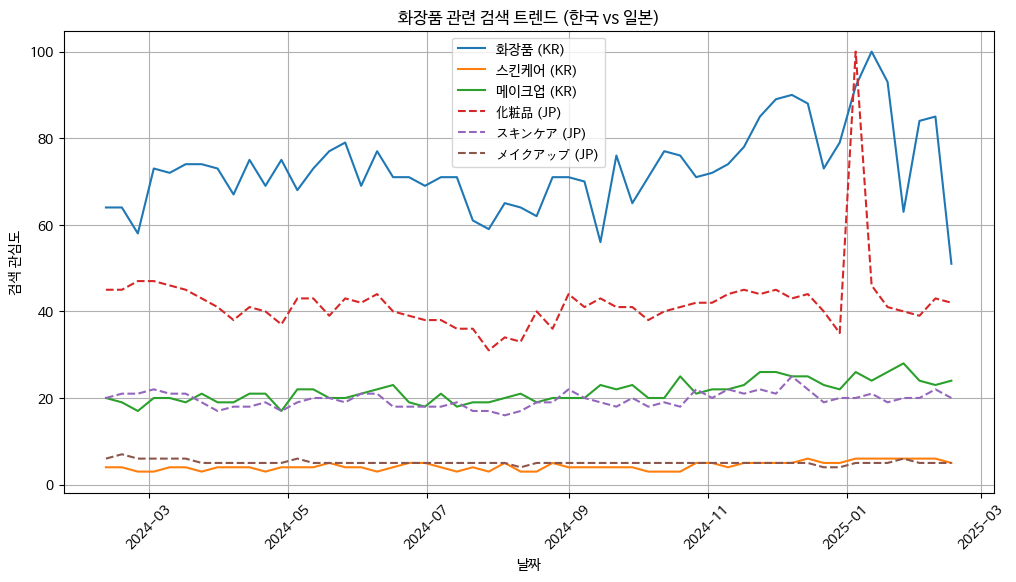

In [ ]:
# TrendReq 객체 생성
pytrends = TrendReq(hl='ko-KR', tz=540)  

# 분석할 키워드 목록
kw_kr_list = ["화장품", "스킨케어", "메이크업"]
kw_jp_list = ["化粧品", "スキンケア", "メイクアップ"]

# 한국(KR) 데이터 수집
pytrends.build_payload(kw_kr_list, cat=0, timeframe='today 12-m', geo='KR', gprop='')
kr_data = pytrends.interest_over_time()

# 일본(JP) 데이터 수집
pytrends.build_payload(kw_jp_list, cat=0, timeframe='today 12-m', geo='JP', gprop='')
jp_data = pytrends.interest_over_time()

# 데이터 시각화
plt.figure(figsize=(12, 6))
for kw in kw_kr_list:
    plt.plot(kr_data.index, kr_data[kw], label=f"{kw} (KR)", linestyle='solid')

for kw in kw_jp_list:
    plt.plot(jp_data.index, jp_data[kw], label=f"{kw} (JP)", linestyle='dashed')

plt.legend()
plt.title("화장품 관련 검색 트렌드 (한국 vs 일본)")
plt.xlabel("날짜")
plt.ylabel("검색 관심도")
plt.xticks(rotation=45)
plt.grid()
plt.show()

### 2) 한국 화장품 특정 키워드

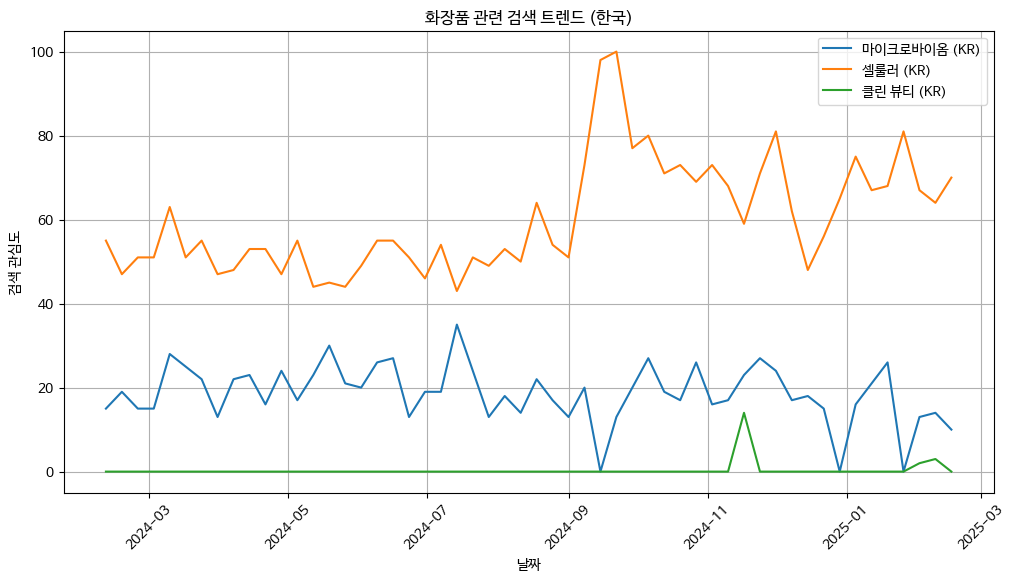

In [ ]:
# TrendReq 객체 생성
pytrends = TrendReq(hl='ko-KR', tz=540)  # 한국어 설정, 시간대는 일본/한국 공통 (UTC+9)

# 분석할 키워드 목록
kw_kr_list = ['마이크로바이옴', '셀룰러', '클린 뷰티']

# 한국(KR) 데이터 수집
pytrends.build_payload(kw_kr_list, cat=0, timeframe='today 12-m', geo='KR', gprop='')
kr_data = pytrends.interest_over_time()

# 데이터 시각화
plt.figure(figsize=(12, 6))
for kw in kw_kr_list:
    plt.plot(kr_data.index, kr_data[kw], label=f"{kw} (KR)", linestyle='solid')

plt.legend()
plt.title("화장품 관련 검색 트렌드 (한국)")
plt.xlabel("날짜")
plt.ylabel("검색 관심도")
plt.xticks(rotation=45)
plt.grid()
plt.show()

### 3) 한국 뷰티, 메이크업 구글 트렌드

In [ ]:
pytrends = TrendReq(hl="ko", tz=540)  # 한국어(ko) & 한국 시간대(UTC+9)

kw_list = ["뷰티", "메이크업"]  # 검색어 리스트

# 트렌드 데이터 요청 (5년간)
pytrends.build_payload(kw_list, cat=0, timeframe="today 5-y", geo="KR", gprop="")

# 데이터 가져오기
df = pytrends.interest_over_time()
print(df.head())  # 데이터 확인


            뷰티  메이크업  isPartial
date                           
2020-02-16  87    32      False
2020-02-23  74    24      False
2020-03-01  72    28      False
2020-03-08  82    28      False
2020-03-15  72    28      False


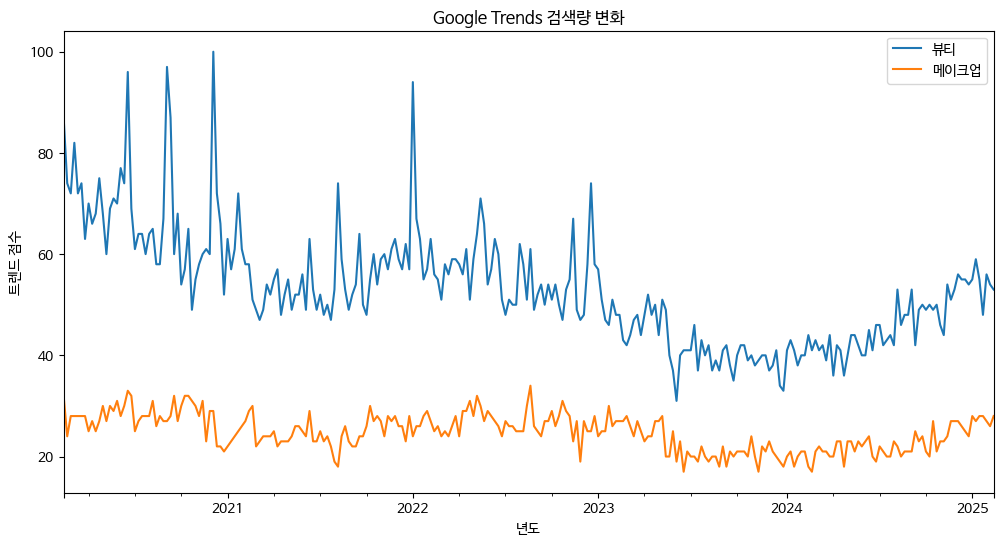

In [ ]:
df.drop(columns=["isPartial"], inplace=True) 
df.plot(figsize=(12,6), title="Google Trends 검색량 변화")
plt.xlabel("년도")
plt.ylabel("트렌드 점수")
plt.show()

## 2. 네이버 데이터랩 - 연령별 브랜드 검색량

In [ ]:
# 네이버 데이터랩에서 다운받은 데이터 불러오기

extra_age = pd.read_csv('기타_연령대.csv', encoding="utf-8-sig")
lip_age = pd.read_csv('립_연령대.csv', encoding="utf-8-sig")
clean_age = pd.read_csv('클렌징_연령대.csv', encoding="utf-8-sig")
mask_age = pd.read_csv('팩_연령대.csv', encoding="utf-8-sig")
skin_age = pd.read_csv('스킨_연령대.csv', encoding="utf-8-sig")
eye_age = pd.read_csv('아이_연령대.csv', encoding="utf-8-sig")
sun_age = pd.read_csv('선케어_연령대.csv', encoding="utf-8-sig")
base_age = pd.read_csv('베이스_연령대.csv', encoding="utf-8-sig")

In [ ]:
# 전체 데이터 통합을 위한 리스트 저장 함수
all_age = []
all_len = []

def all_age_list(age_df):
    all_age.append(age_df)
    all_len.append(f'{age_df.shape}')

    return all_age, all_len

### 1) 기타 브랜드 : extra_age_df

In [ ]:
# 원본 데이터 확인
extra_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      324 non-null    object 
 1   그라운드플랜  324 non-null    float64
 2   셀인샷     324 non-null    float64
 3   쏘내추럴    324 non-null    float64
 4   에스네이처   324 non-null    float64
 5   연령대     324 non-null    object 
dtypes: float64(4), object(2)
memory usage: 15.3+ KB


In [ ]:
# DF 구조 바꾸기
extra_melt = pd.melt(extra_age,id_vars=['날짜', '연령대'], value_vars=['그라운드플랜', '셀인샷', '에스네이처', '쏘내추럴'])

# DF 컬럼명 수정
extra_melt.rename(columns = {'variable':'브랜드', 'value':'관심도'}, inplace=True)

print(extra_melt.info())
extra_melt.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      1296 non-null   object 
 1   연령대     1296 non-null   object 
 2   브랜드     1296 non-null   object 
 3   관심도     1296 non-null   float64
dtypes: float64(1), object(3)
memory usage: 40.6+ KB
None


,날짜,연령대,브랜드,관심도
0,2024-02-05,10대,그라운드플랜,15.50387
1,2024-02-12,10대,그라운드플랜,8.52713
2,2024-02-19,10대,그라운드플랜,3.87596
3,2024-02-26,10대,그라운드플랜,12.40310
4,2024-03-04,10대,그라운드플랜,6.20155


In [ ]:
# 브랜드별 평균 관심도 확인 
extra_avg = extra_melt.groupby(['연령대', '브랜드'])['관심도'].mean()
extra_avg = extra_avg.reset_index()

print(extra_avg.info())
extra_avg.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연령대     24 non-null     object 
 1   브랜드     24 non-null     object 
 2   관심도     24 non-null     float64
dtypes: float64(1), object(2)
memory usage: 704.0+ bytes
None


,연령대,브랜드,관심도
0,10대,그라운드플랜,5.096178
1,10대,셀인샷,15.905824
2,10대,쏘내추럴,27.720352
3,10대,에스네이처,64.585123
4,20대,그라운드플랜,10.626208


In [ ]:
# avg df에 날짜 컬럼 삽입 및 순서 변경
# 날짜 = '총합' 추가 -> 연령별 각 브랜드의 관심도 평균 확인 가능
extra_avg['날짜'] = '총합'
extra_avg = extra_avg[['날짜', '연령대', '브랜드', '관심도']]

extra_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      24 non-null     object 
 1   연령대     24 non-null     object 
 2   브랜드     24 non-null     object 
 3   관심도     24 non-null     float64
dtypes: float64(1), object(3)
memory usage: 896.0+ bytes


In [ ]:
# melt & avg df 병합
extra_age_df = pd.concat([extra_avg, extra_melt])
extra_age_df.info()

# 분류 필터를 위한 분류 컬럼 생성
extra_age_df['대분류'] = '스킨케어'
extra_age_df['중분류1'] = '기타'

extra_age_df.head()

# 통합시 한번에 저장하기 위한 함수
all_age_list(extra_age_df)

<class 'pandas.core.frame.DataFrame'>
Index: 1320 entries, 0 to 1295
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      1320 non-null   object 
 1   연령대     1320 non-null   object 
 2   브랜드     1320 non-null   object 
 3   관심도     1320 non-null   float64
dtypes: float64(1), object(3)
memory usage: 51.6+ KB


([              날짜     연령대     브랜드        관심도   대분류 중분류1
  0             총합     10대  그라운드플랜   5.096178  스킨케어   기타
  1             총합     10대     셀인샷  15.905824  스킨케어   기타
  2             총합     10대    쏘내추럴  27.720352  스킨케어   기타
  3             총합     10대   에스네이처  64.585123  스킨케어   기타
  4             총합     20대  그라운드플랜  10.626208  스킨케어   기타
  ...          ...     ...     ...        ...   ...  ...
  1291  2025-01-13  60대 이상    쏘내추럴   6.106870  스킨케어   기타
  1292  2025-01-20  60대 이상    쏘내추럴  12.977090  스킨케어   기타
  1293  2025-01-27  60대 이상    쏘내추럴   7.633580  스킨케어   기타
  1294  2025-02-03  60대 이상    쏘내추럴   4.198470  스킨케어   기타
  1295  2025-02-10  60대 이상    쏘내추럴   8.396940  스킨케어   기타
  
  [1320 rows x 6 columns]],
 ['(1320, 6)'])

In [ ]:
# 원본 데이터 저장
# extra_age_df.to_csv('기타_연령별선호도.csv', index=False, encoding="utf-8-sig")

### 2) 클렌징 브랜드 : clean_age_df

In [ ]:
# 원본 데이터 확인
clean_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      324 non-null    object 
 1   메이크프렘   324 non-null    float64
 2   에스네이처   324 non-null    float64
 3   일리윤     324 non-null    float64
 4   일소      324 non-null    float64
 5   휩드      324 non-null    float64
 6   연령대     324 non-null    object 
dtypes: float64(5), object(2)
memory usage: 17.8+ KB


In [ ]:
# DF 구조 바꾸기
clean_melt = pd.melt(clean_age,id_vars=['날짜', '연령대'], value_vars=['메이크프렘', '에스네이처', '일리윤', '일소', '휩드'])

# DF 컬럼명 수정
clean_melt.rename(columns = {'variable':'브랜드', 'value':'관심도'}, inplace=True)

print(clean_melt.info())
clean_melt.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      1620 non-null   object 
 1   연령대     1620 non-null   object 
 2   브랜드     1620 non-null   object 
 3   관심도     1620 non-null   float64
dtypes: float64(1), object(3)
memory usage: 50.8+ KB
None


,날짜,연령대,브랜드,관심도
0,2024-02-05,10대,메이크프렘,9.4449
1,2024-02-12,10대,메이크프렘,14.7473
2,2024-02-19,10대,메이크프렘,14.5816
3,2024-02-26,10대,메이크프렘,14.2502
4,2024-03-04,10대,메이크프렘,9.2792


In [ ]:
# 브랜드별 평균 관심도 확인 
clean_avg = clean_melt.groupby(['연령대', '브랜드'])['관심도'].mean()
clean_avg = clean_avg.reset_index()

print(clean_avg.info())
clean_avg.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연령대     30 non-null     object 
 1   브랜드     30 non-null     object 
 2   관심도     30 non-null     float64
dtypes: float64(1), object(2)
memory usage: 848.0+ bytes
None


,연령대,브랜드,관심도
0,10대,메이크프렘,9.055198
1,10대,에스네이처,6.902632
2,10대,일리윤,9.467914
3,10대,일소,16.183369
4,10대,휩드,18.547664


In [ ]:
# avg df에 날짜 컬럼 삽입 및 순서 변경
# 날짜 = '총합' 추가 -> 연령별 각 브랜드의 관심도 평균 확인 가능
clean_avg['날짜'] = '총합'
clean_avg = clean_avg[['날짜', '연령대', '브랜드', '관심도']]

clean_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      30 non-null     object 
 1   연령대     30 non-null     object 
 2   브랜드     30 non-null     object 
 3   관심도     30 non-null     float64
dtypes: float64(1), object(3)
memory usage: 1.1+ KB


In [ ]:
# melt & avg df 병합
clean_age_df = pd.concat([clean_avg, clean_melt])
clean_age_df.info()

# 분류 필터를 위한 분류 컬럼 생성
clean_age_df['대분류'] = '스킨케어'
clean_age_df['중분류1'] = '클렌징'

clean_age_df.head()

# 통합시 한번에 저장하기 위한 함수
all_age_list(clean_age_df)

<class 'pandas.core.frame.DataFrame'>
Index: 1650 entries, 0 to 1619
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      1650 non-null   object 
 1   연령대     1650 non-null   object 
 2   브랜드     1650 non-null   object 
 3   관심도     1650 non-null   float64
dtypes: float64(1), object(3)
memory usage: 64.5+ KB


([              날짜     연령대     브랜드        관심도   대분류 중분류1
  0             총합     10대  그라운드플랜   5.096178  스킨케어   기타
  1             총합     10대     셀인샷  15.905824  스킨케어   기타
  2             총합     10대    쏘내추럴  27.720352  스킨케어   기타
  3             총합     10대   에스네이처  64.585123  스킨케어   기타
  4             총합     20대  그라운드플랜  10.626208  스킨케어   기타
  ...          ...     ...     ...        ...   ...  ...
  1291  2025-01-13  60대 이상    쏘내추럴   6.106870  스킨케어   기타
  1292  2025-01-20  60대 이상    쏘내추럴  12.977090  스킨케어   기타
  1293  2025-01-27  60대 이상    쏘내추럴   7.633580  스킨케어   기타
  1294  2025-02-03  60대 이상    쏘내추럴   4.198470  스킨케어   기타
  1295  2025-02-10  60대 이상    쏘내추럴   8.396940  스킨케어   기타
  
  [1320 rows x 6 columns],
               날짜     연령대   브랜드        관심도     대분류   중분류1
  0            총합     10대   글피오   0.788527  색조메이크업  립메이크업
  1            총합     10대  오드타입  40.535638  색조메이크업  립메이크업
  2            총합     10대   오브제   0.057744  색조메이크업  립메이크업
  3            총합     20대   글피오   1.797976  색조메이크업  립메

In [ ]:
# 원본 데이터 저장
# clean_age_df.to_csv('클렌징_연령별선호도.csv', index=False, encoding="utf-8-sig")

### 3) 마스크 브랜드 : mask_age_df

In [ ]:
# 원본 데이터 확인
mask_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      324 non-null    object 
 1   트리마이    324 non-null    float64
 2   연령대     324 non-null    object 
dtypes: float64(1), object(2)
memory usage: 7.7+ KB


In [ ]:
# DF 구조 바꾸기
mask_melt = pd.melt(mask_age,id_vars=['날짜', '연령대'], value_vars=['트리마이'])

# DF 컬럼명 수정
mask_melt.rename(columns = {'variable':'브랜드', 'value':'관심도'}, inplace=True)

print(mask_melt.info())
mask_melt.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      324 non-null    object 
 1   연령대     324 non-null    object 
 2   브랜드     324 non-null    object 
 3   관심도     324 non-null    float64
dtypes: float64(1), object(3)
memory usage: 10.2+ KB
None


,날짜,연령대,브랜드,관심도
0,2024-02-05,10대,트리마이,100.0
1,2024-02-12,10대,트리마이,0.0
2,2024-02-19,10대,트리마이,100.0
3,2024-02-26,10대,트리마이,0.0
4,2024-03-04,10대,트리마이,0.0


In [ ]:
# 브랜드별 평균 관심도 확인 
mask_avg = mask_melt.groupby(['연령대', '브랜드'])['관심도'].mean()
mask_avg = mask_avg.reset_index()

print(mask_avg.info())
mask_avg.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연령대     6 non-null      object 
 1   브랜드     6 non-null      object 
 2   관심도     6 non-null      float64
dtypes: float64(1), object(2)
memory usage: 272.0+ bytes
None


,연령대,브랜드,관심도
0,10대,트리마이,12.962963
1,20대,트리마이,28.985503
2,30대,트리마이,39.907407
3,40대,트리마이,32.098762
4,50대,트리마이,17.695472


In [ ]:
# avg df에 날짜 컬럼 삽입 및 순서 변경
# 날짜 = '총합' 추가 -> 연령별 각 브랜드의 관심도 평균 확인 가능
mask_avg['날짜'] = '총합'
mask_avg = mask_avg[['날짜', '연령대', '브랜드', '관심도']]

mask_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      6 non-null      object 
 1   연령대     6 non-null      object 
 2   브랜드     6 non-null      object 
 3   관심도     6 non-null      float64
dtypes: float64(1), object(3)
memory usage: 320.0+ bytes


In [ ]:
# melt & avg df 병합
mask_age_df = pd.concat([mask_avg, mask_melt])
mask_age_df.info()

# 분류 필터를 위한 분류 컬럼 생성
mask_age_df['대분류'] = '스킨케어'
mask_age_df['중분류1'] = '마스크팩'

mask_age_df.head()

# 통합시 한번에 저장하기 위한 함수
all_age_list(mask_age_df)

<class 'pandas.core.frame.DataFrame'>
Index: 330 entries, 0 to 323
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      330 non-null    object 
 1   연령대     330 non-null    object 
 2   브랜드     330 non-null    object 
 3   관심도     330 non-null    float64
dtypes: float64(1), object(3)
memory usage: 12.9+ KB


([              날짜     연령대     브랜드        관심도   대분류 중분류1
  0             총합     10대  그라운드플랜   5.096178  스킨케어   기타
  1             총합     10대     셀인샷  15.905824  스킨케어   기타
  2             총합     10대    쏘내추럴  27.720352  스킨케어   기타
  3             총합     10대   에스네이처  64.585123  스킨케어   기타
  4             총합     20대  그라운드플랜  10.626208  스킨케어   기타
  ...          ...     ...     ...        ...   ...  ...
  1291  2025-01-13  60대 이상    쏘내추럴   6.106870  스킨케어   기타
  1292  2025-01-20  60대 이상    쏘내추럴  12.977090  스킨케어   기타
  1293  2025-01-27  60대 이상    쏘내추럴   7.633580  스킨케어   기타
  1294  2025-02-03  60대 이상    쏘내추럴   4.198470  스킨케어   기타
  1295  2025-02-10  60대 이상    쏘내추럴   8.396940  스킨케어   기타
  
  [1320 rows x 6 columns],
               날짜     연령대   브랜드        관심도     대분류   중분류1
  0            총합     10대   글피오   0.788527  색조메이크업  립메이크업
  1            총합     10대  오드타입  40.535638  색조메이크업  립메이크업
  2            총합     10대   오브제   0.057744  색조메이크업  립메이크업
  3            총합     20대   글피오   1.797976  색조메이크업  립메

In [ ]:
# 원본 데이터 저장
# mask_age_df.to_csv('마스크팩_연령별선호도.csv', index=False, encoding="utf-8-sig")

### 4) 스킨케어 브랜드 : skin_age_df

In [ ]:
# 원본 데이터 확인
skin_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      324 non-null    object 
 1   에스네이처   324 non-null    float64
 2   일리윤     324 non-null    float64
 3   퓨리피아    324 non-null    float64
 4   연령대     324 non-null    object 
dtypes: float64(3), object(2)
memory usage: 12.8+ KB


In [ ]:
# DF 구조 바꾸기
skin_melt = pd.melt(skin_age,id_vars=['날짜', '연령대'], value_vars=['에스네이처', '일리윤', '퓨리피아'])

# DF 컬럼명 수정
skin_melt.rename(columns = {'variable':'브랜드', 'value':'관심도'}, inplace=True)

print(skin_melt.info())
skin_melt.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      972 non-null    object 
 1   연령대     972 non-null    object 
 2   브랜드     972 non-null    object 
 3   관심도     972 non-null    float64
dtypes: float64(1), object(3)
memory usage: 30.5+ KB
None


,날짜,연령대,브랜드,관심도
0,2024-02-05,10대,에스네이처,38.04878
1,2024-02-12,10대,에스네이처,54.63414
2,2024-02-19,10대,에스네이처,35.60975
3,2024-02-26,10대,에스네이처,62.92682
4,2024-03-04,10대,에스네이처,33.17073


In [ ]:
# 브랜드별 평균 관심도 확인 
skin_avg = skin_melt.groupby(['연령대', '브랜드'])['관심도'].mean()
skin_avg = skin_avg.reset_index()

print(skin_avg.info())
skin_avg.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연령대     18 non-null     object 
 1   브랜드     18 non-null     object 
 2   관심도     18 non-null     float64
dtypes: float64(1), object(2)
memory usage: 560.0+ bytes
None


,연령대,브랜드,관심도
0,10대,에스네이처,40.641368
1,10대,일리윤,55.745253
2,10대,퓨리피아,2.475152
3,20대,에스네이처,48.070129
4,20대,일리윤,64.755325


In [ ]:
# avg df에 날짜 컬럼 삽입 및 순서 변경
# 날짜 = '총합' 추가 -> 연령별 각 브랜드의 관심도 평균 확인 가능
skin_avg['날짜'] = '총합'
skin_avg = skin_avg[['날짜', '연령대', '브랜드', '관심도']]

skin_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      18 non-null     object 
 1   연령대     18 non-null     object 
 2   브랜드     18 non-null     object 
 3   관심도     18 non-null     float64
dtypes: float64(1), object(3)
memory usage: 704.0+ bytes


In [ ]:
# melt & avg df 병합
skin_age_df = pd.concat([skin_avg, skin_melt])
skin_age_df.info()

# 분류 필터를 위한 분류 컬럼 생성
skin_age_df['대분류'] = '스킨케어'
skin_age_df['중분류1'] = '스킨케어'

skin_age_df.head()

# 통합시 한번에 저장하기 위한 함수
all_age_list(skin_age_df)

<class 'pandas.core.frame.DataFrame'>
Index: 990 entries, 0 to 971
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      990 non-null    object 
 1   연령대     990 non-null    object 
 2   브랜드     990 non-null    object 
 3   관심도     990 non-null    float64
dtypes: float64(1), object(3)
memory usage: 38.7+ KB


([              날짜     연령대     브랜드        관심도   대분류 중분류1
  0             총합     10대  그라운드플랜   5.096178  스킨케어   기타
  1             총합     10대     셀인샷  15.905824  스킨케어   기타
  2             총합     10대    쏘내추럴  27.720352  스킨케어   기타
  3             총합     10대   에스네이처  64.585123  스킨케어   기타
  4             총합     20대  그라운드플랜  10.626208  스킨케어   기타
  ...          ...     ...     ...        ...   ...  ...
  1291  2025-01-13  60대 이상    쏘내추럴   6.106870  스킨케어   기타
  1292  2025-01-20  60대 이상    쏘내추럴  12.977090  스킨케어   기타
  1293  2025-01-27  60대 이상    쏘내추럴   7.633580  스킨케어   기타
  1294  2025-02-03  60대 이상    쏘내추럴   4.198470  스킨케어   기타
  1295  2025-02-10  60대 이상    쏘내추럴   8.396940  스킨케어   기타
  
  [1320 rows x 6 columns],
               날짜     연령대   브랜드        관심도     대분류   중분류1
  0            총합     10대   글피오   0.788527  색조메이크업  립메이크업
  1            총합     10대  오드타입  40.535638  색조메이크업  립메이크업
  2            총합     10대   오브제   0.057744  색조메이크업  립메이크업
  3            총합     20대   글피오   1.797976  색조메이크업  립메

In [ ]:
# 원본 데이터 저장
skin_age_df.to_csv('스킨_연령별선호도.csv', index=False, encoding="utf-8-sig")

### 5) 아이메이크업 브랜드 : eye_age_df

In [ ]:
# 원본 데이터 확인
eye_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      324 non-null    object 
 1   투크      324 non-null    float64
 2   연령대     324 non-null    object 
dtypes: float64(1), object(2)
memory usage: 7.7+ KB


In [ ]:
# DF 구조 바꾸기
eye_melt = pd.melt(eye_age,id_vars=['날짜', '연령대'], value_vars=['투크'])

# DF 컬럼명 수정
eye_melt.rename(columns = {'variable':'브랜드', 'value':'관심도'}, inplace=True)

print(eye_melt.info())
eye_melt.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      324 non-null    object 
 1   연령대     324 non-null    object 
 2   브랜드     324 non-null    object 
 3   관심도     324 non-null    float64
dtypes: float64(1), object(3)
memory usage: 10.2+ KB
None


,날짜,연령대,브랜드,관심도
0,2024-02-05,10대,투크,56.76567
1,2024-02-12,10대,투크,65.01650
2,2024-02-19,10대,투크,57.64576
3,2024-02-26,10대,투크,59.95599
4,2024-03-04,10대,투크,47.19471


In [ ]:
# 브랜드별 평균 관심도 확인 
eye_avg = eye_melt.groupby(['연령대', '브랜드'])['관심도'].mean()
eye_avg = eye_avg.reset_index()

print(eye_avg.info())
eye_avg.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연령대     6 non-null      object 
 1   브랜드     6 non-null      object 
 2   관심도     6 non-null      float64
dtypes: float64(1), object(2)
memory usage: 272.0+ bytes
None


,연령대,브랜드,관심도
0,10대,투크,40.115303
1,20대,투크,48.536492
2,30대,투크,44.412710
3,40대,투크,39.351254
4,50대,투크,50.621689


In [ ]:
# avg df에 날짜 컬럼 삽입 및 순서 변경
# 날짜 = '총합' 추가 -> 연령별 각 브랜드의 관심도 평균 확인 가능
eye_avg['날짜'] = '총합'
eye_avg = eye_avg[['날짜', '연령대', '브랜드', '관심도']]

eye_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      6 non-null      object 
 1   연령대     6 non-null      object 
 2   브랜드     6 non-null      object 
 3   관심도     6 non-null      float64
dtypes: float64(1), object(3)
memory usage: 320.0+ bytes


In [ ]:
# melt & avg df 병합
eye_age_df = pd.concat([eye_avg, eye_melt])
eye_age_df.info()

# 분류 필터를 위한 분류 컬럼 생성
eye_age_df['대분류'] = '색조메이크업'
eye_age_df['중분류1'] = '아이메이크업'

eye_age_df.head()

# 통합시 한번에 저장하기 위한 함수
all_age_list(eye_age_df)

<class 'pandas.core.frame.DataFrame'>
Index: 330 entries, 0 to 323
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      330 non-null    object 
 1   연령대     330 non-null    object 
 2   브랜드     330 non-null    object 
 3   관심도     330 non-null    float64
dtypes: float64(1), object(3)
memory usage: 12.9+ KB


([              날짜     연령대     브랜드        관심도   대분류 중분류1
  0             총합     10대  그라운드플랜   5.096178  스킨케어   기타
  1             총합     10대     셀인샷  15.905824  스킨케어   기타
  2             총합     10대    쏘내추럴  27.720352  스킨케어   기타
  3             총합     10대   에스네이처  64.585123  스킨케어   기타
  4             총합     20대  그라운드플랜  10.626208  스킨케어   기타
  ...          ...     ...     ...        ...   ...  ...
  1291  2025-01-13  60대 이상    쏘내추럴   6.106870  스킨케어   기타
  1292  2025-01-20  60대 이상    쏘내추럴  12.977090  스킨케어   기타
  1293  2025-01-27  60대 이상    쏘내추럴   7.633580  스킨케어   기타
  1294  2025-02-03  60대 이상    쏘내추럴   4.198470  스킨케어   기타
  1295  2025-02-10  60대 이상    쏘내추럴   8.396940  스킨케어   기타
  
  [1320 rows x 6 columns],
               날짜     연령대   브랜드        관심도     대분류   중분류1
  0            총합     10대   글피오   0.788527  색조메이크업  립메이크업
  1            총합     10대  오드타입  40.535638  색조메이크업  립메이크업
  2            총합     10대   오브제   0.057744  색조메이크업  립메이크업
  3            총합     20대   글피오   1.797976  색조메이크업  립메

In [ ]:
# 원본 데이터 저장
# eye_age_df.to_csv('아이메이크업_연령별선호도.csv', index=False, encoding="utf-8-sig")

### 6) 립메이크업 브랜드 : lip_age_df

In [ ]:
# 원본 데이터 확인
lip_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      324 non-null    object 
 1   글피오     324 non-null    float64
 2   오드타입    324 non-null    float64
 3   오브제     324 non-null    float64
 4   연령대     324 non-null    object 
dtypes: float64(3), object(2)
memory usage: 12.8+ KB


In [ ]:
# DF 구조 바꾸기
lip_melt = pd.melt(lip_age,id_vars=['날짜', '연령대'], value_vars=['글피오', '오드타입', '오브제'])

# DF 컬럼명 수정
lip_melt.rename(columns = {'variable':'브랜드', 'value':'관심도'}, inplace=True)

print(lip_melt.info())
lip_melt.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      972 non-null    object 
 1   연령대     972 non-null    object 
 2   브랜드     972 non-null    object 
 3   관심도     972 non-null    float64
dtypes: float64(1), object(3)
memory usage: 30.5+ KB
None


,날짜,연령대,브랜드,관심도
0,2024-02-05,10대,글피오,0.0
1,2024-02-12,10대,글피오,0.0
2,2024-02-19,10대,글피오,0.0
3,2024-02-26,10대,글피오,0.0
4,2024-03-04,10대,글피오,0.0


In [ ]:
# 브랜드별 평균 관심도 확인 
lip_avg = lip_melt.groupby(['연령대', '브랜드'])['관심도'].mean()
lip_avg = lip_avg.reset_index()

print(lip_avg.info())
lip_avg.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연령대     18 non-null     object 
 1   브랜드     18 non-null     object 
 2   관심도     18 non-null     float64
dtypes: float64(1), object(2)
memory usage: 560.0+ bytes
None


,연령대,브랜드,관심도
0,10대,글피오,0.788527
1,10대,오드타입,40.535638
2,10대,오브제,0.057744
3,20대,글피오,1.797976
4,20대,오드타입,38.041953


In [ ]:
# avg df에 날짜 컬럼 삽입 및 순서 변경
# 날짜 = '총합' 추가 -> 연령별 각 브랜드의 관심도 평균 확인 가능
lip_avg['날짜'] = '총합'
lip_avg = lip_avg[['날짜', '연령대', '브랜드', '관심도']]

lip_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      18 non-null     object 
 1   연령대     18 non-null     object 
 2   브랜드     18 non-null     object 
 3   관심도     18 non-null     float64
dtypes: float64(1), object(3)
memory usage: 704.0+ bytes


In [ ]:
# melt & avg df 병합
lip_age_df = pd.concat([lip_avg, lip_melt])
lip_age_df.info()

# 분류 필터를 위한 분류 컬럼 생성
lip_age_df['대분류'] = '색조메이크업'
lip_age_df['중분류1'] = '립메이크업'

lip_age_df.head()

# 통합시 한번에 저장하기 위한 함수
all_age_list(lip_age_df)

<class 'pandas.core.frame.DataFrame'>
Index: 990 entries, 0 to 971
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      990 non-null    object 
 1   연령대     990 non-null    object 
 2   브랜드     990 non-null    object 
 3   관심도     990 non-null    float64
dtypes: float64(1), object(3)
memory usage: 38.7+ KB


([              날짜     연령대     브랜드        관심도   대분류 중분류1
  0             총합     10대  그라운드플랜   5.096178  스킨케어   기타
  1             총합     10대     셀인샷  15.905824  스킨케어   기타
  2             총합     10대    쏘내추럴  27.720352  스킨케어   기타
  3             총합     10대   에스네이처  64.585123  스킨케어   기타
  4             총합     20대  그라운드플랜  10.626208  스킨케어   기타
  ...          ...     ...     ...        ...   ...  ...
  1291  2025-01-13  60대 이상    쏘내추럴   6.106870  스킨케어   기타
  1292  2025-01-20  60대 이상    쏘내추럴  12.977090  스킨케어   기타
  1293  2025-01-27  60대 이상    쏘내추럴   7.633580  스킨케어   기타
  1294  2025-02-03  60대 이상    쏘내추럴   4.198470  스킨케어   기타
  1295  2025-02-10  60대 이상    쏘내추럴   8.396940  스킨케어   기타
  
  [1320 rows x 6 columns],
               날짜     연령대   브랜드        관심도     대분류   중분류1
  0            총합     10대   글피오   0.788527  색조메이크업  립메이크업
  1            총합     10대  오드타입  40.535638  색조메이크업  립메이크업
  2            총합     10대   오브제   0.057744  색조메이크업  립메이크업
  3            총합     20대   글피오   1.797976  색조메이크업  립메

In [ ]:
# 원본 데이터 저장
# lip_age_df.to_csv('립_연령별선호도.csv', index=False, encoding="utf-8-sig")

### 7) 선케어 브랜드 : sun_age_df

In [ ]:
# 원본 데이터 확인
sun_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      324 non-null    object 
 1   닥터아토    324 non-null    float64
 2   바론시에    324 non-null    float64
 3   셀퓨전씨    324 non-null    float64
 4   에스네이처   324 non-null    float64
 5   연령대     324 non-null    object 
dtypes: float64(4), object(2)
memory usage: 15.3+ KB


In [ ]:
# DF 구조 바꾸기
sun_melt = pd.melt(sun_age,id_vars=['날짜', '연령대'], value_vars=['닥터아토', '바론시에', '셀퓨전씨', '에스네이처'])

# DF 컬럼명 수정
sun_melt.rename(columns = {'variable':'브랜드', 'value':'관심도'}, inplace=True)

print(sun_melt.info())
sun_melt.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      1296 non-null   object 
 1   연령대     1296 non-null   object 
 2   브랜드     1296 non-null   object 
 3   관심도     1296 non-null   float64
dtypes: float64(1), object(3)
memory usage: 40.6+ KB
None


,날짜,연령대,브랜드,관심도
0,2024-02-05,10대,닥터아토,1.60919
1,2024-02-12,10대,닥터아토,1.83908
2,2024-02-19,10대,닥터아토,1.60919
3,2024-02-26,10대,닥터아토,1.60919
4,2024-03-04,10대,닥터아토,0.68965


In [ ]:
# 브랜드별 평균 관심도 확인 
sun_avg = sun_melt.groupby(['연령대', '브랜드'])['관심도'].mean()
sun_avg = sun_avg.reset_index()

print(sun_avg.info())
sun_avg.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연령대     24 non-null     object 
 1   브랜드     24 non-null     object 
 2   관심도     24 non-null     float64
dtypes: float64(1), object(2)
memory usage: 704.0+ bytes
None


,연령대,브랜드,관심도
0,10대,닥터아토,1.226051
1,10대,바론시에,0.183055
2,10대,셀퓨전씨,35.257552
3,10대,에스네이처,19.152825
4,20대,닥터아토,3.022704


In [ ]:
# avg df에 날짜 컬럼 삽입 및 순서 변경
# 날짜 = '총합' 추가 -> 연령별 각 브랜드의 관심도 평균 확인 가능
sun_avg['날짜'] = '총합'
sun_avg = sun_avg[['날짜', '연령대', '브랜드', '관심도']]

sun_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      24 non-null     object 
 1   연령대     24 non-null     object 
 2   브랜드     24 non-null     object 
 3   관심도     24 non-null     float64
dtypes: float64(1), object(3)
memory usage: 896.0+ bytes


In [ ]:
# melt & avg df 병합
sun_age_df = pd.concat([sun_avg, sun_melt])
sun_age_df.info()

# 분류 필터를 위한 분류 컬럼 생성
sun_age_df['대분류'] = '베이스메이크업'
sun_age_df['중분류1'] = '선케어'

sun_age_df.head()

# 통합시 한번에 저장하기 위한 함수
all_age_list(sun_age_df)

<class 'pandas.core.frame.DataFrame'>
Index: 1320 entries, 0 to 1295
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      1320 non-null   object 
 1   연령대     1320 non-null   object 
 2   브랜드     1320 non-null   object 
 3   관심도     1320 non-null   float64
dtypes: float64(1), object(3)
memory usage: 51.6+ KB


([              날짜     연령대     브랜드        관심도   대분류 중분류1
  0             총합     10대  그라운드플랜   5.096178  스킨케어   기타
  1             총합     10대     셀인샷  15.905824  스킨케어   기타
  2             총합     10대    쏘내추럴  27.720352  스킨케어   기타
  3             총합     10대   에스네이처  64.585123  스킨케어   기타
  4             총합     20대  그라운드플랜  10.626208  스킨케어   기타
  ...          ...     ...     ...        ...   ...  ...
  1291  2025-01-13  60대 이상    쏘내추럴   6.106870  스킨케어   기타
  1292  2025-01-20  60대 이상    쏘내추럴  12.977090  스킨케어   기타
  1293  2025-01-27  60대 이상    쏘내추럴   7.633580  스킨케어   기타
  1294  2025-02-03  60대 이상    쏘내추럴   4.198470  스킨케어   기타
  1295  2025-02-10  60대 이상    쏘내추럴   8.396940  스킨케어   기타
  
  [1320 rows x 6 columns],
               날짜     연령대   브랜드        관심도     대분류   중분류1
  0            총합     10대   글피오   0.788527  색조메이크업  립메이크업
  1            총합     10대  오드타입  40.535638  색조메이크업  립메이크업
  2            총합     10대   오브제   0.057744  색조메이크업  립메이크업
  3            총합     20대   글피오   1.797976  색조메이크업  립메

In [ ]:
# 원본 데이터 저장
# sun_age_df.to_csv('선케어_연령별선호도.csv', index=False, encoding="utf-8-sig")

### 8) 베이스메이크업 브랜드 : base_age_df

In [ ]:
# 원본 데이터 확인
base_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      324 non-null    object 
 1   셀퓨전씨    324 non-null    float64
 2   에스네이처   324 non-null    float64
 3   오브제     324 non-null    float64
 4   정샘물뷰티   324 non-null    float64
 5   지베르니    324 non-null    float64
 6   연령대     324 non-null    object 
dtypes: float64(5), object(2)
memory usage: 17.8+ KB


In [ ]:
# DF 구조 바꾸기
base_melt = pd.melt(base_age,id_vars=['날짜', '연령대'], value_vars=['셀퓨전씨', '오브제', '에스네이처', '정샘물뷰티', '지베르니'])

# DF 컬럼명 수정
base_melt.rename(columns = {'variable':'브랜드', 'value':'관심도'}, inplace=True)

print(base_melt.info())
base_melt.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      1620 non-null   object 
 1   연령대     1620 non-null   object 
 2   브랜드     1620 non-null   object 
 3   관심도     1620 non-null   float64
dtypes: float64(1), object(3)
memory usage: 50.8+ KB
None


,날짜,연령대,브랜드,관심도
0,2024-02-05,10대,셀퓨전씨,2.84644
1,2024-02-12,10대,셀퓨전씨,2.95131
2,2024-02-19,10대,셀퓨전씨,5.15355
3,2024-02-26,10대,셀퓨전씨,6.51685
4,2024-03-04,10대,셀퓨전씨,3.55056


In [ ]:
# 브랜드별 평균 관심도 확인 
base_avg = base_melt.groupby(['연령대', '브랜드'])['관심도'].mean()
base_avg = base_avg.reset_index()

print(base_avg.info())
base_avg.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연령대     30 non-null     object 
 1   브랜드     30 non-null     object 
 2   관심도     30 non-null     float64
dtypes: float64(1), object(2)
memory usage: 848.0+ bytes
None


,연령대,브랜드,관심도
0,10대,셀퓨전씨,2.297678
1,10대,에스네이처,1.248156
2,10대,오브제,0.008045
3,10대,정샘물뷰티,7.604378
4,10대,지베르니,8.549585


In [ ]:
# avg df에 날짜 컬럼 삽입 및 순서 변경
# 날짜 = '총합' 추가 -> 연령별 각 브랜드의 관심도 평균 확인 가능
base_avg['날짜'] = '총합'
base_avg = base_avg[['날짜', '연령대', '브랜드', '관심도']]

base_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      30 non-null     object 
 1   연령대     30 non-null     object 
 2   브랜드     30 non-null     object 
 3   관심도     30 non-null     float64
dtypes: float64(1), object(3)
memory usage: 1.1+ KB


In [ ]:
# melt & avg df 병합
base_age_df = pd.concat([base_avg, base_melt])
base_age_df.info()

# 분류 필터를 위한 분류 컬럼 생성
base_age_df['대분류'] = '베이스메이크업'
base_age_df['중분류1'] = '베이스메이크업'

base_age_df.head()

# 통합시 한번에 저장하기 위한 함수
all_age_list(base_age_df)

<class 'pandas.core.frame.DataFrame'>
Index: 1650 entries, 0 to 1619
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      1650 non-null   object 
 1   연령대     1650 non-null   object 
 2   브랜드     1650 non-null   object 
 3   관심도     1650 non-null   float64
dtypes: float64(1), object(3)
memory usage: 64.5+ KB


([              날짜     연령대     브랜드        관심도   대분류 중분류1
  0             총합     10대  그라운드플랜   5.096178  스킨케어   기타
  1             총합     10대     셀인샷  15.905824  스킨케어   기타
  2             총합     10대    쏘내추럴  27.720352  스킨케어   기타
  3             총합     10대   에스네이처  64.585123  스킨케어   기타
  4             총합     20대  그라운드플랜  10.626208  스킨케어   기타
  ...          ...     ...     ...        ...   ...  ...
  1291  2025-01-13  60대 이상    쏘내추럴   6.106870  스킨케어   기타
  1292  2025-01-20  60대 이상    쏘내추럴  12.977090  스킨케어   기타
  1293  2025-01-27  60대 이상    쏘내추럴   7.633580  스킨케어   기타
  1294  2025-02-03  60대 이상    쏘내추럴   4.198470  스킨케어   기타
  1295  2025-02-10  60대 이상    쏘내추럴   8.396940  스킨케어   기타
  
  [1320 rows x 6 columns],
               날짜     연령대   브랜드        관심도     대분류   중분류1
  0            총합     10대   글피오   0.788527  색조메이크업  립메이크업
  1            총합     10대  오드타입  40.535638  색조메이크업  립메이크업
  2            총합     10대   오브제   0.057744  색조메이크업  립메이크업
  3            총합     20대   글피오   1.797976  색조메이크업  립메

In [ ]:
# 원본 데이터 저장
# base_age_df.to_csv('베이스메이크업_연령별선호도.csv', index=False, encoding="utf-8-sig")

### 9) 연령별 검색량 데이터 통합 : all_age_df

In [ ]:
all_age_df = pd.concat(all_age, axis=0, ignore_index=True)

print(all_age_df)
all_age_df

              날짜     연령대     브랜드        관심도      대분류     중분류1
0             총합     10대  그라운드플랜   5.096178     스킨케어       기타
1             총합     10대     셀인샷  15.905824     스킨케어       기타
2             총합     10대    쏘내추럴  27.720352     스킨케어       기타
3             총합     10대   에스네이처  64.585123     스킨케어       기타
4             총합     20대  그라운드플랜  10.626208     스킨케어       기타
...          ...     ...     ...        ...      ...      ...
8575  2025-01-13  60대 이상    지베르니  21.500000  베이스메이크업  베이스메이크업
8576  2025-01-20  60대 이상    지베르니  17.000000  베이스메이크업  베이스메이크업
8577  2025-01-27  60대 이상    지베르니  19.750000  베이스메이크업  베이스메이크업
8578  2025-02-03  60대 이상    지베르니  37.000000  베이스메이크업  베이스메이크업
8579  2025-02-10  60대 이상    지베르니  21.250000  베이스메이크업  베이스메이크업

[8580 rows x 6 columns]


,날짜,연령대,브랜드,관심도,대분류,중분류1
0,총합,10대,그라운드플랜,5.096178,스킨케어,기타
1,총합,10대,셀인샷,15.905824,스킨케어,기타
2,총합,10대,쏘내추럴,27.720352,스킨케어,기타
3,총합,10대,에스네이처,64.585123,스킨케어,기타
4,총합,20대,그라운드플랜,10.626208,스킨케어,기타
...,...,...,...,...,...,...
8575,2025-01-13,60대 이상,지베르니,21.500000,베이스메이크업,베이스메이크업
8576,2025-01-20,60대 이상,지베르니,17.000000,베이스메이크업,베이스메이크업
8577,2025-01-27,60대 이상,지베르니,19.750000,베이스메이크업,베이스메이크업
8578,2025-02-03,60대 이상,지베르니,37.000000,베이스메이크업,베이스메이크업


In [ ]:
# 통합 더블체크 (1)
print(all_age_df['대분류'].nunique())
print(all_age_df['대분류'].unique())
print(all_age_df['중분류1'].nunique())
print(all_age_df['중분류1'].unique())

3
['스킨케어' '색조메이크업' '베이스메이크업']
8
['기타' '립메이크업' '클렌징' '마스크팩' '스킨케어' '아이메이크업' '선케어' '베이스메이크업']


In [ ]:
# 통합 더블체크 (2)
print(extra_age_df.shape)
print(lip_age_df.shape)
print(clean_age_df.shape)
print(mask_age_df.shape)
print(skin_age_df.shape)
print(eye_age_df.shape)
print(sun_age_df.shape)
print(base_age_df.shape)

all_len

(1320, 6)
(990, 6)
(1650, 6)
(330, 6)
(990, 6)
(330, 6)
(1320, 6)
(1650, 6)


['(1320, 6)',
 '(990, 6)',
 '(1650, 6)',
 '(330, 6)',
 '(990, 6)',
 '(330, 6)',
 '(1320, 6)',
 '(1650, 6)']

In [ ]:
# 통합 데이터 저장
# all_age_df.to_csv('통합_연령별선호도.csv', index=False, encoding="utf-8-sig")